# amir mohammad ostadkar  # 95

In [1]:
# project name : classification 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from warnings import filterwarnings
from sklearn.metrics import classification_report , confusion_matrix

In [3]:
filterwarnings('ignore')

In [4]:
#########################   111111111111111        import data    #########################

In [5]:
data = pd.read_csv('Bank_Personal_Loan_Modelling(1) (1).csv')
data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [6]:
df = pd.DataFrame(data)
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [8]:
df.describe(include='all')

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [9]:
# check nun
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [10]:
#########  <<<<<<<<<<<<<<<<<<<        scatter plot         >>>>>>>>>>>>>>>>>

In [11]:
for i in df.columns:     
    n = len(pd.unique(df[i]))
    print(i)
    print(n)
    print(df[i].unique())
    print('-----------------------------------------------------------------------------------------------------')
    

ID
5000
[   1    2    3 ... 4998 4999 5000]
-----------------------------------------------------------------------------------------------------
Age
45
[25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]
-----------------------------------------------------------------------------------------------------
Experience
47
[ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]
-----------------------------------------------------------------------------------------------------
Income
162
[ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15  74  30  38
   9  92  61  73  70 149  98 128  31  58  54

In [12]:
# data analysis 111111

In [13]:
#  numerical= age - Experience  --  Income  -- ZIP Code -- Family  -- CCAvg -- Mortgage

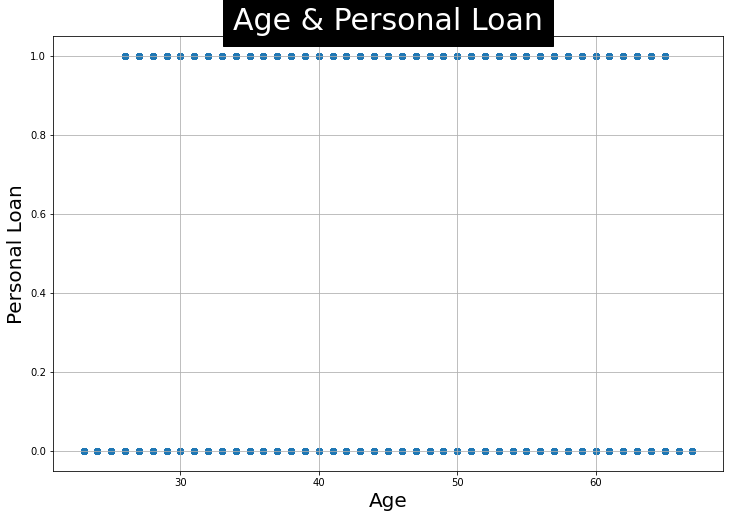

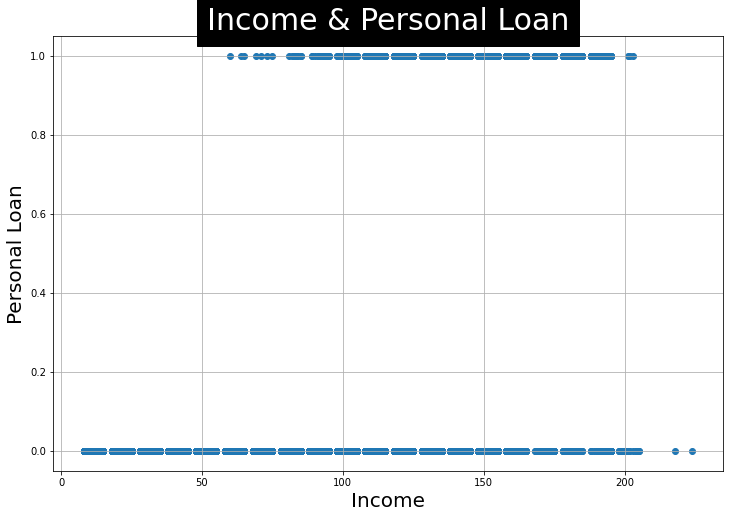

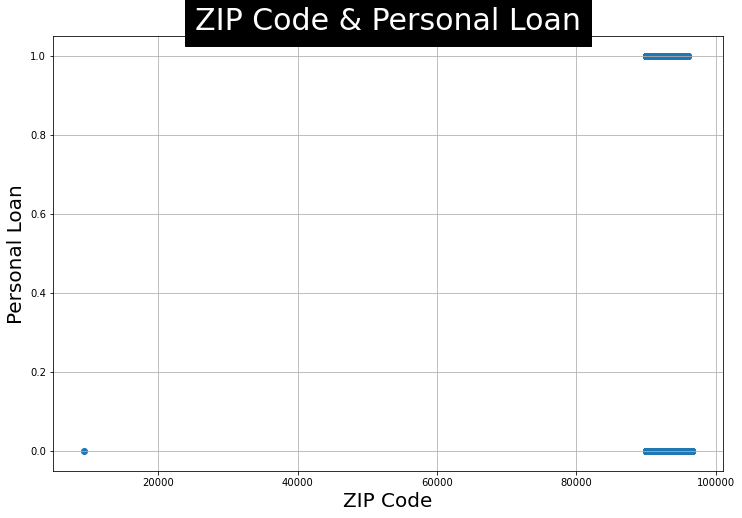

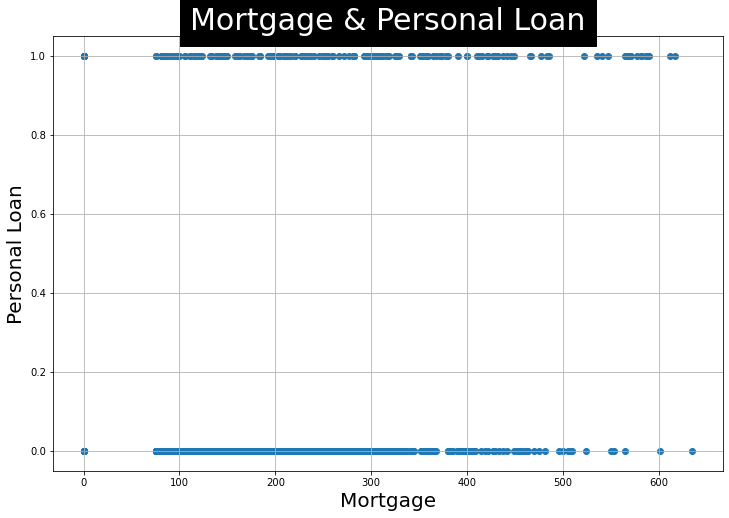

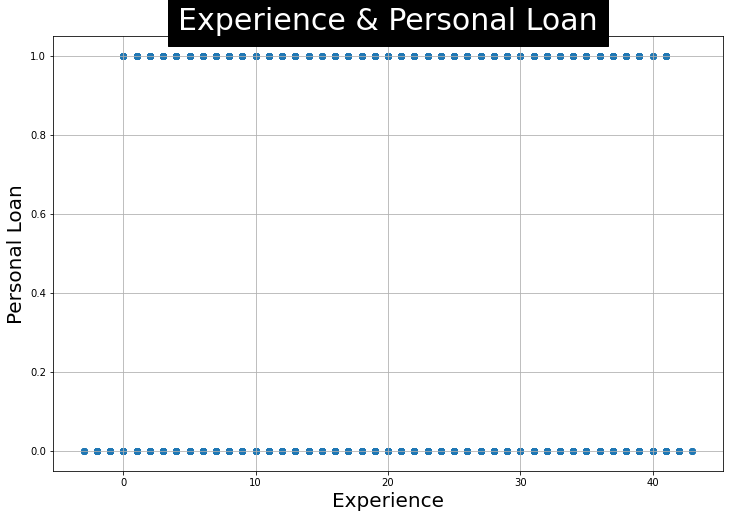

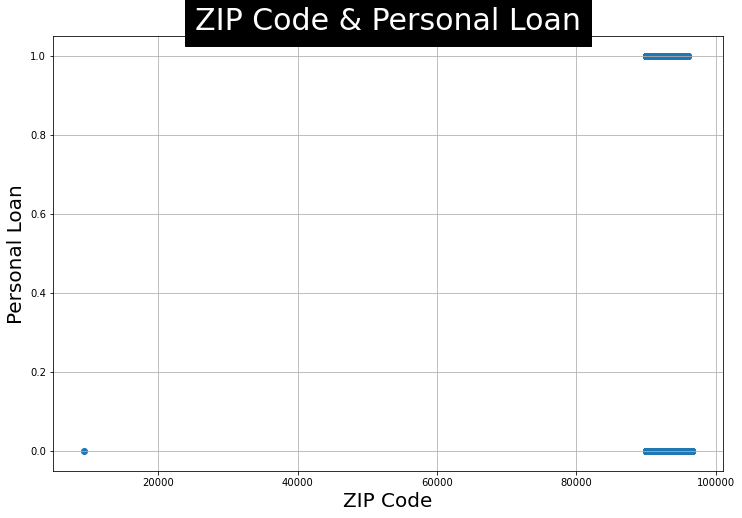

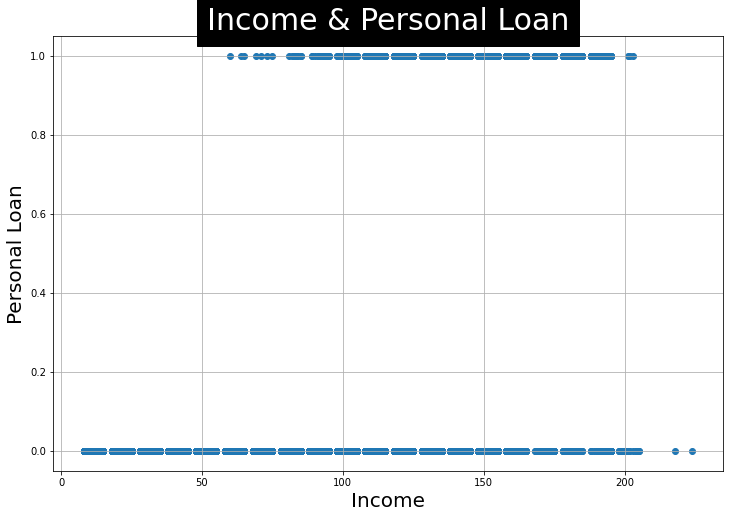

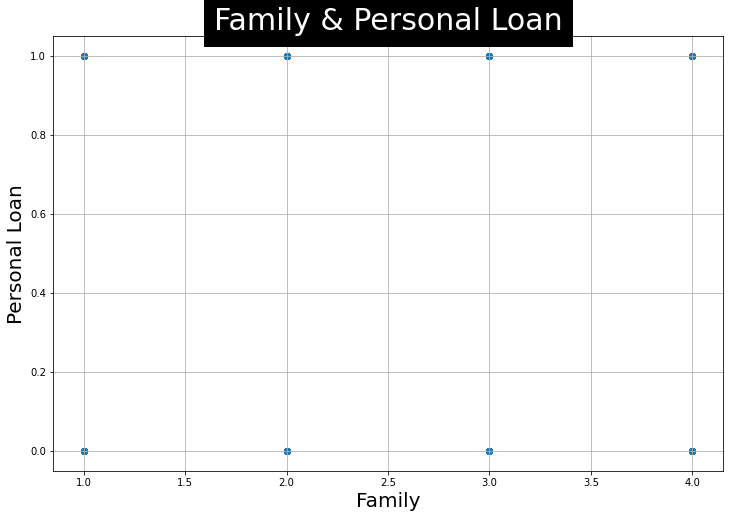

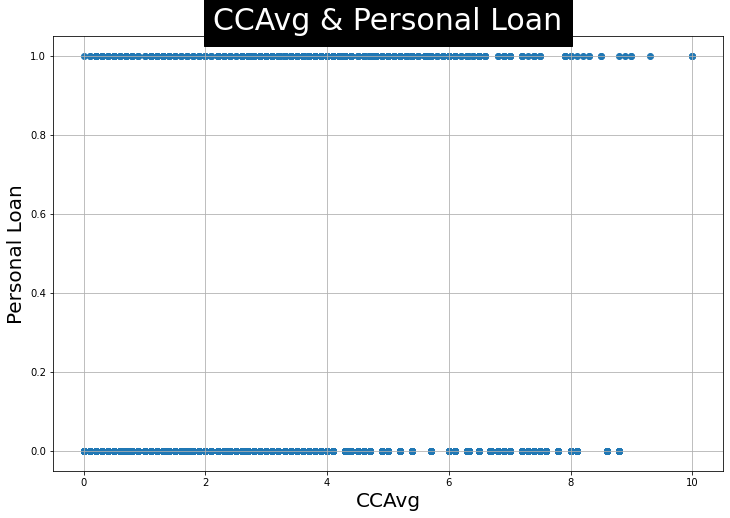

In [14]:
numerical=df[['Age','Income','ZIP Code','Mortgage','Experience','ZIP Code','Income','Family','CCAvg']]
for i in numerical.columns:
    plt.figure(figsize=(12,8))
    plt.scatter(df[i],df['Personal Loan'])
    plt.title(i+" & Personal Loan",backgroundcolor='black',color='white',fontsize=30)
    plt.xlabel(i,fontsize=20)
    plt.ylabel("Personal Loan",fontsize=20)
    #plt.savefig(i+ ' & Personal Loan.jpg' )
    plt.grid()
    plt.show()

In [15]:
#  note 1 =====    Experience>>>>>>     -1         -2  -3        >>>>>>>   is noise 
#  note 2 =====    #ZIP Code    >>>>>>>>>    9307   is must ne five deg  <>><><><><><><><><> 

In [16]:
#  categurical = CreditCard - Online - CD Account - Securities Account - Personal Loan - Education

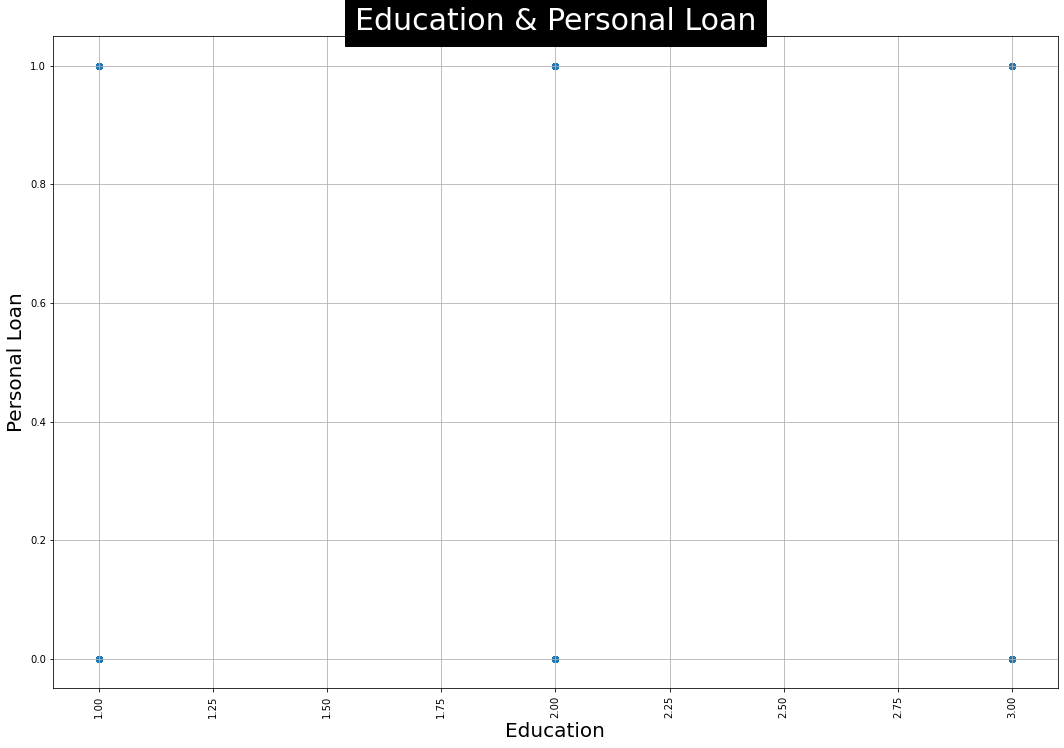

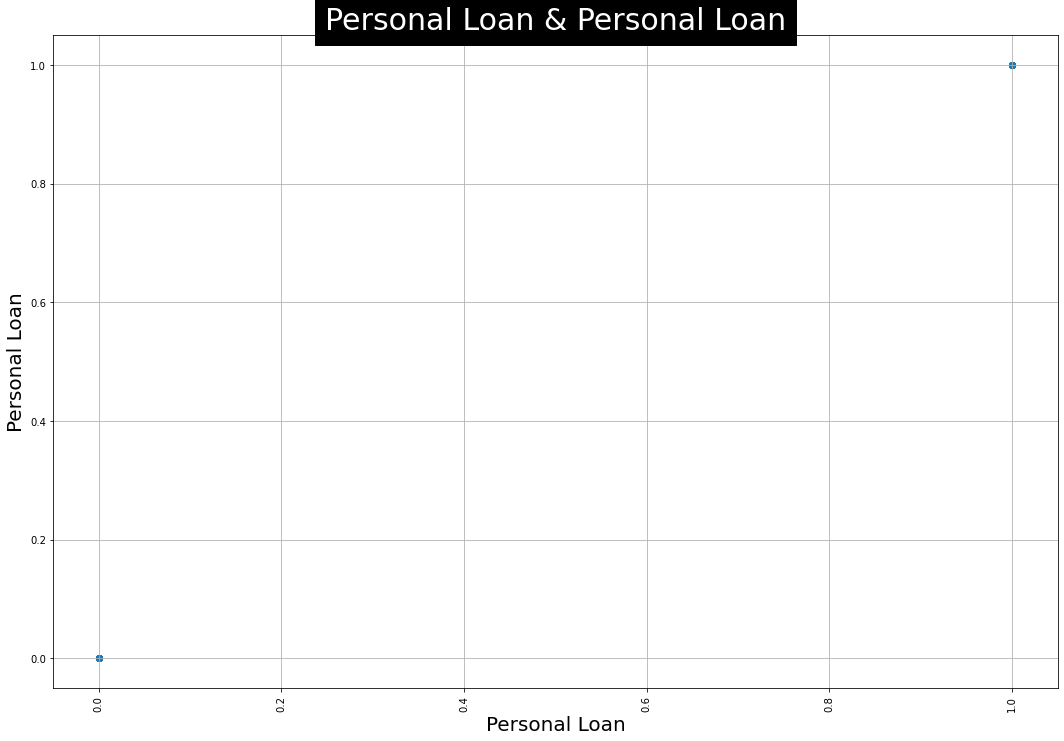

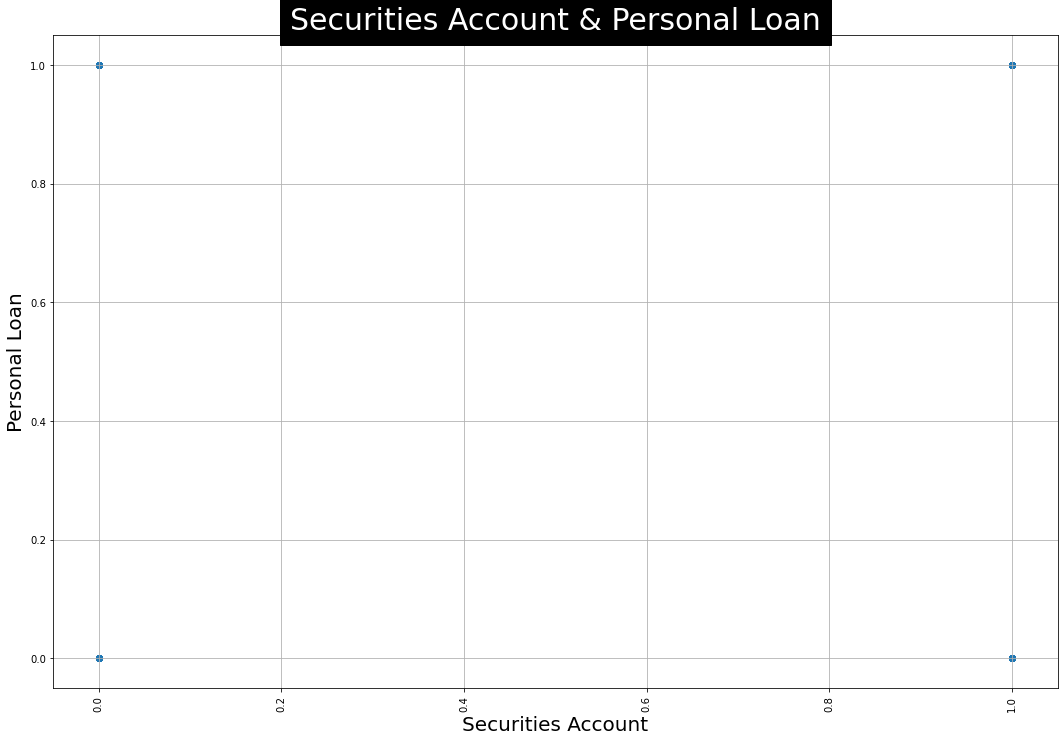

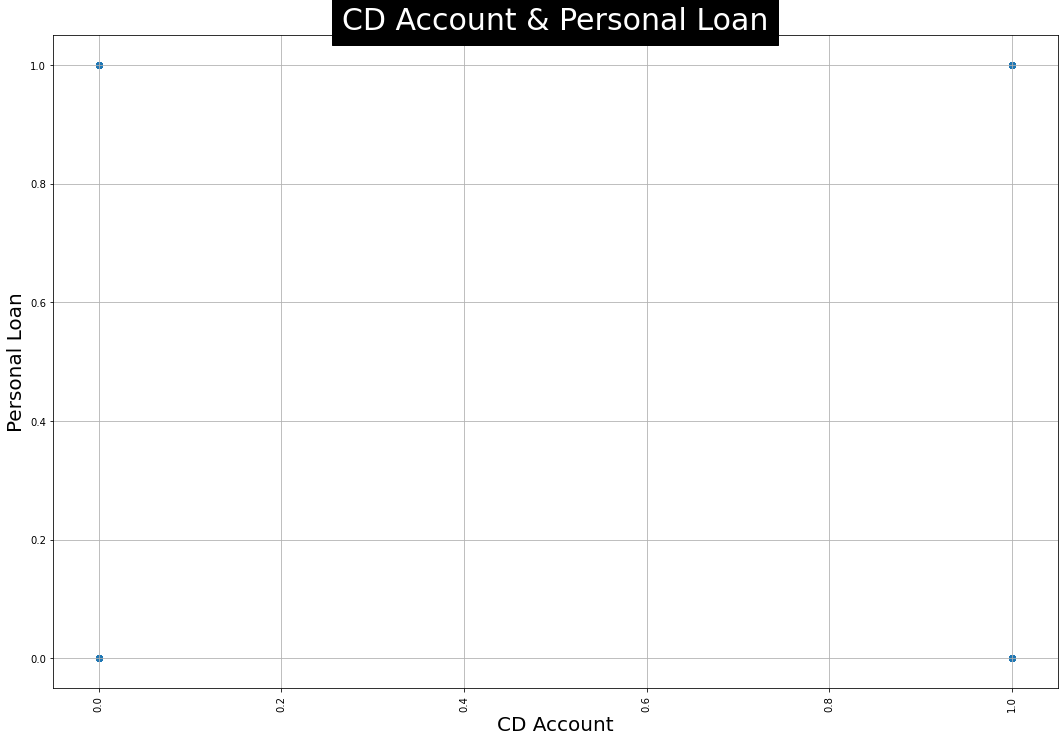

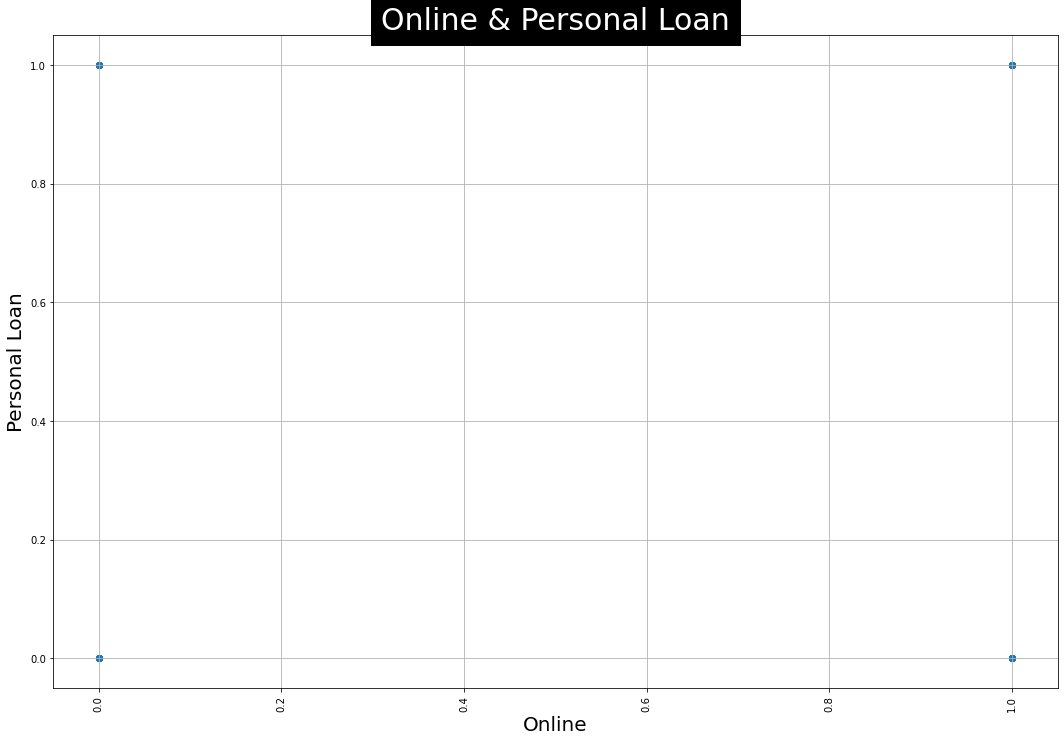

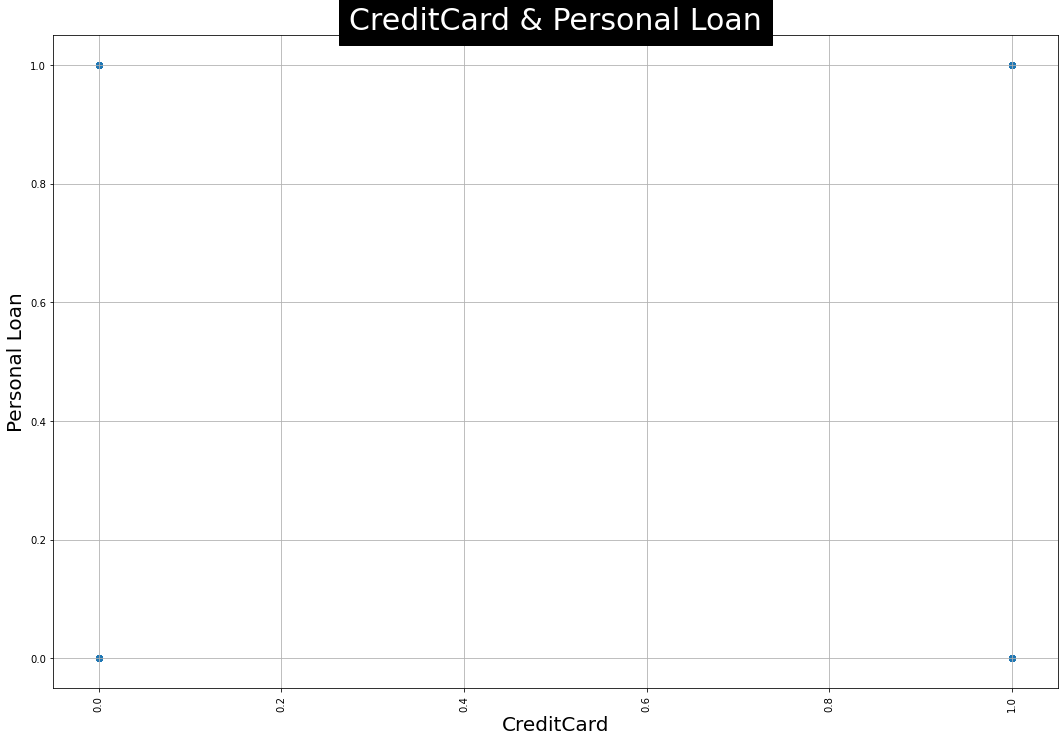

In [17]:
categurical=df[['Education','Personal Loan','Securities Account','CD Account','Online','CreditCard']]
for i in categurical.columns:
    plt.figure(figsize=(18,12))
    plt.scatter(df[i],df['Personal Loan'])
    plt.title(i+" & Personal Loan",backgroundcolor='black',color='white',fontsize=30)
    plt.xlabel(i,fontsize=20)
    plt.xticks(rotation=90)
    plt.ylabel("Personal Loan",fontsize=20)
    #plt.savefig(i+ ' & Personal Loan.jpg' )
    plt.grid()
    plt.show()

In [18]:
# id ========  drop  =  index

In [19]:
# <<<<<<<<<<<<<<<<<<<<<<   count plot   >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

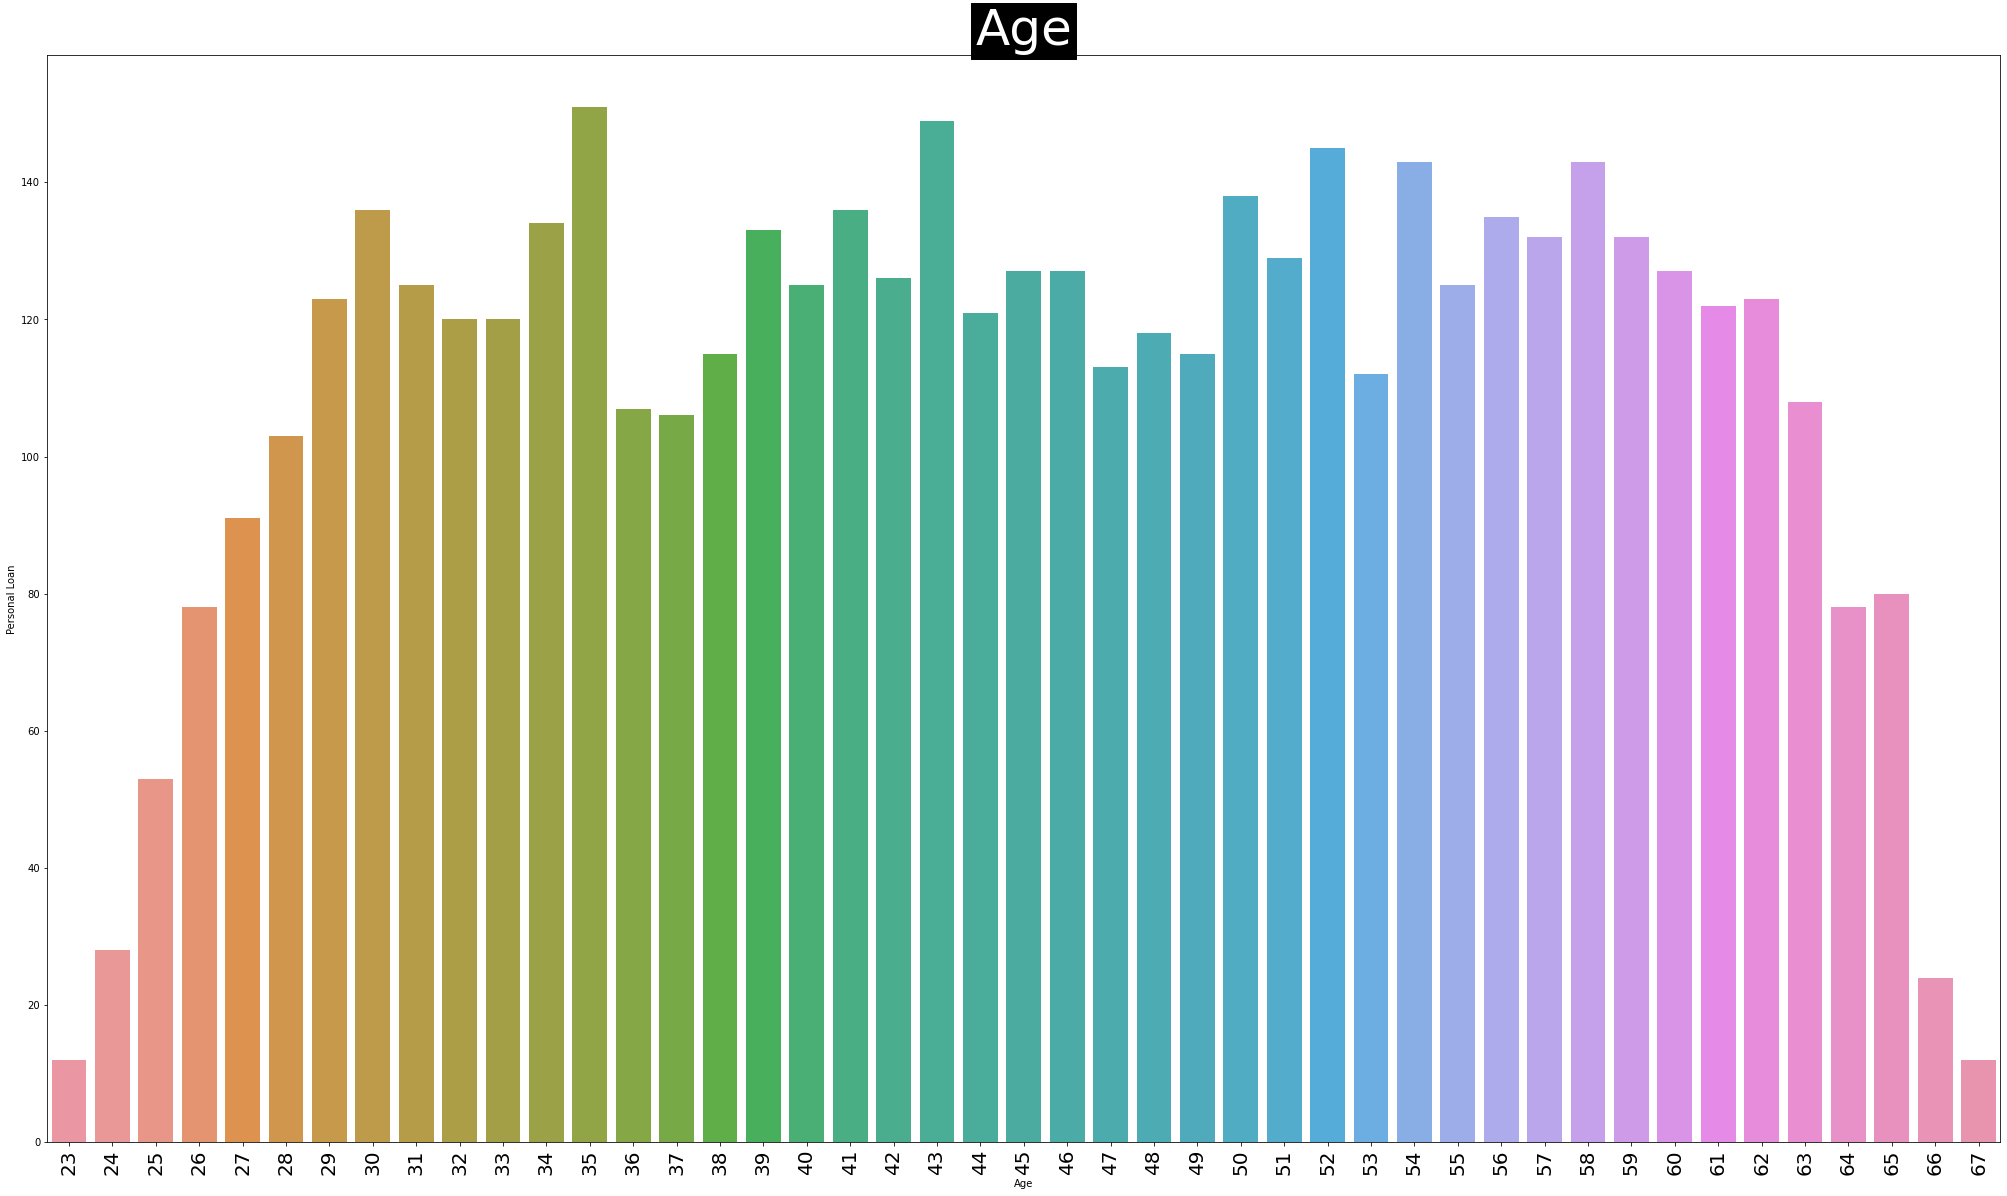

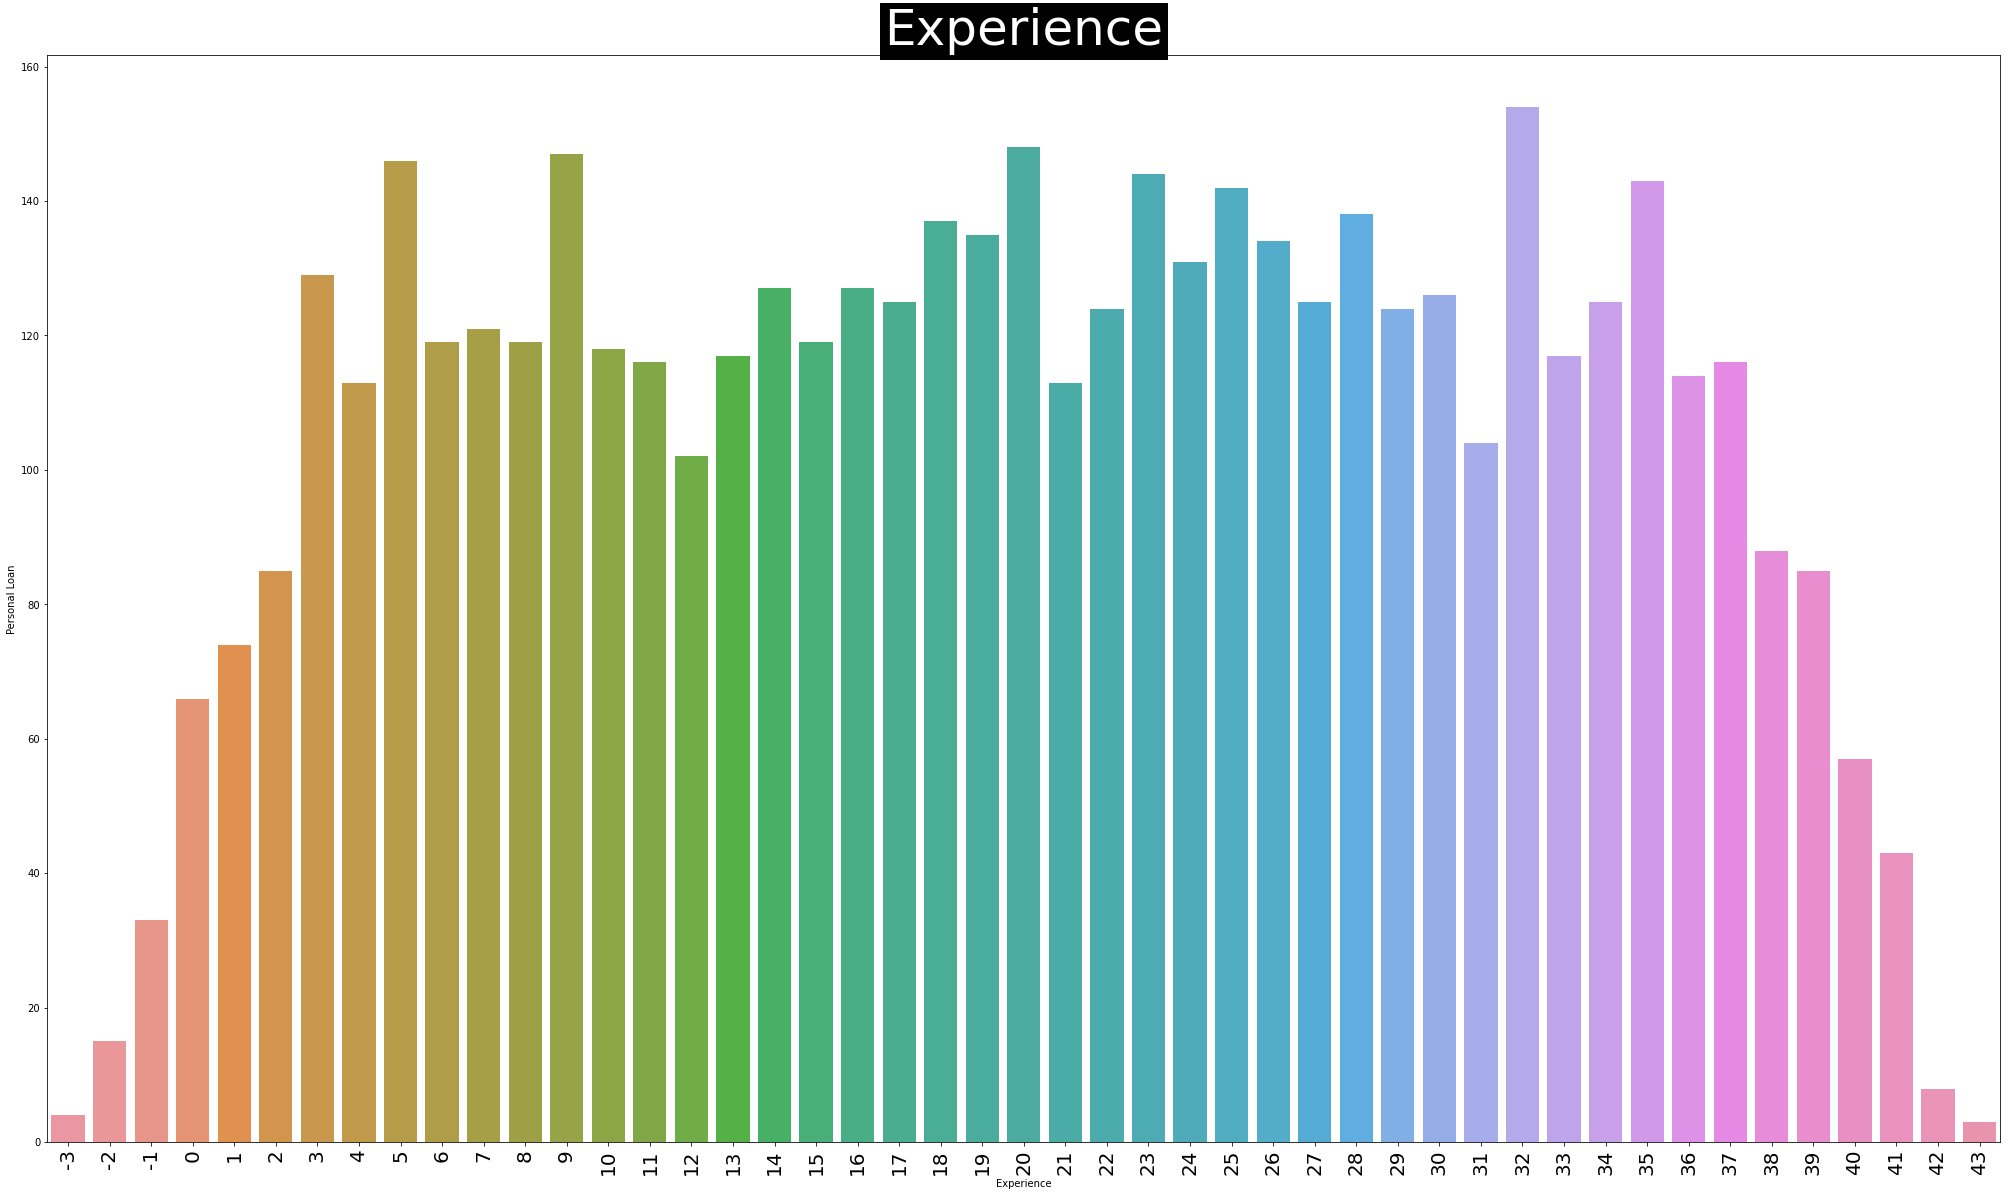

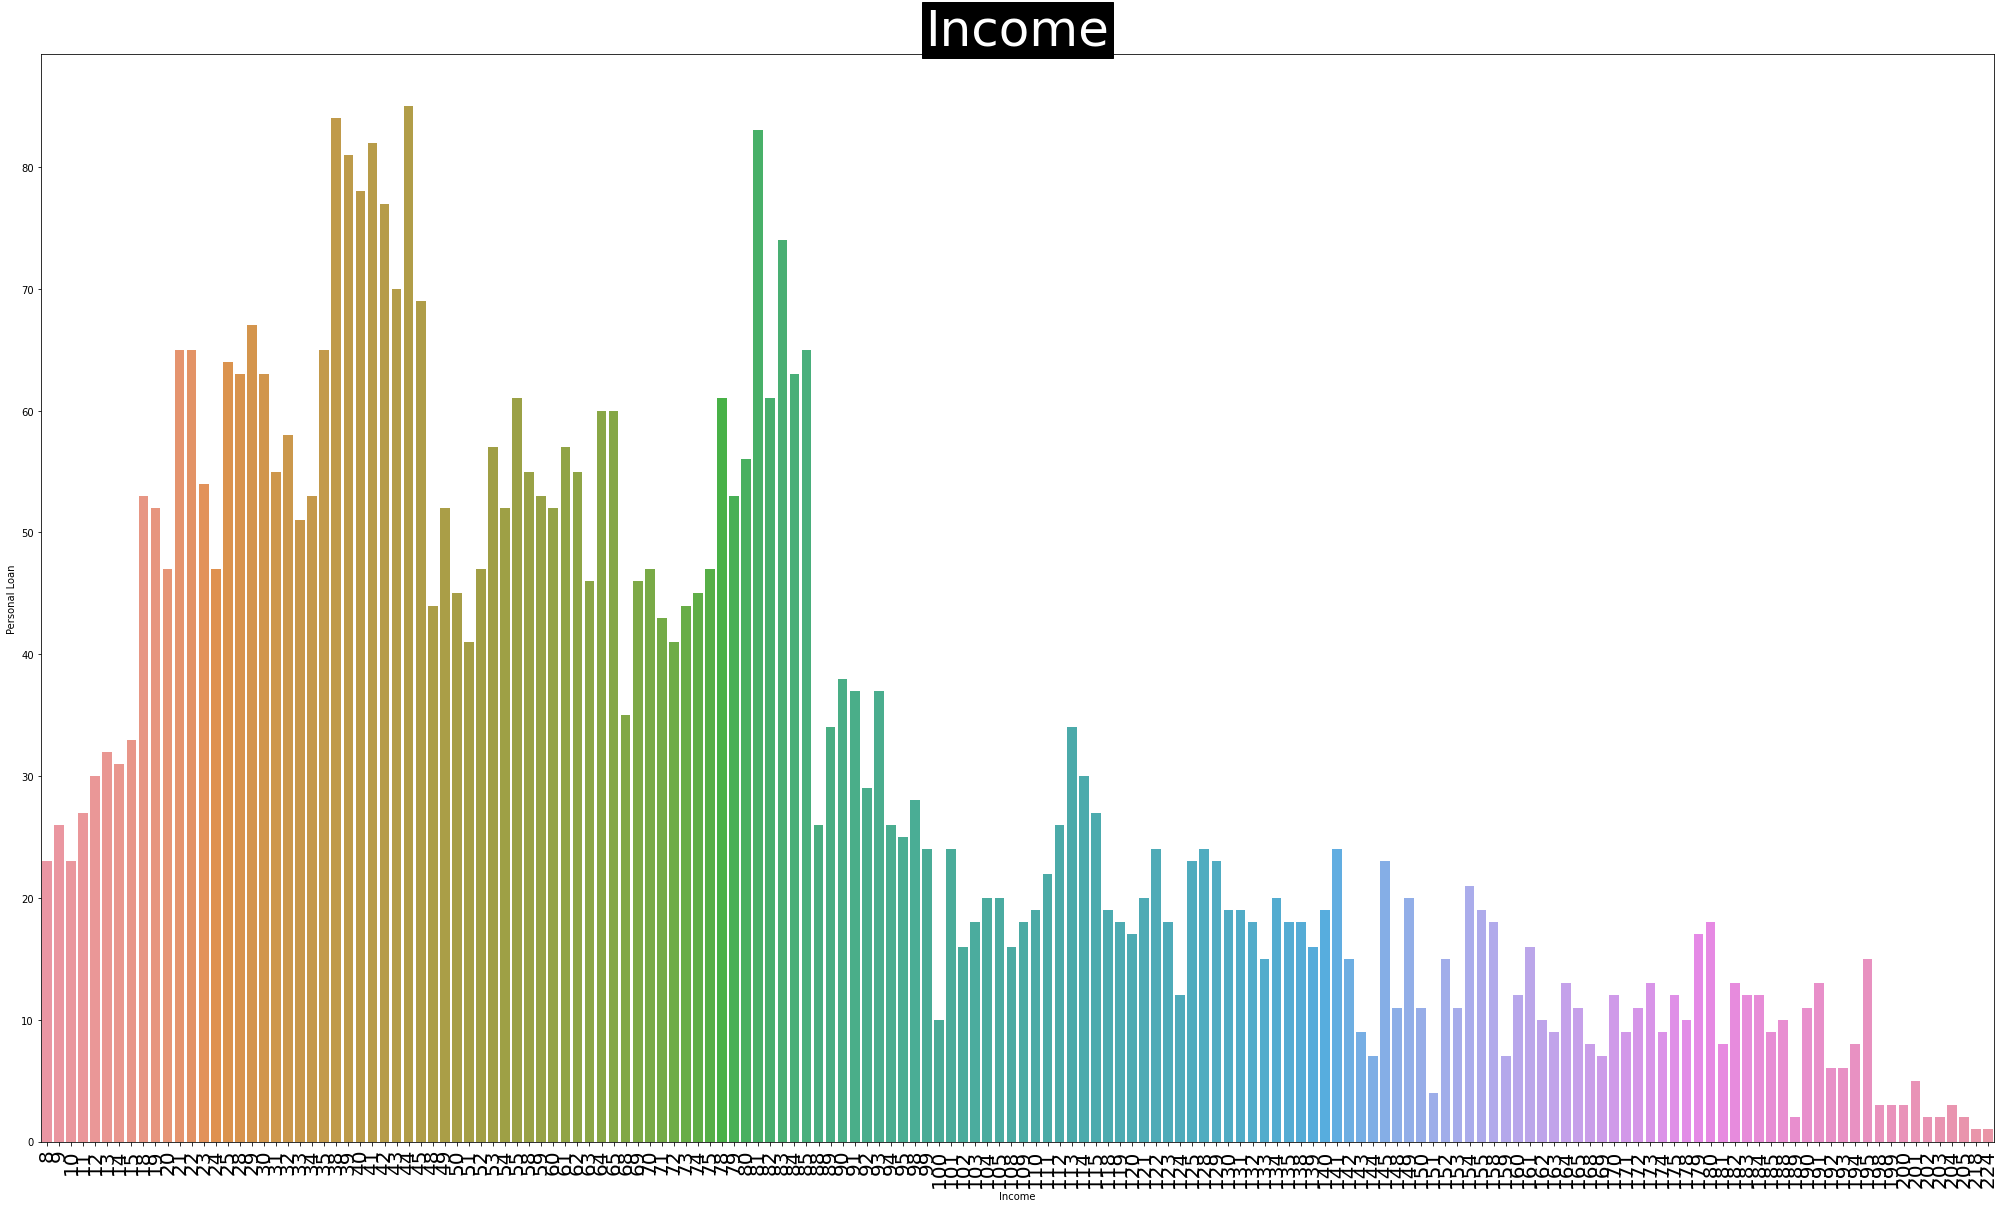

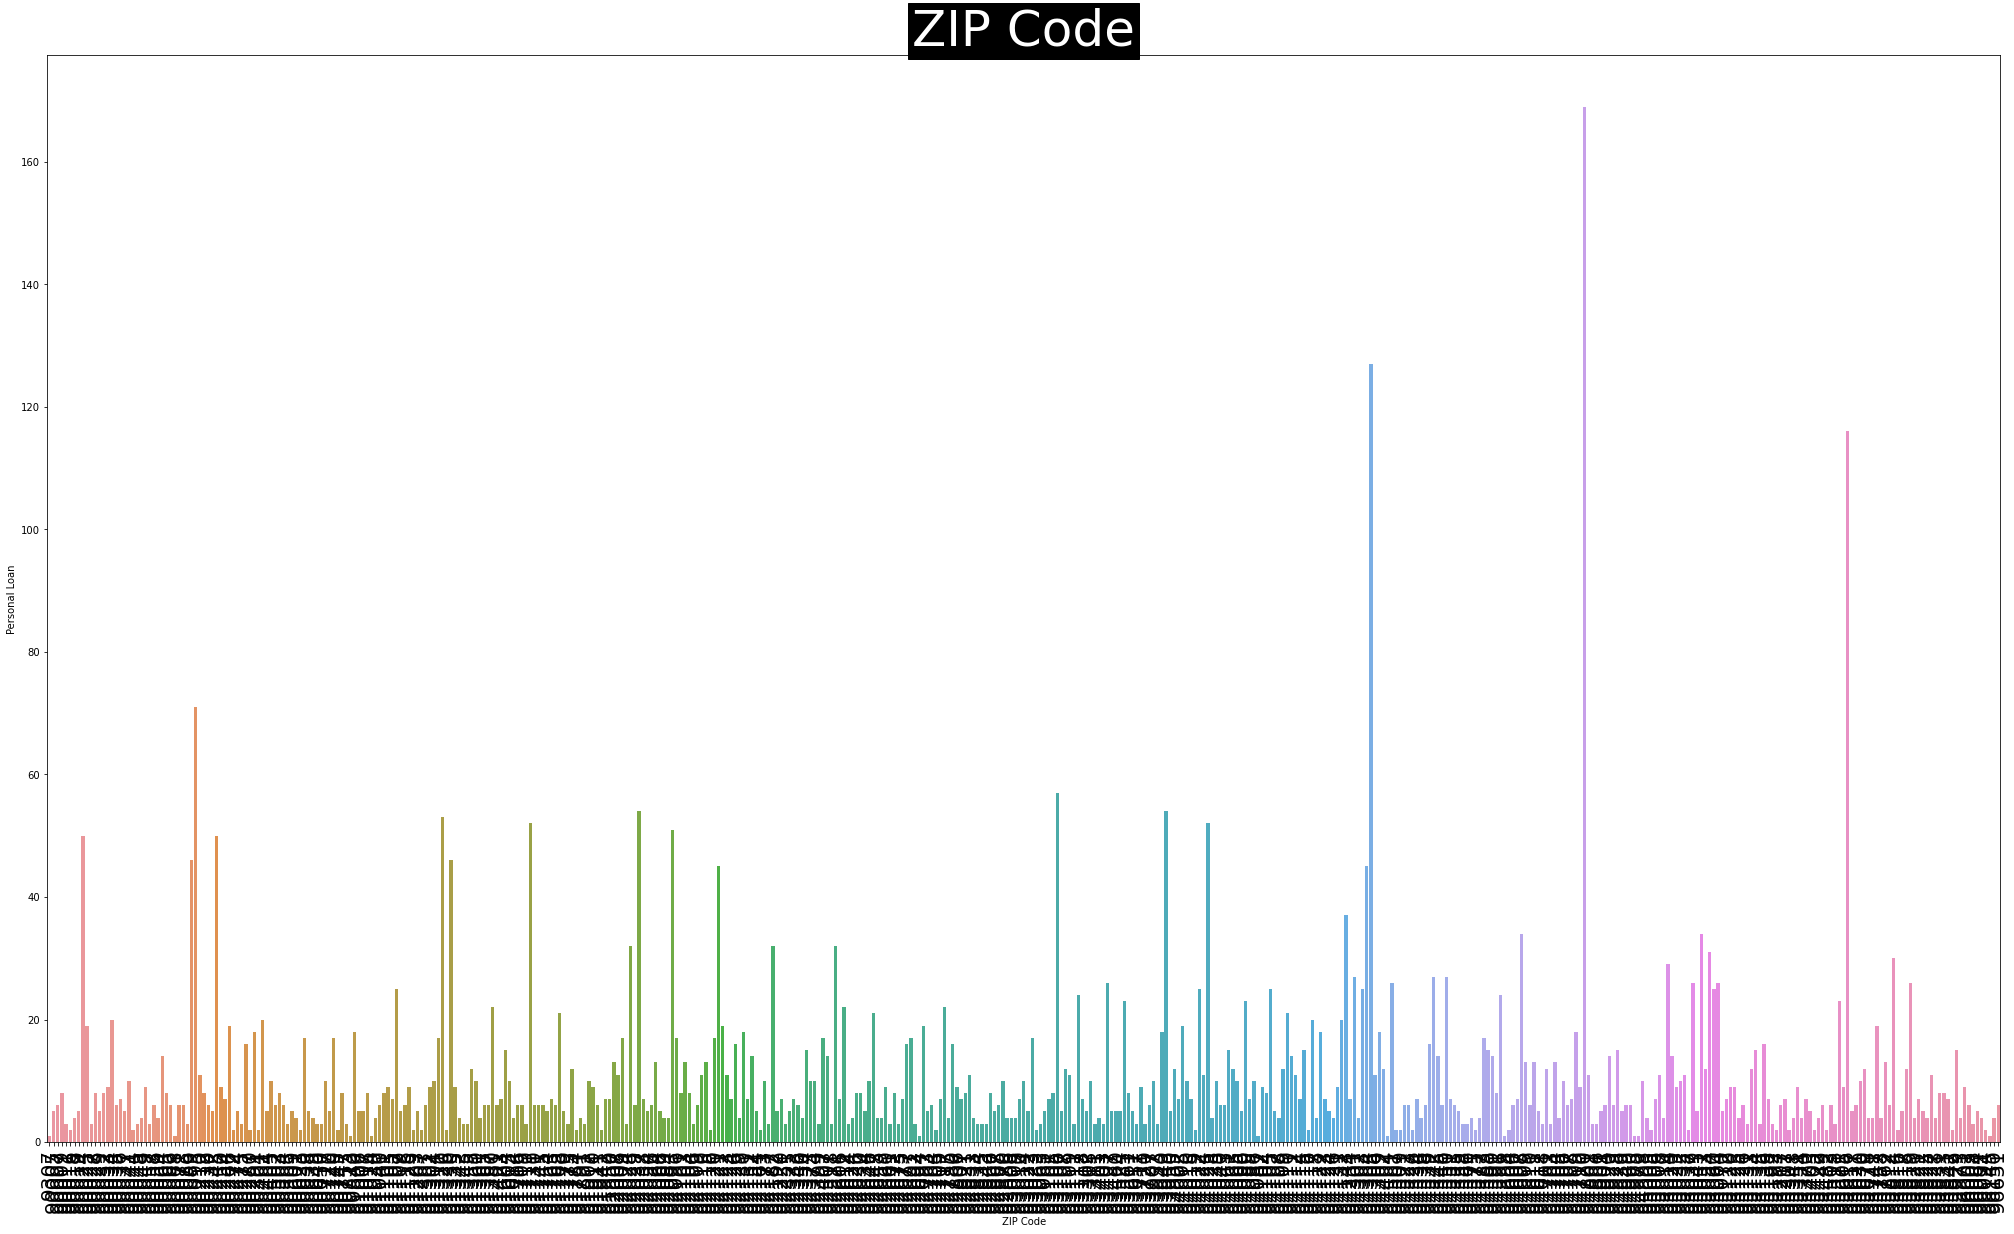

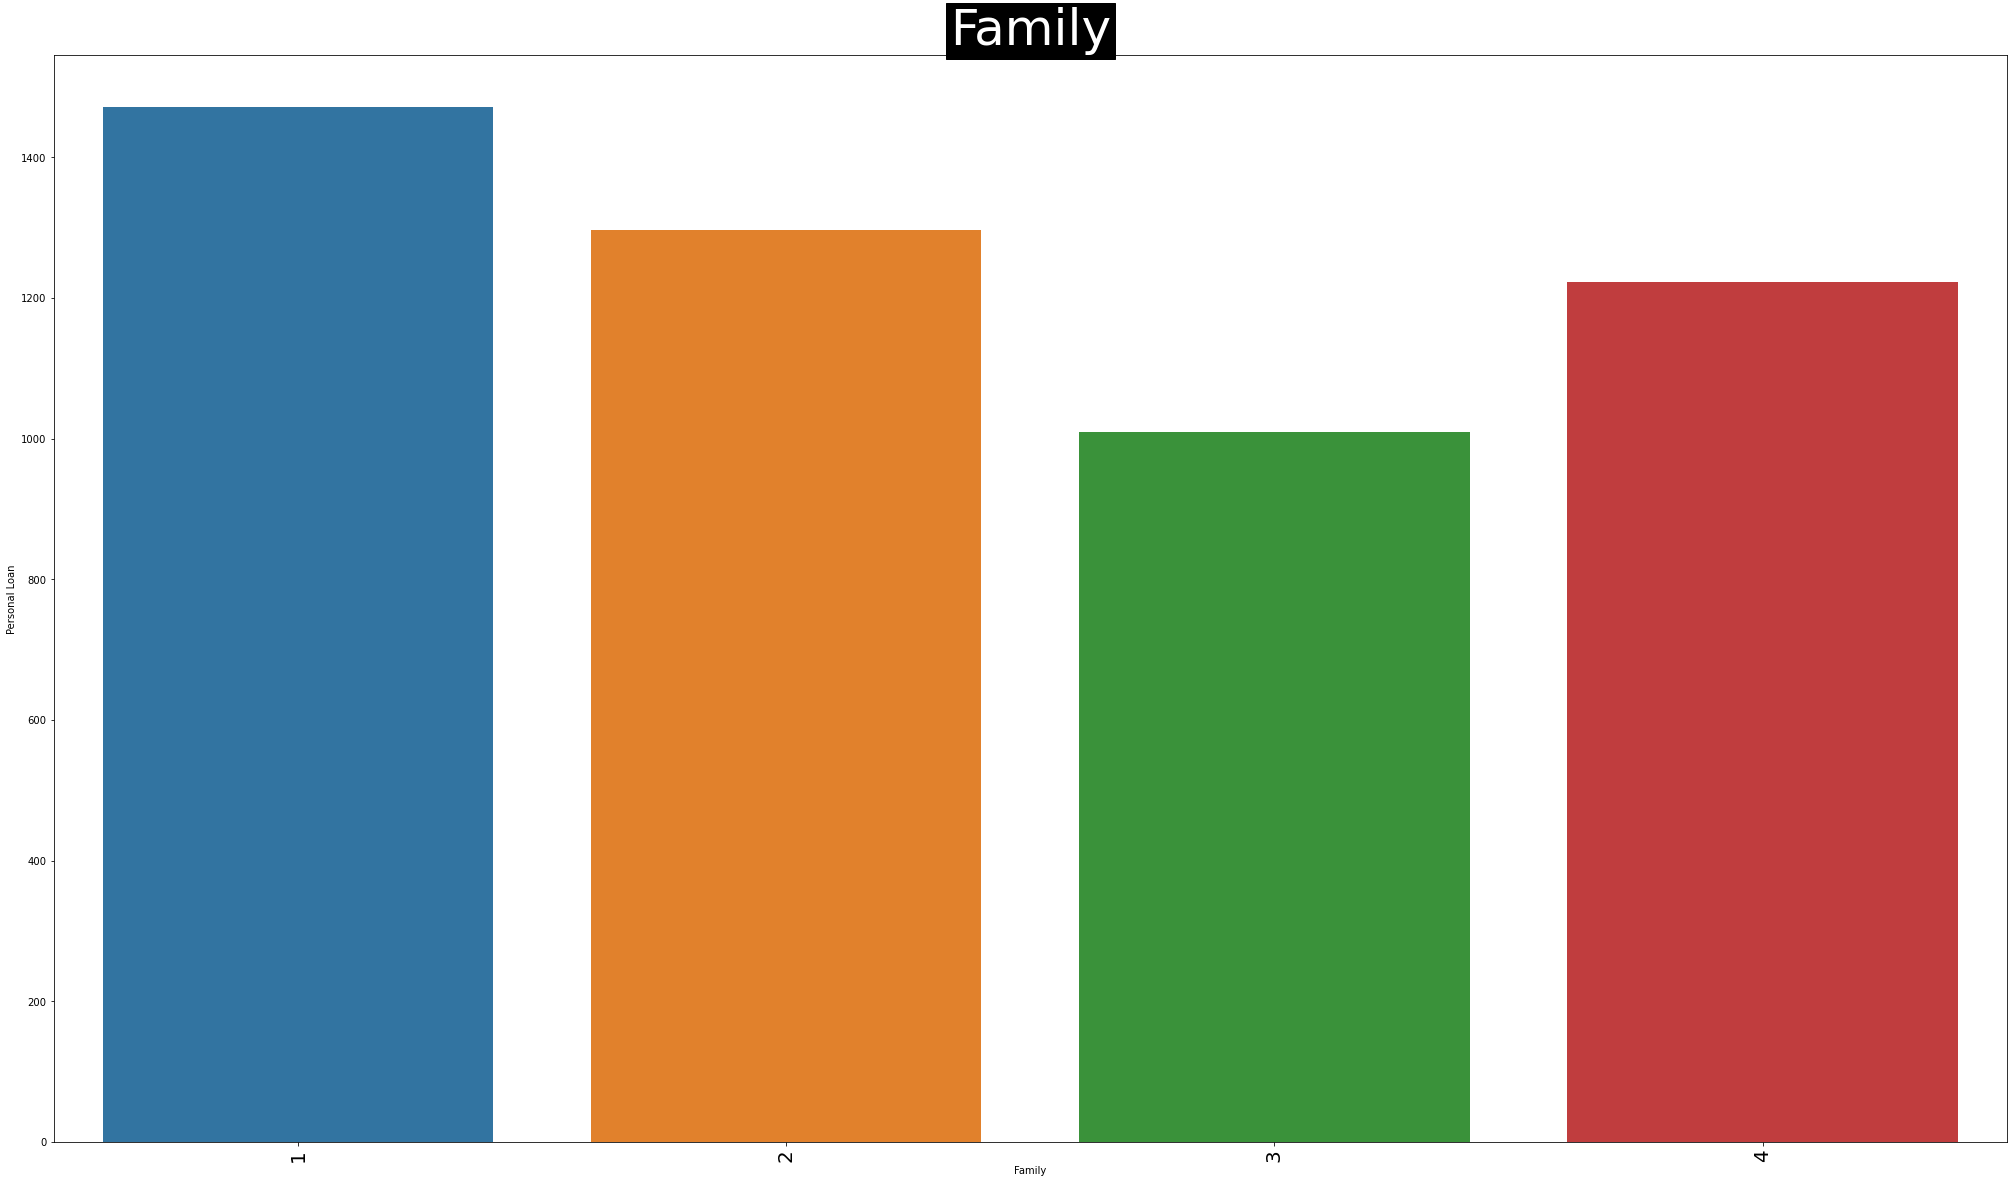

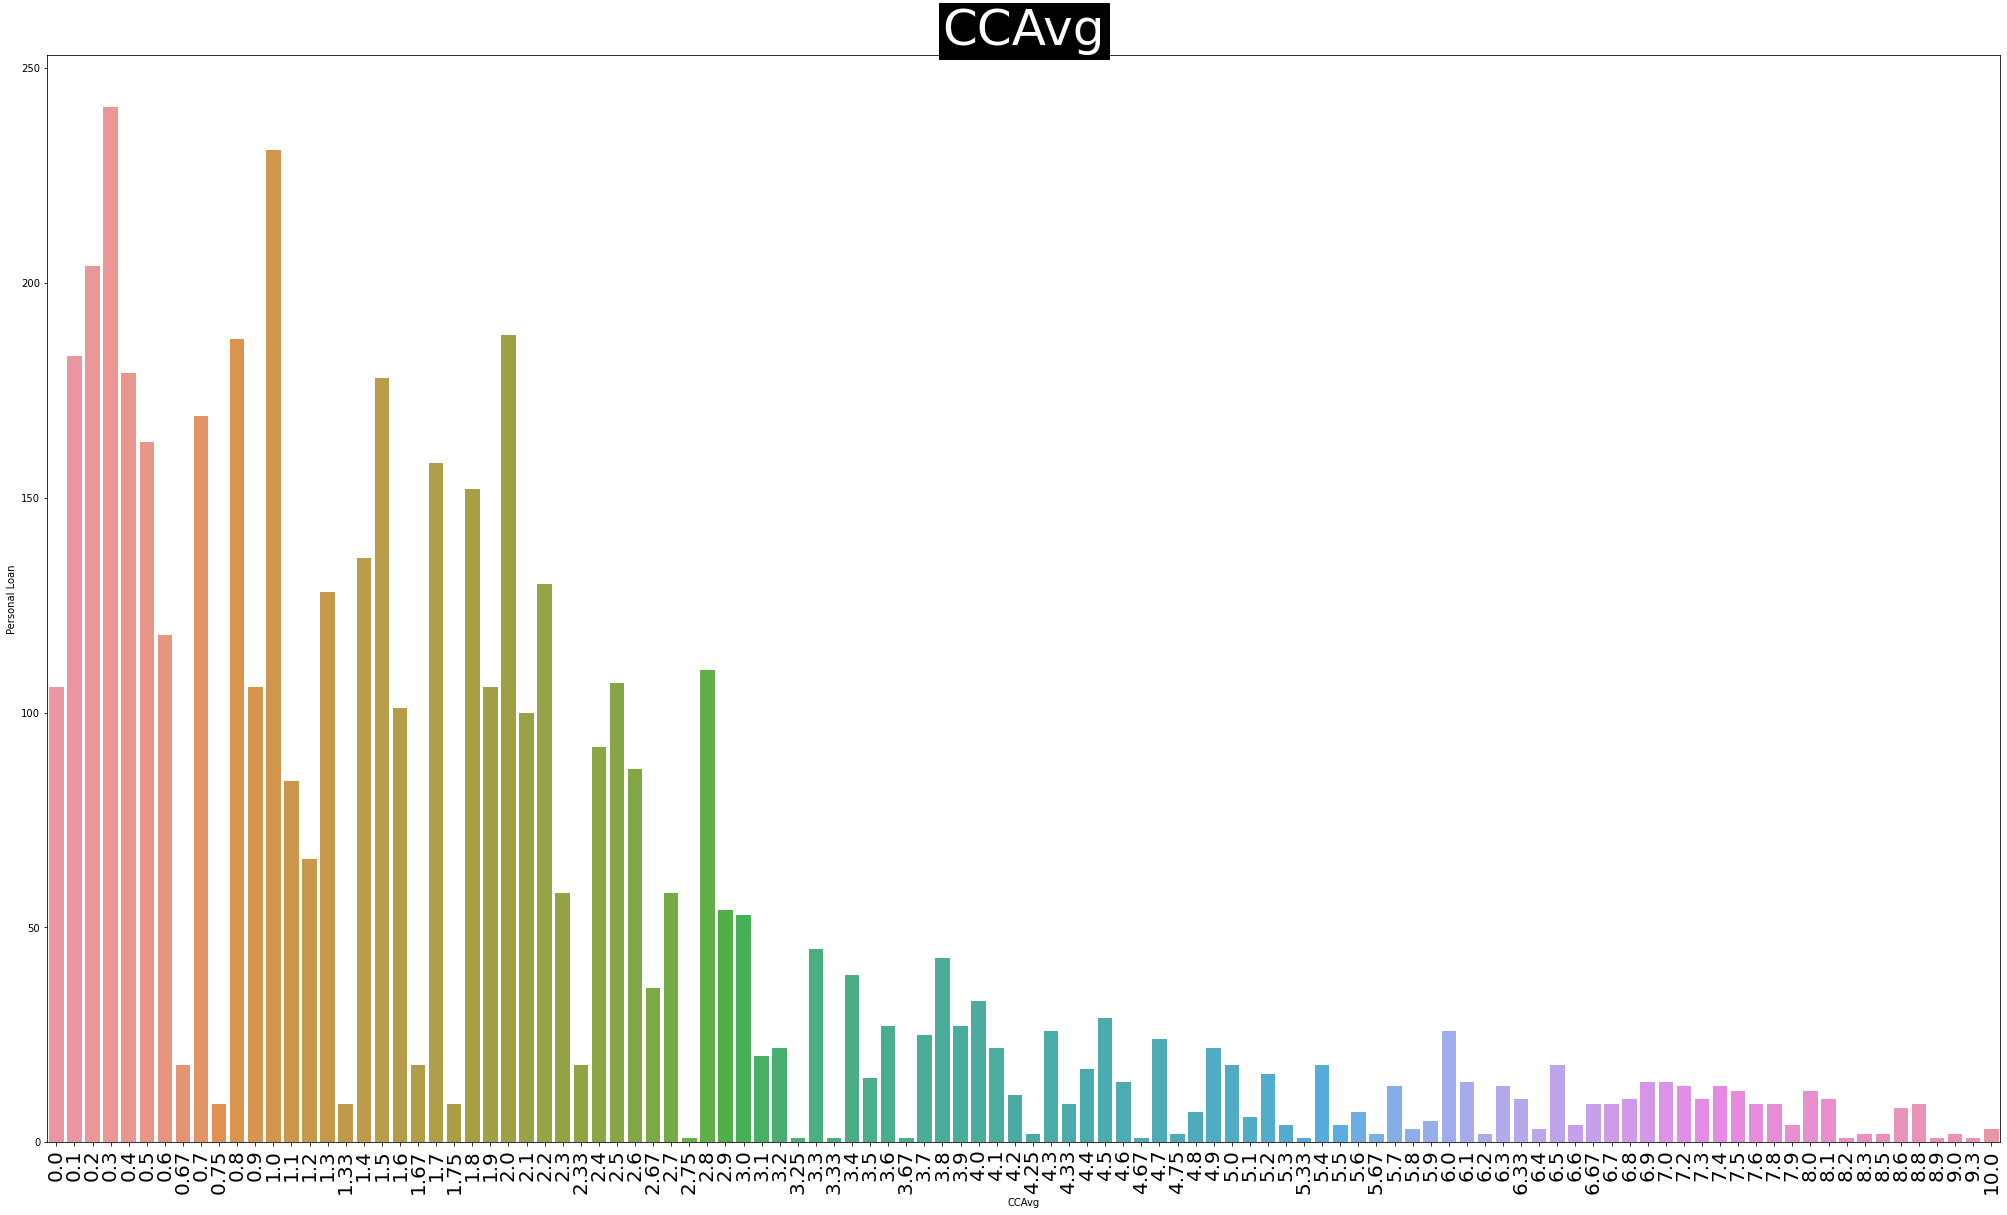

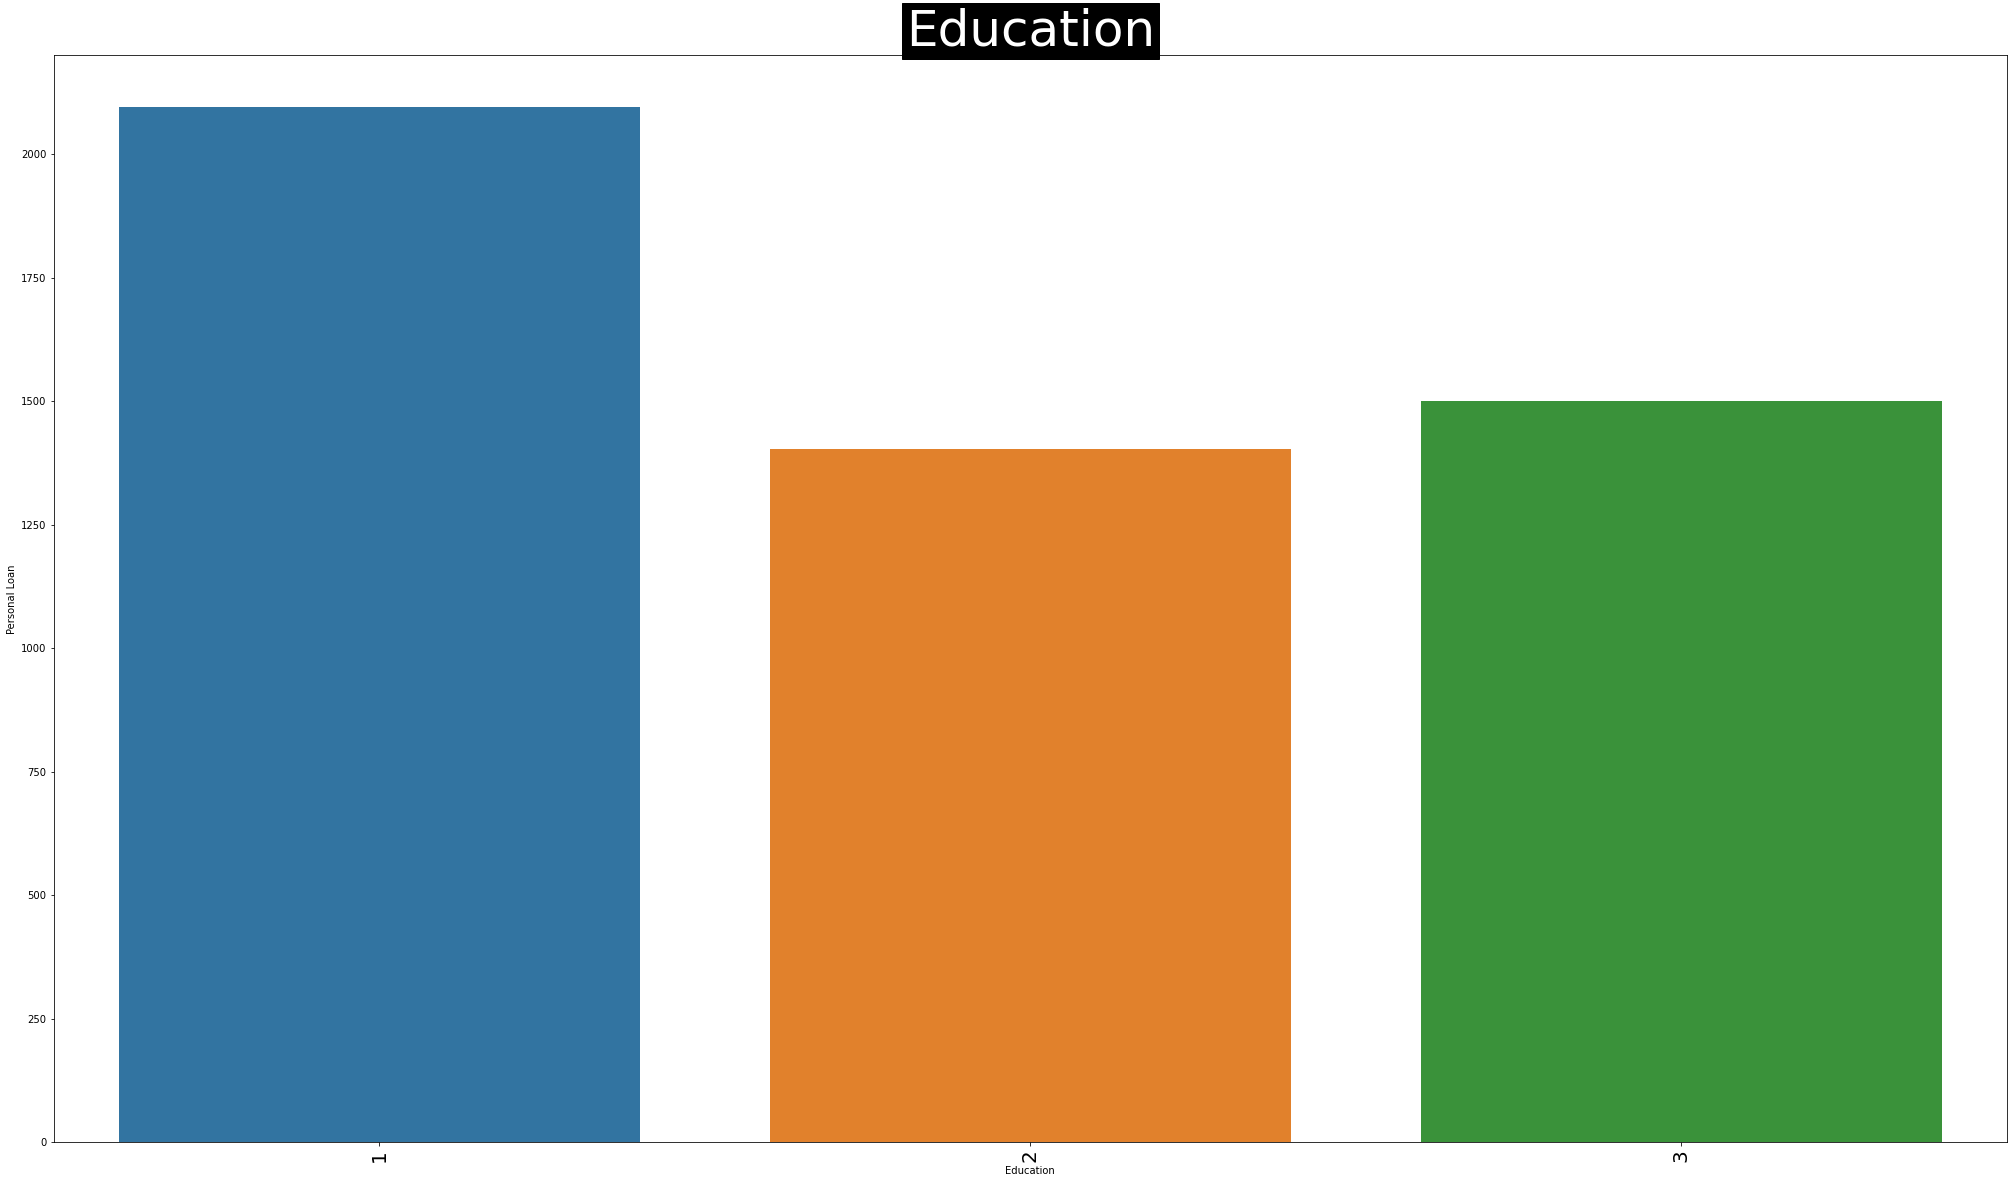

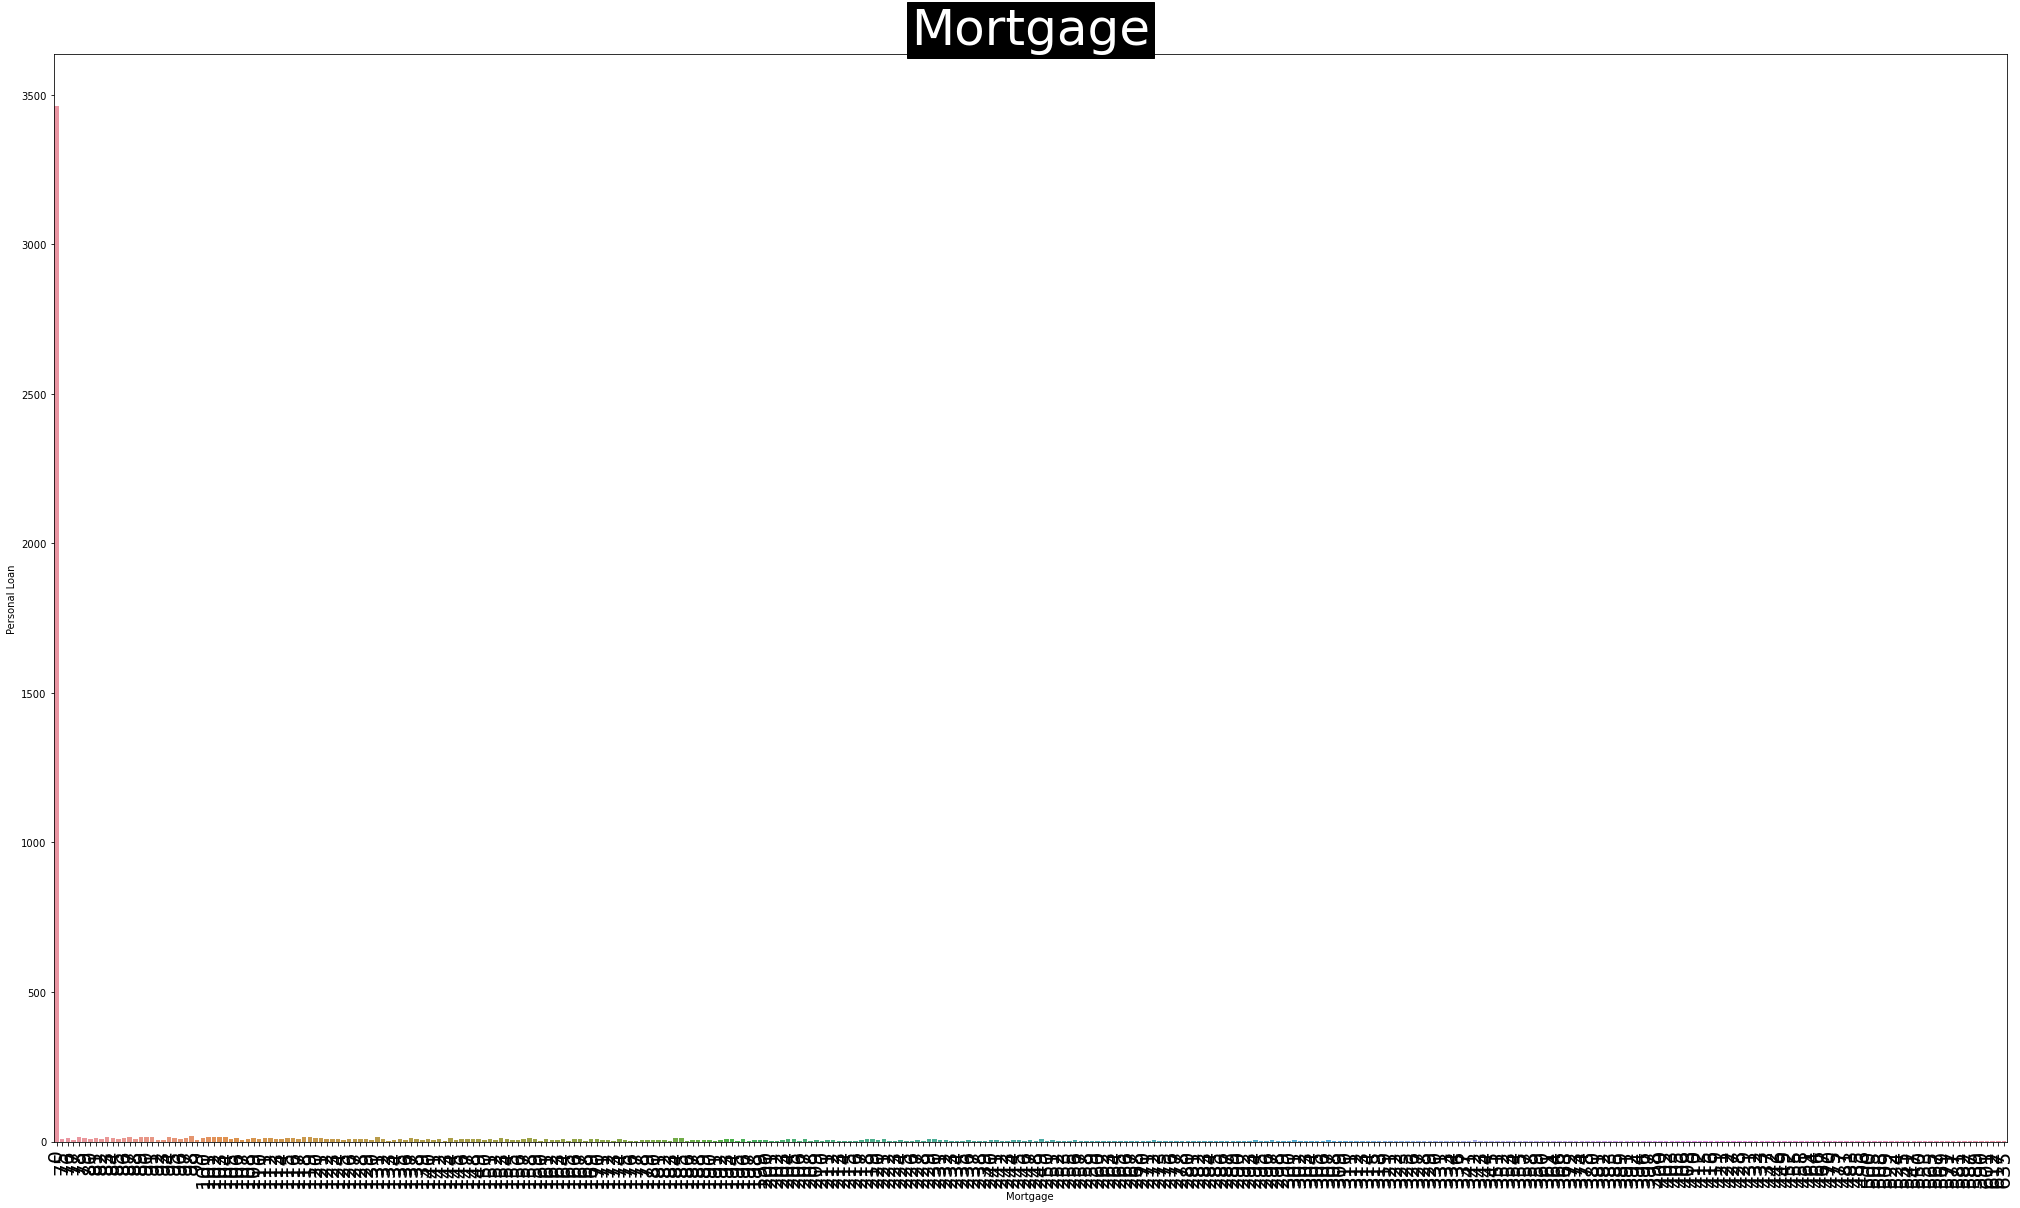

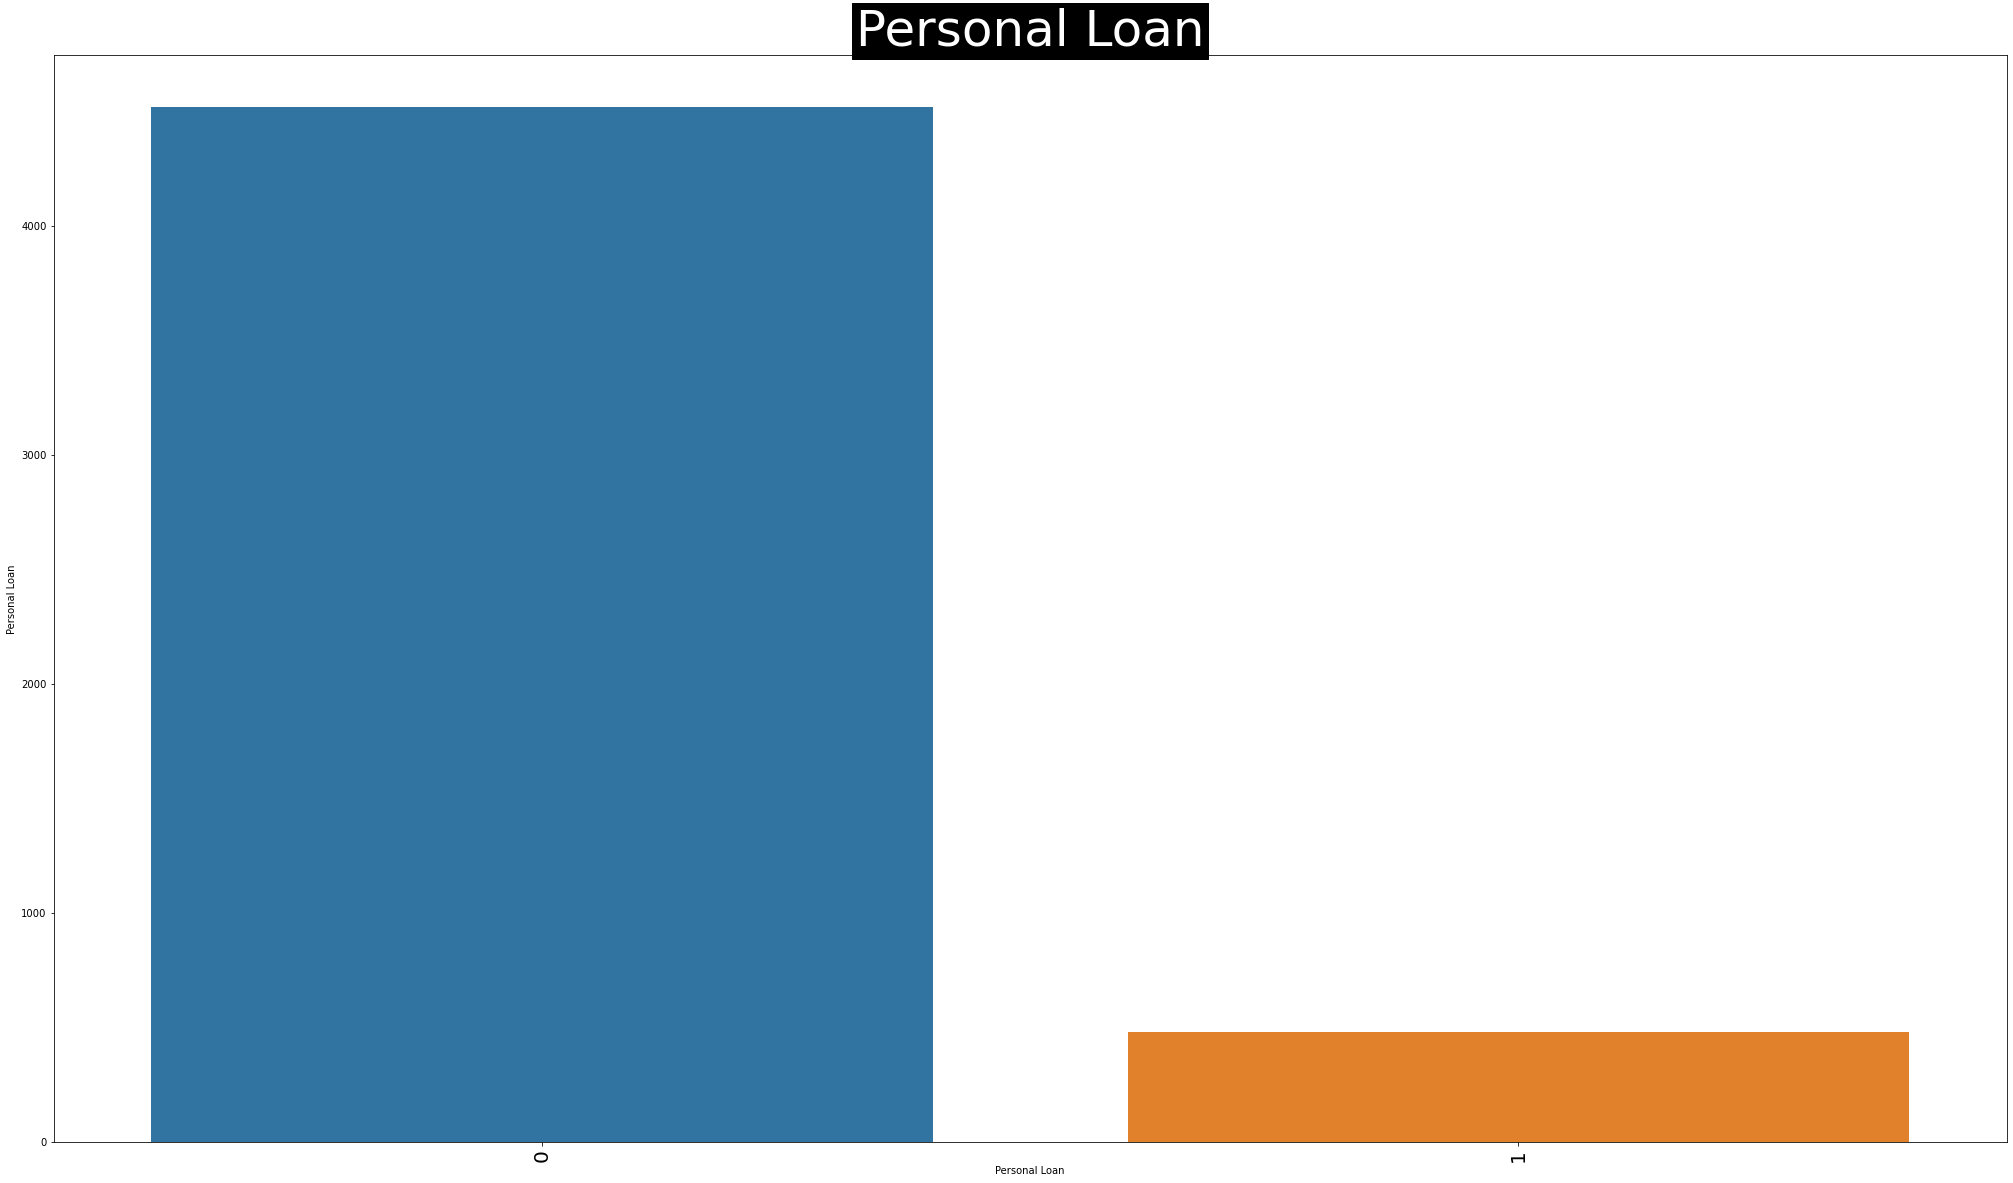

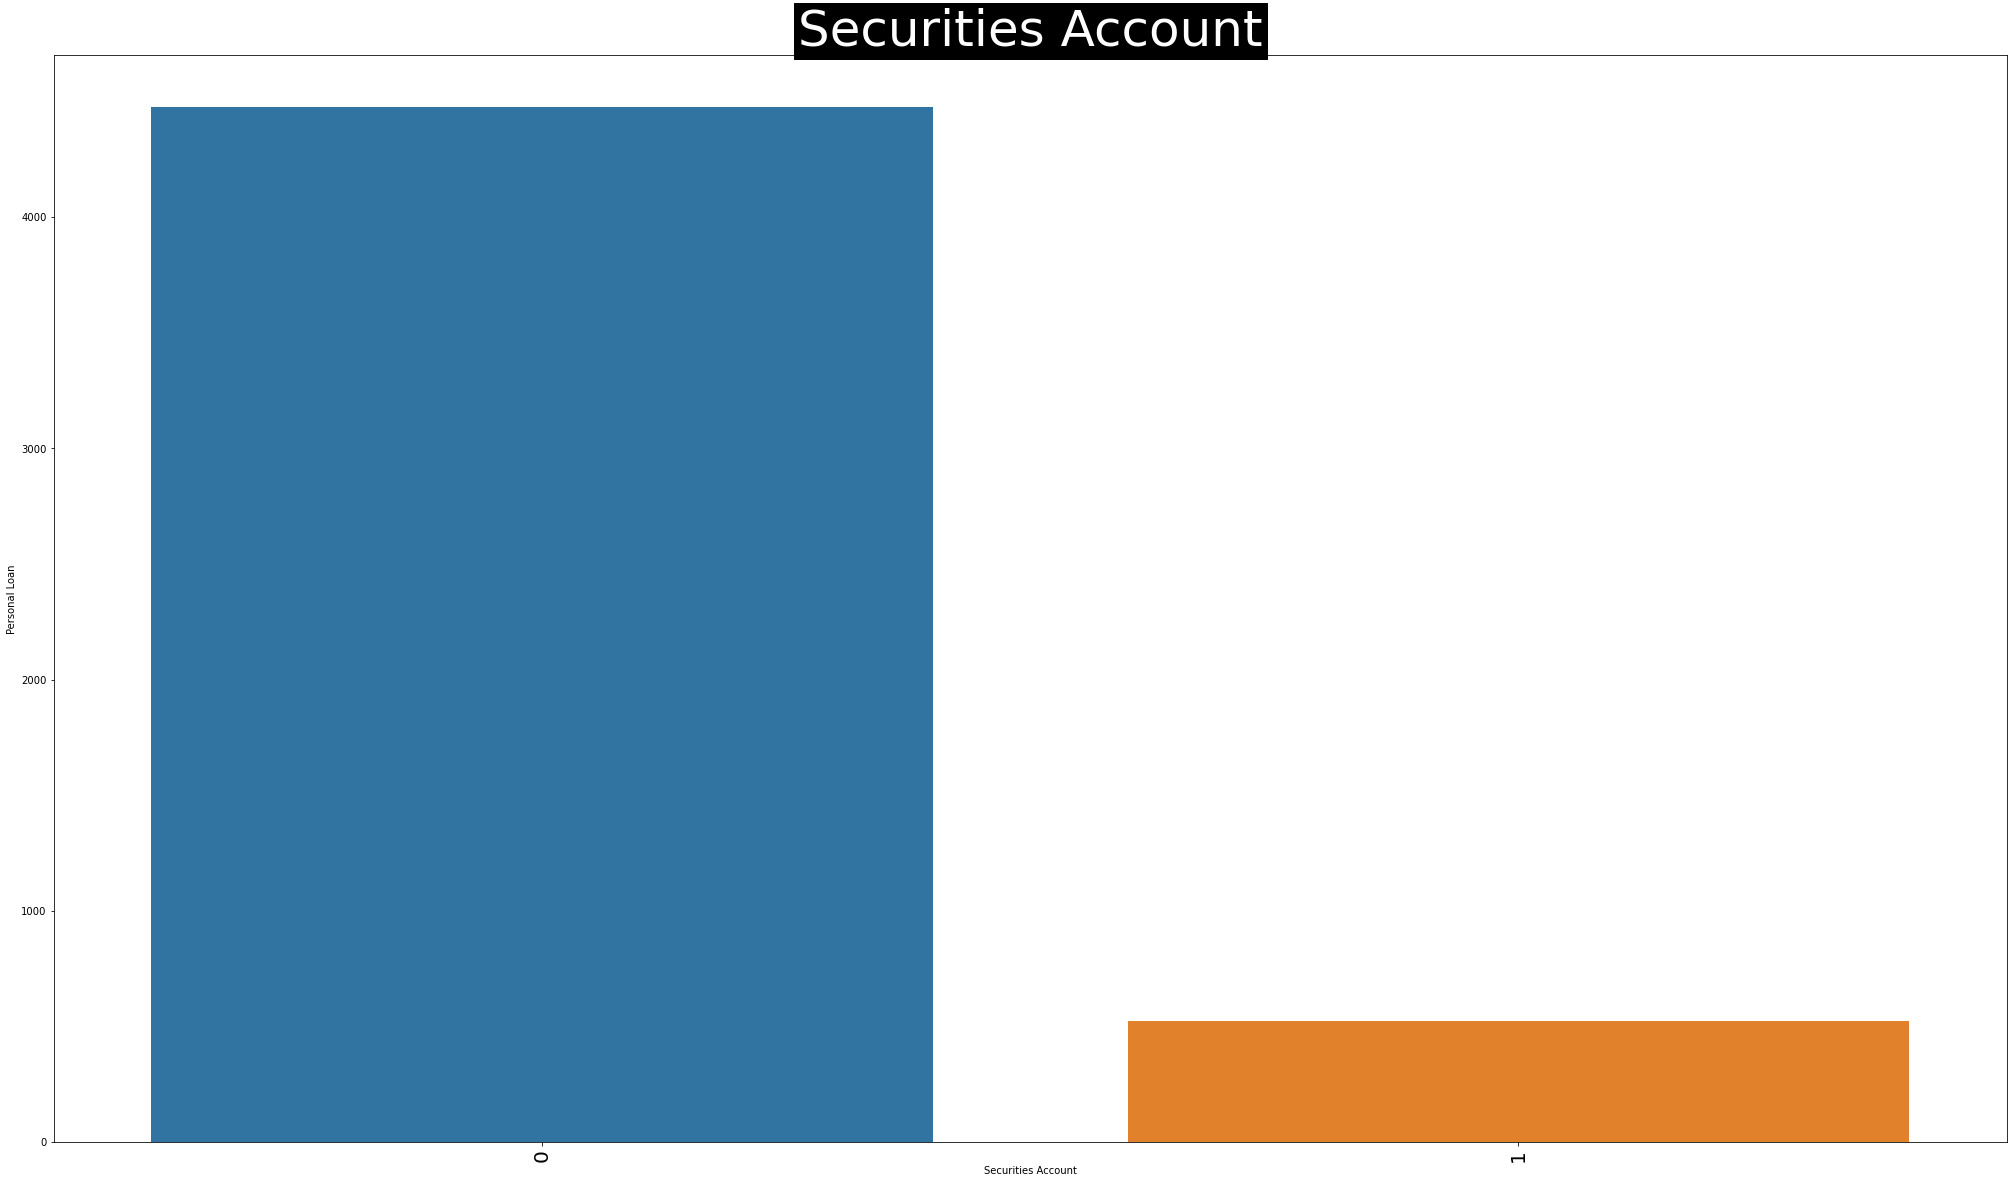

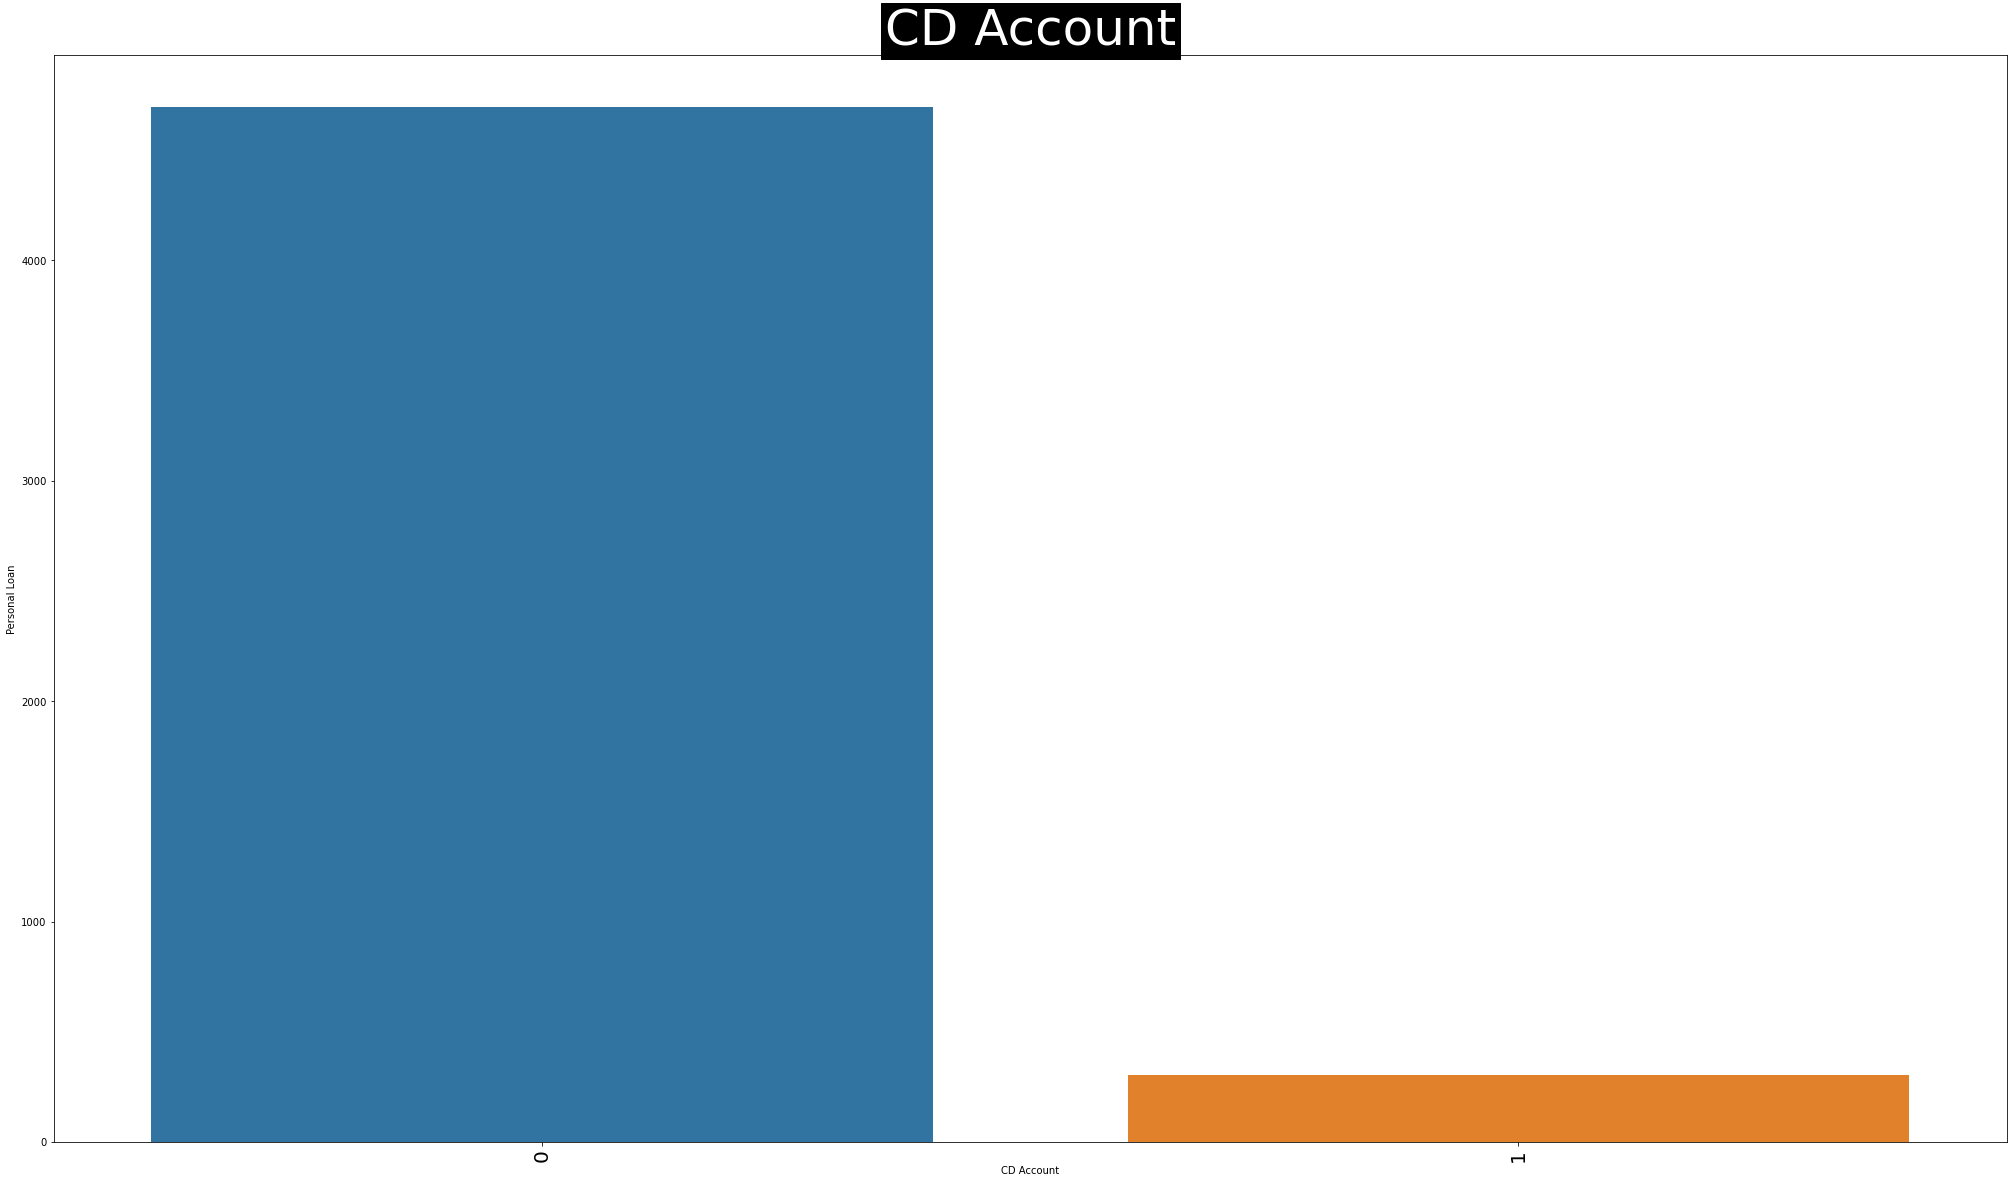

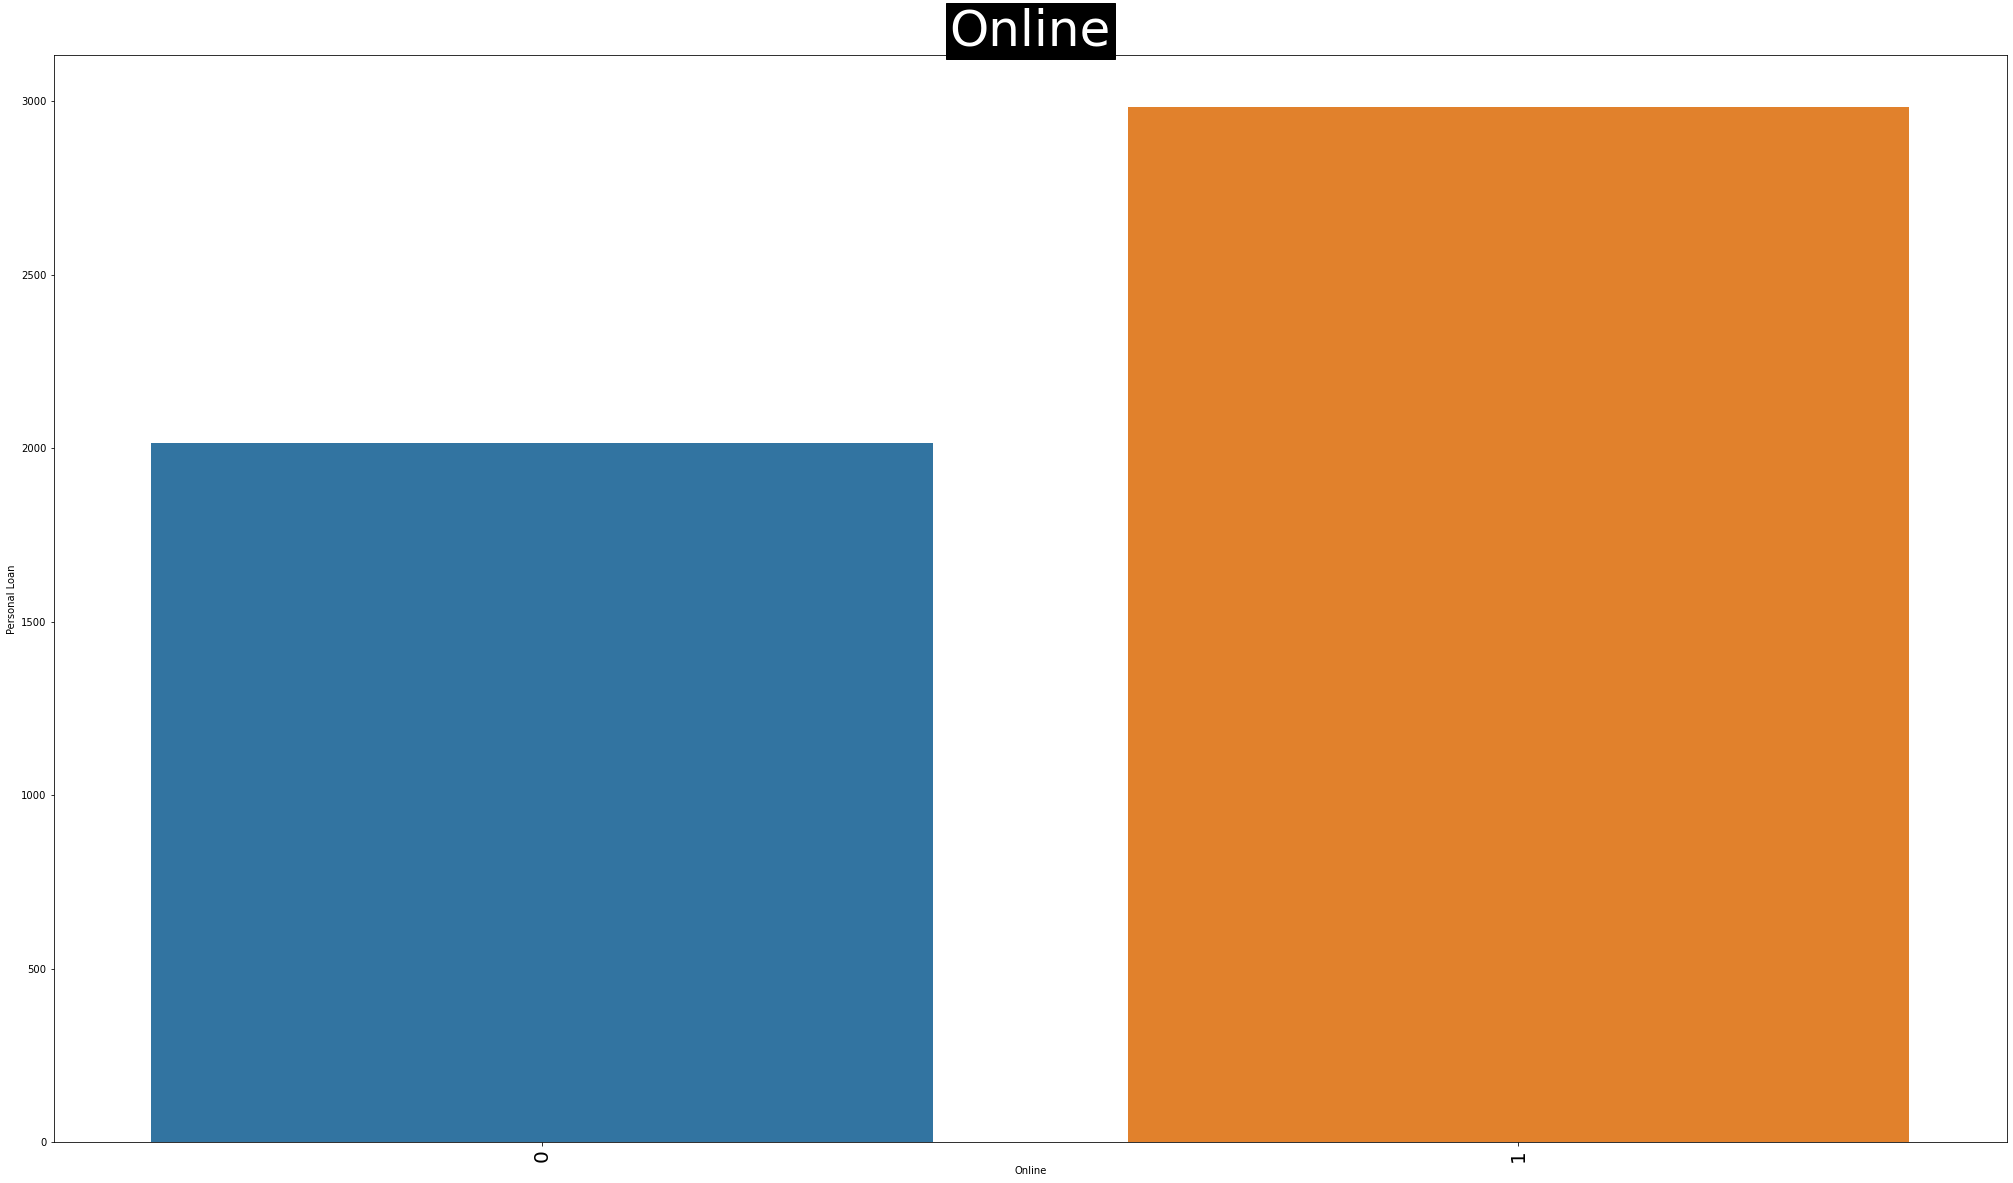

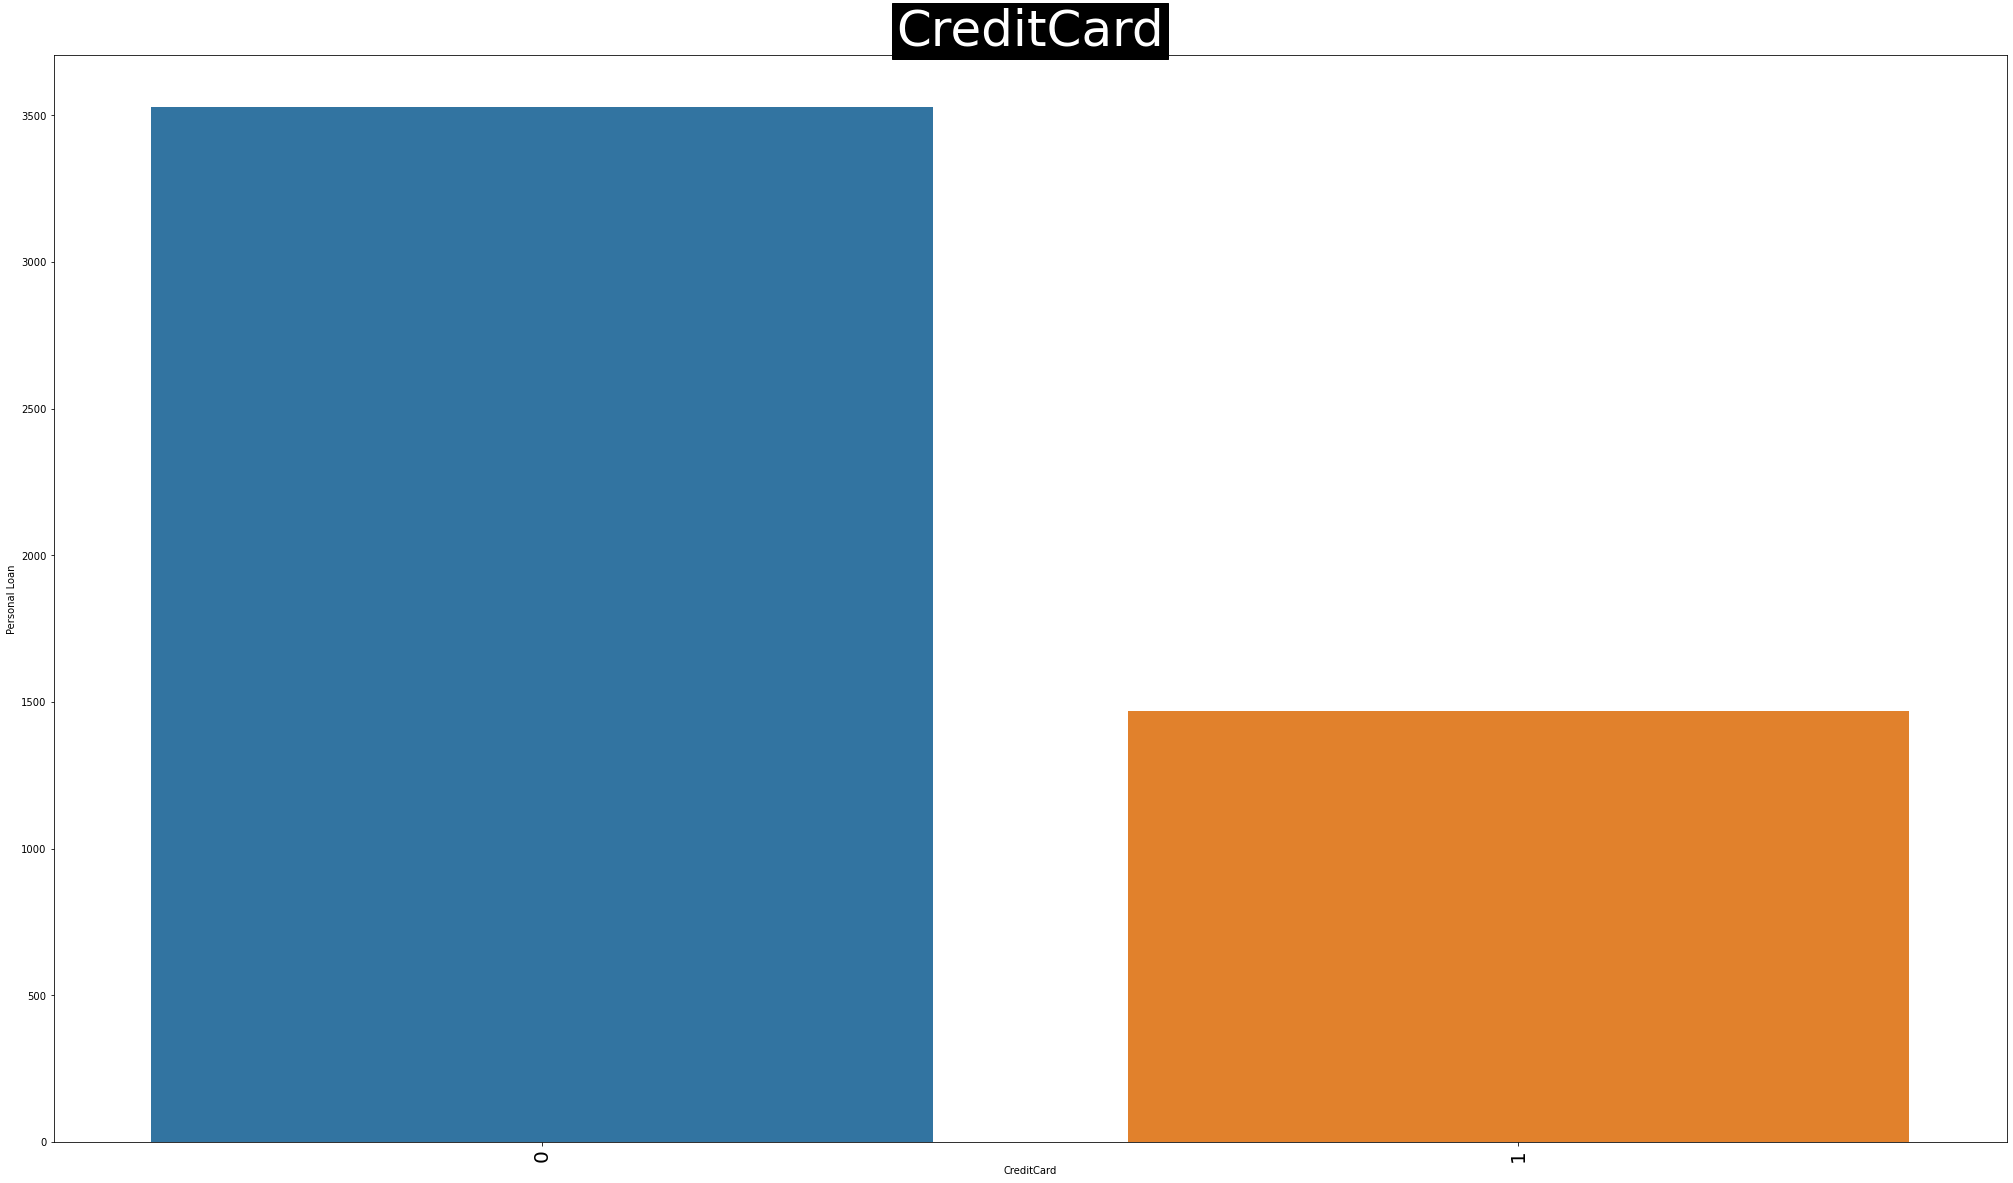

In [20]:
for column in df.drop(columns=['ID'],axis=1) :     
    plt.figure(figsize=(35,20))
    ax=sns.countplot(x=column,data = df)
    plt.xticks(rotation=90,fontsize=20)
    plt.ylabel('Personal Loan')
    plt.xlabel(column)
    plt.title(column,fontsize=50,backgroundcolor='black',color='white')
    #plt.savefig(column+ ' & Personal Loan.jpg')
    plt.show()

In [21]:
#  همه نامریکال ها به شکلی  از توضیع گاووسین پیروی کرده   به جز         <<<<<<<     کد پستی       >>>>>>ی

In [22]:
#  note 1 =====    Experience>>>>>>     -1         -2  -3        >>>>>>>   is noise 
#  note 2 =====    #ZIP Code    >>>>>>>>>    9307   is must ne five deg  <>><><><><><><><><> 

In [23]:
df['Experience']= abs(df['Experience'])

In [24]:
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [25]:
f=df[df['ZIP Code']<10000]

In [26]:
f

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
384,385,51,25,21,9307,4,0.6,3,0,0,0,0,1,1


In [27]:
#####  drop   index 385
df=df[df['ZIP Code']>10000]

In [28]:
df.reset_index(drop=True)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4995,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4996,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4997,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [29]:
#drop    ID    colume

In [30]:
df.drop('ID',axis=1,inplace=True)

In [31]:
#sns.pairplot(df)

In [32]:
for i in df.columns:     
    n = len(pd.unique(df[i]))
    print(i)
    print(n)
    print(df[i].unique())
    print('-----------------------------------------------------------------------------------------------------')
    

Age
45
[25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]
-----------------------------------------------------------------------------------------------------
Experience
44
[ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 34  0 38 40 33  4 42 43]
-----------------------------------------------------------------------------------------------------
Income
162
[ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15  74  30  38
   9  92  61  73  70 149  98 128  31  58  54 124 163  24  79 134  23  13
 138 171 168  65  10 148 159 169 144 165  59  68  91 172  55 155  53  89
  28  75 170 120  99 111  33 129 122 150 195 110 101 

In [33]:
# replace 0,1   to  2,3

Personal Loan - Securities Account - CD Account - CD Account - Online - CreditCard >>>  replace

In [34]:
data1=df[['Personal Loan','Securities Account','CD Account','Online','CreditCard']].replace([0,1],[2,3])

In [35]:
df1=df.drop(['Personal Loan','Securities Account','CD Account','Online','CreditCard'],axis=1)

In [36]:
data1

,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,2,3,2,2,2
1,2,3,2,2,2
2,2,2,2,2,2
3,2,2,2,2,2
4,2,2,2,2,3
...,...,...,...,...,...
4995,2,2,2,3,2
4996,2,2,2,3,2
4997,2,2,2,2,2
4998,2,2,2,3,2


In [37]:
df1

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage
0,25,1,49,91107,4,1.6,1,0
1,45,19,34,90089,3,1.5,1,0
2,39,15,11,94720,1,1.0,1,0
3,35,9,100,94112,1,2.7,2,0
4,35,8,45,91330,4,1.0,2,0
...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0
4996,30,4,15,92037,4,0.4,1,85
4997,63,39,24,93023,2,0.3,3,0
4998,65,40,49,90034,3,0.5,2,0


In [38]:
df1[['Personal Loan','Securities Account','CD Account','Online','CreditCard']]=data1[['Personal Loan','Securities Account','CD Account','Online','CreditCard']]

In [39]:
df1

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,2
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,2
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,2
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,2
4,35,8,45,91330,4,1.0,2,0,2,2,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,2,2,2,3,2
4996,30,4,15,92037,4,0.4,1,85,2,2,2,3,2
4997,63,39,24,93023,2,0.3,3,0,2,2,2,2,2
4998,65,40,49,90034,3,0.5,2,0,2,2,2,3,2


some peple ccavg > 0  but no creditcard

In [40]:
data=df1

In [41]:
data

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,2
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,2
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,2
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,2
4,35,8,45,91330,4,1.0,2,0,2,2,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,2,2,2,3,2
4996,30,4,15,92037,4,0.4,1,85,2,2,2,3,2
4997,63,39,24,93023,2,0.3,3,0,2,2,2,2,2
4998,65,40,49,90034,3,0.5,2,0,2,2,2,3,2


In [42]:
cardyes=data[(data['CreditCard']==3)]
cardyes

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
4,35,8,45,91330,4,1.0,2,0,2,2,2,2,3
7,50,24,22,93943,1,0.3,3,0,2,2,2,2,3
15,60,30,22,95054,1,1.5,3,0,2,2,2,3,3
19,55,28,21,94720,1,0.5,2,0,2,3,2,2,3
24,36,11,152,95521,2,3.9,1,159,2,2,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4984,27,1,98,94043,4,2.3,3,0,2,2,2,2,3
4988,34,8,85,95134,1,2.5,1,136,2,2,2,2,3
4990,55,25,58,95023,4,2.0,3,219,2,2,2,2,3
4991,51,25,92,91330,1,1.9,2,100,2,2,2,2,3


In [43]:
cardno=data[(data['CreditCard']==2)]
cardno

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,2
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,2
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,2
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,2
5,37,13,29,92121,4,0.4,2,155,2,2,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,64,40,75,94588,3,2.0,3,0,2,2,2,3,2
4995,29,3,40,92697,1,1.9,3,0,2,2,2,3,2
4996,30,4,15,92037,4,0.4,1,85,2,2,2,3,2
4997,63,39,24,93023,2,0.3,3,0,2,2,2,2,2


In [44]:
cardno_ccno=data[(data['CreditCard']==2)&(data['CCAvg']==0)]
cardno_ccno

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
63,42,17,32,94523,4,0.0,2,0,2,2,2,3,2
128,38,14,74,92182,2,0.0,1,0,2,3,2,3,2
198,27,3,59,94123,4,0.0,1,90,2,3,2,3,2
210,51,26,20,92131,2,0.0,1,0,2,2,2,2,2
253,47,21,138,94583,1,0.0,1,0,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4502,57,32,80,92647,2,0.0,3,0,2,2,2,2,2
4801,34,10,88,94404,2,0.0,1,121,2,2,2,3,2
4826,56,31,81,93943,2,0.0,3,225,2,2,2,2,2
4837,36,10,183,95348,2,0.0,1,0,2,2,2,2,2


In [45]:
cardno_ccyes=data[(data['CreditCard']==2)&(data['CCAvg']>0)]
cardno_ccyes

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,2
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,2
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,2
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,2
5,37,13,29,92121,4,0.4,2,155,2,2,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,64,40,75,94588,3,2.0,3,0,2,2,2,3,2
4995,29,3,40,92697,1,1.9,3,0,2,2,2,3,2
4996,30,4,15,92037,4,0.4,1,85,2,2,2,3,2
4997,63,39,24,93023,2,0.3,3,0,2,2,2,2,2


In [46]:
cardno_ccyes['CreditCard'].replace(2,3,inplace=True)

In [47]:
cardno_ccyes

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,3
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,3
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,3
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,3
5,37,13,29,92121,4,0.4,2,155,2,2,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,64,40,75,94588,3,2.0,3,0,2,2,2,3,3
4995,29,3,40,92697,1,1.9,3,0,2,2,2,3,3
4996,30,4,15,92037,4,0.4,1,85,2,2,2,3,3
4997,63,39,24,93023,2,0.3,3,0,2,2,2,2,3


In [48]:
card11=cardno_ccyes.append(cardno_ccno)

In [49]:
card11

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,3
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,3
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,3
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,3
5,37,13,29,92121,4,0.4,2,155,2,2,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4502,57,32,80,92647,2,0.0,3,0,2,2,2,2,2
4801,34,10,88,94404,2,0.0,1,121,2,2,2,3,2
4826,56,31,81,93943,2,0.0,3,225,2,2,2,2,2
4837,36,10,183,95348,2,0.0,1,0,2,2,2,2,2


In [50]:
card=card11.append(cardyes)

In [51]:
card

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,3
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,3
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,3
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,3
5,37,13,29,92121,4,0.4,2,155,2,2,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4984,27,1,98,94043,4,2.3,3,0,2,2,2,2,3
4988,34,8,85,95134,1,2.5,1,136,2,2,2,2,3
4990,55,25,58,95023,4,2.0,3,219,2,2,2,2,3
4991,51,25,92,91330,1,1.9,2,100,2,2,2,2,3


In [52]:
card['CreditCard'].describe()

count    4999.000000
mean        2.984397
std         0.123947
min         2.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         3.000000
Name: CreditCard, dtype: float64

In [53]:
for i in card.columns:     
    n = len(pd.unique(card[i]))
    print(i)
    print(n)
    print(card[i].unique())
    print('----------------------------------------------------------------------------------------------------')

Age
45
[25 45 39 35 37 53 34 65 29 48 59 67 38 42 46 56 57 44 43 40 30 31 51 32
 61 50 41 55 28 49 47 62 58 54 33 27 60 66 24 52 36 64 26 63 23]
----------------------------------------------------------------------------------------------------
Experience
44
[ 1 19 15  9 13 27 10 39  5 23 32 41 14 18 21 31 16 35 28  6 24 25  7  8
 37 26 17 30  2 36 29 20 22 34 12  0 38 40 33  4  3 11 42 43]
----------------------------------------------------------------------------------------------------
Income
162
[ 49  34  11 100  29  72  81 180 105  45 114  40 112 130 193  25  63  62
  43  83  35  41  18  50  71 141  80  84  60 132   8 131 190  44 139  93
 188  39 125  22  20  69  12 133  19  82 109  42  78  51 118  64 121  48
 161  94  15  74  30  32   9  92  61  73  38  98 128  70 163  58 134  52
  21  13 138 171 168  85  65  10 135 148 115 159 169 144  68  31  55 155
 104  75 170 120  24 111  23 129  33 172 150 152 195  91 165 119 110 101
  99 158 191  28 140 153  89 113 173 174  90  53 179  5

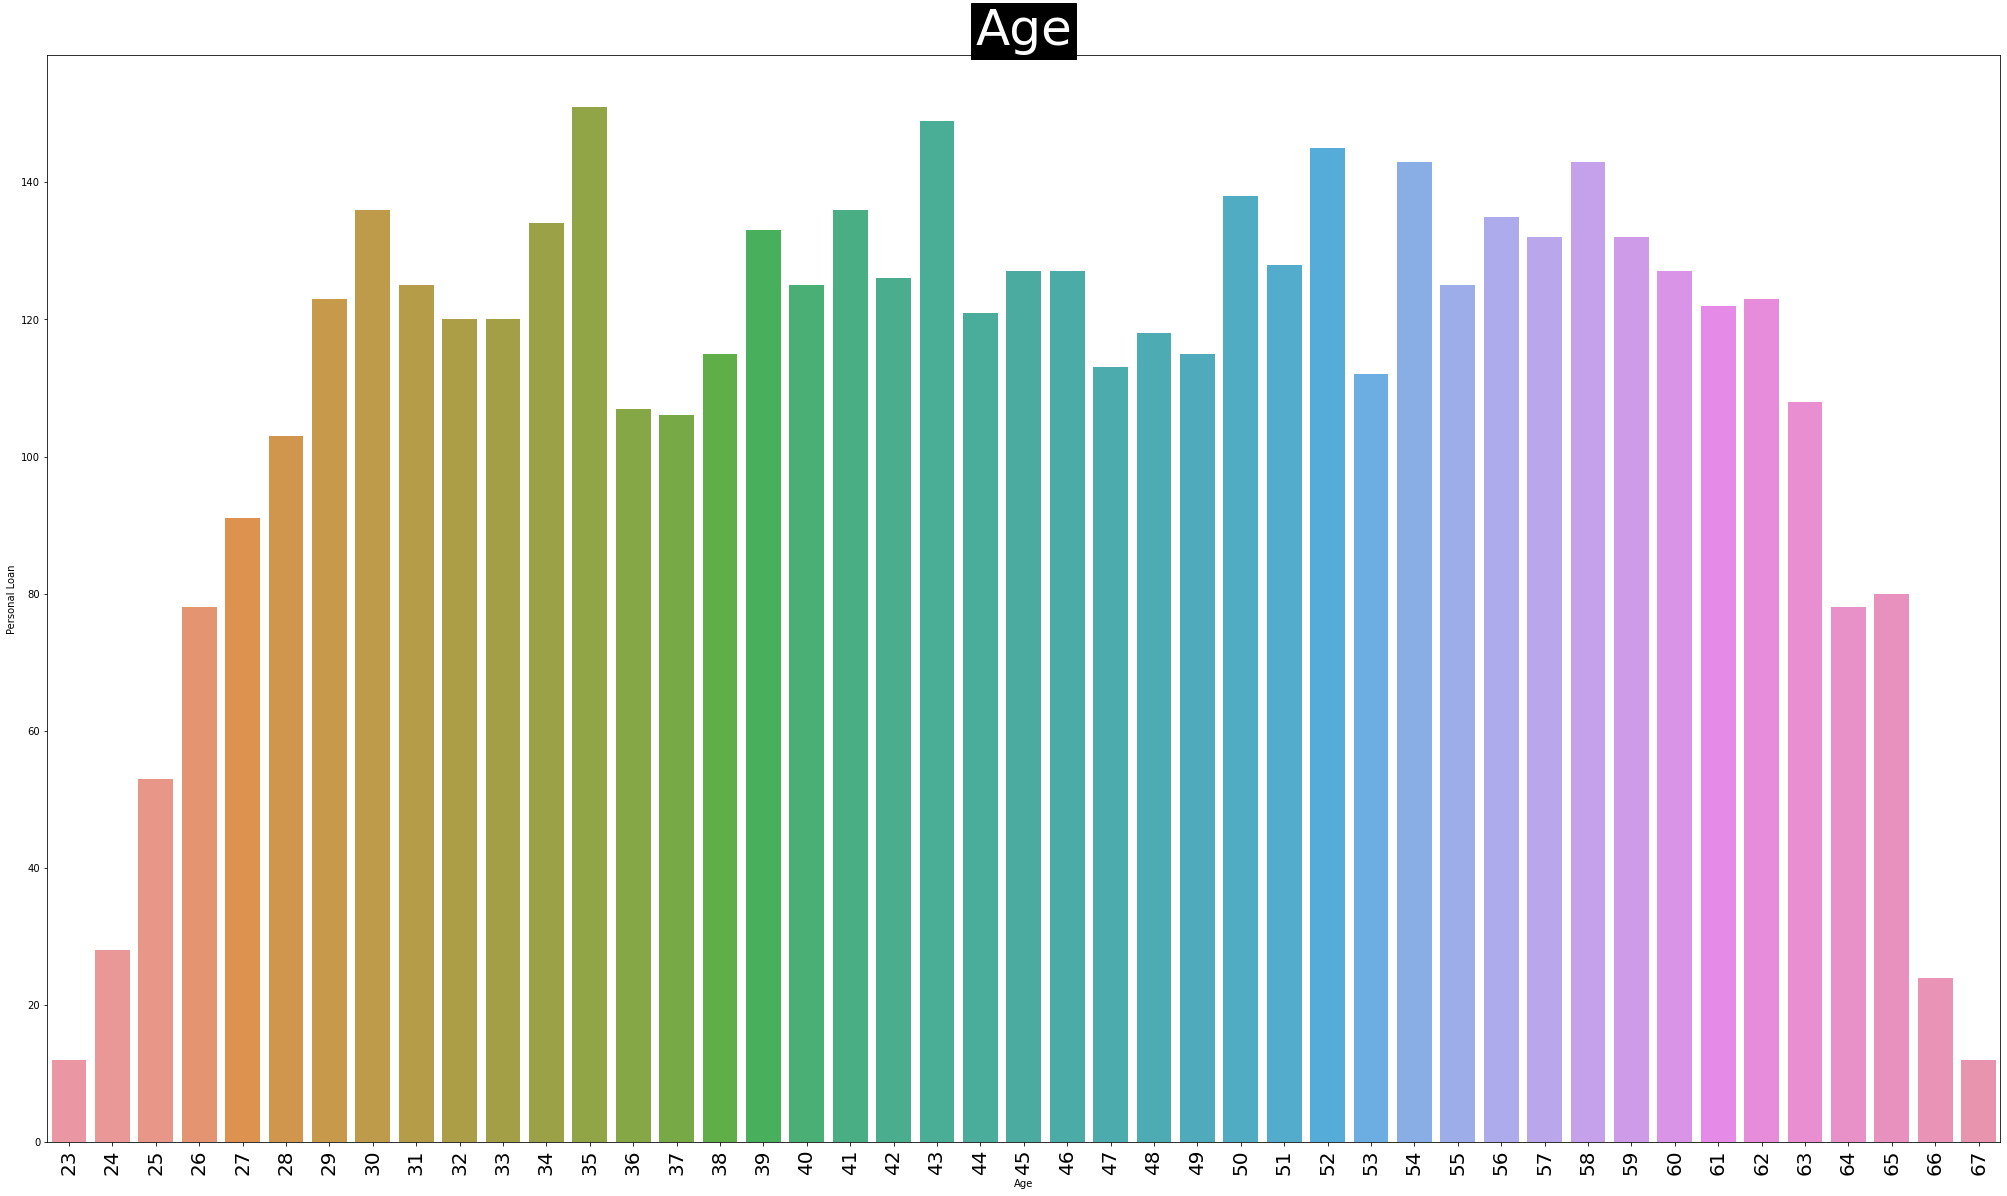

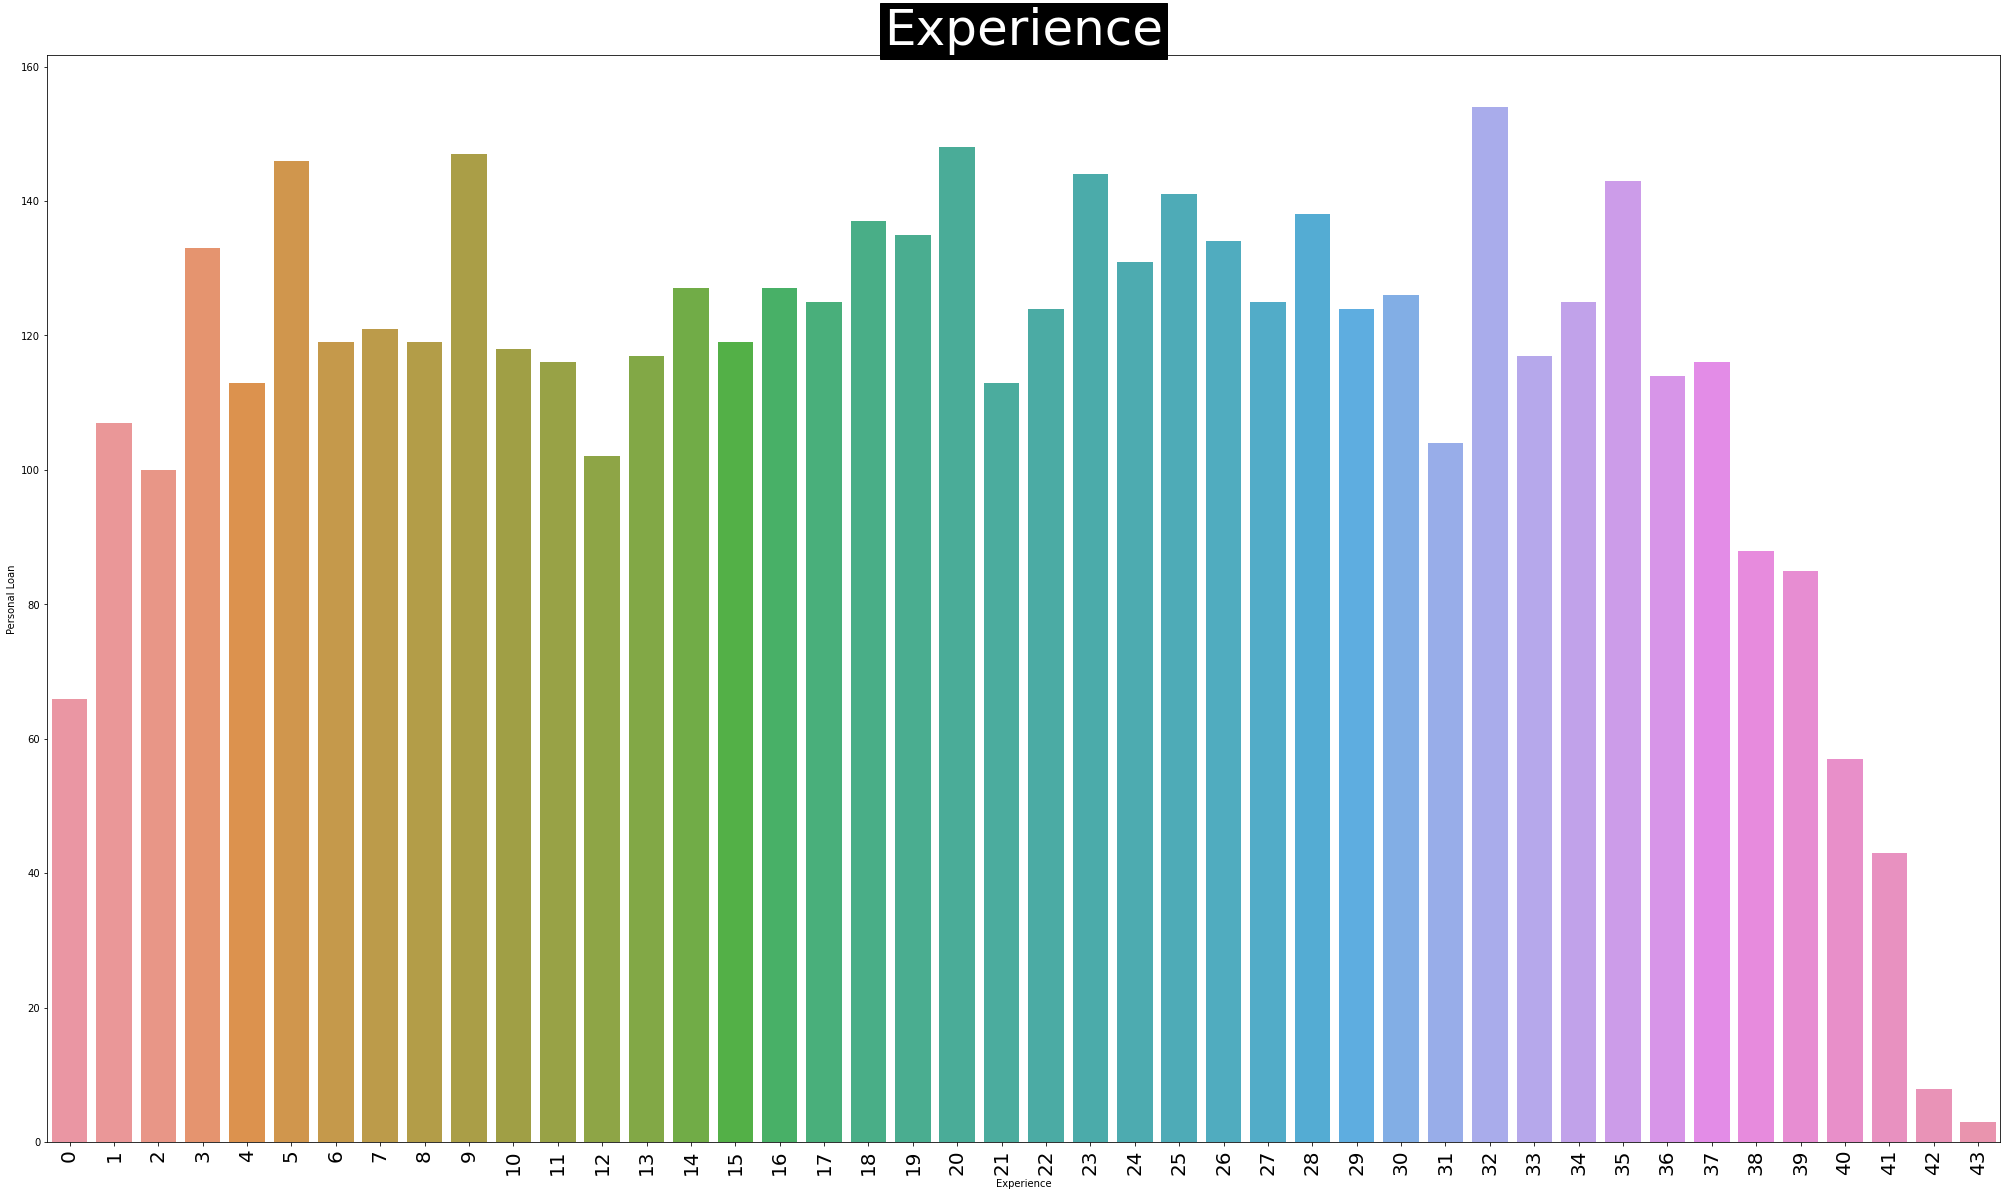

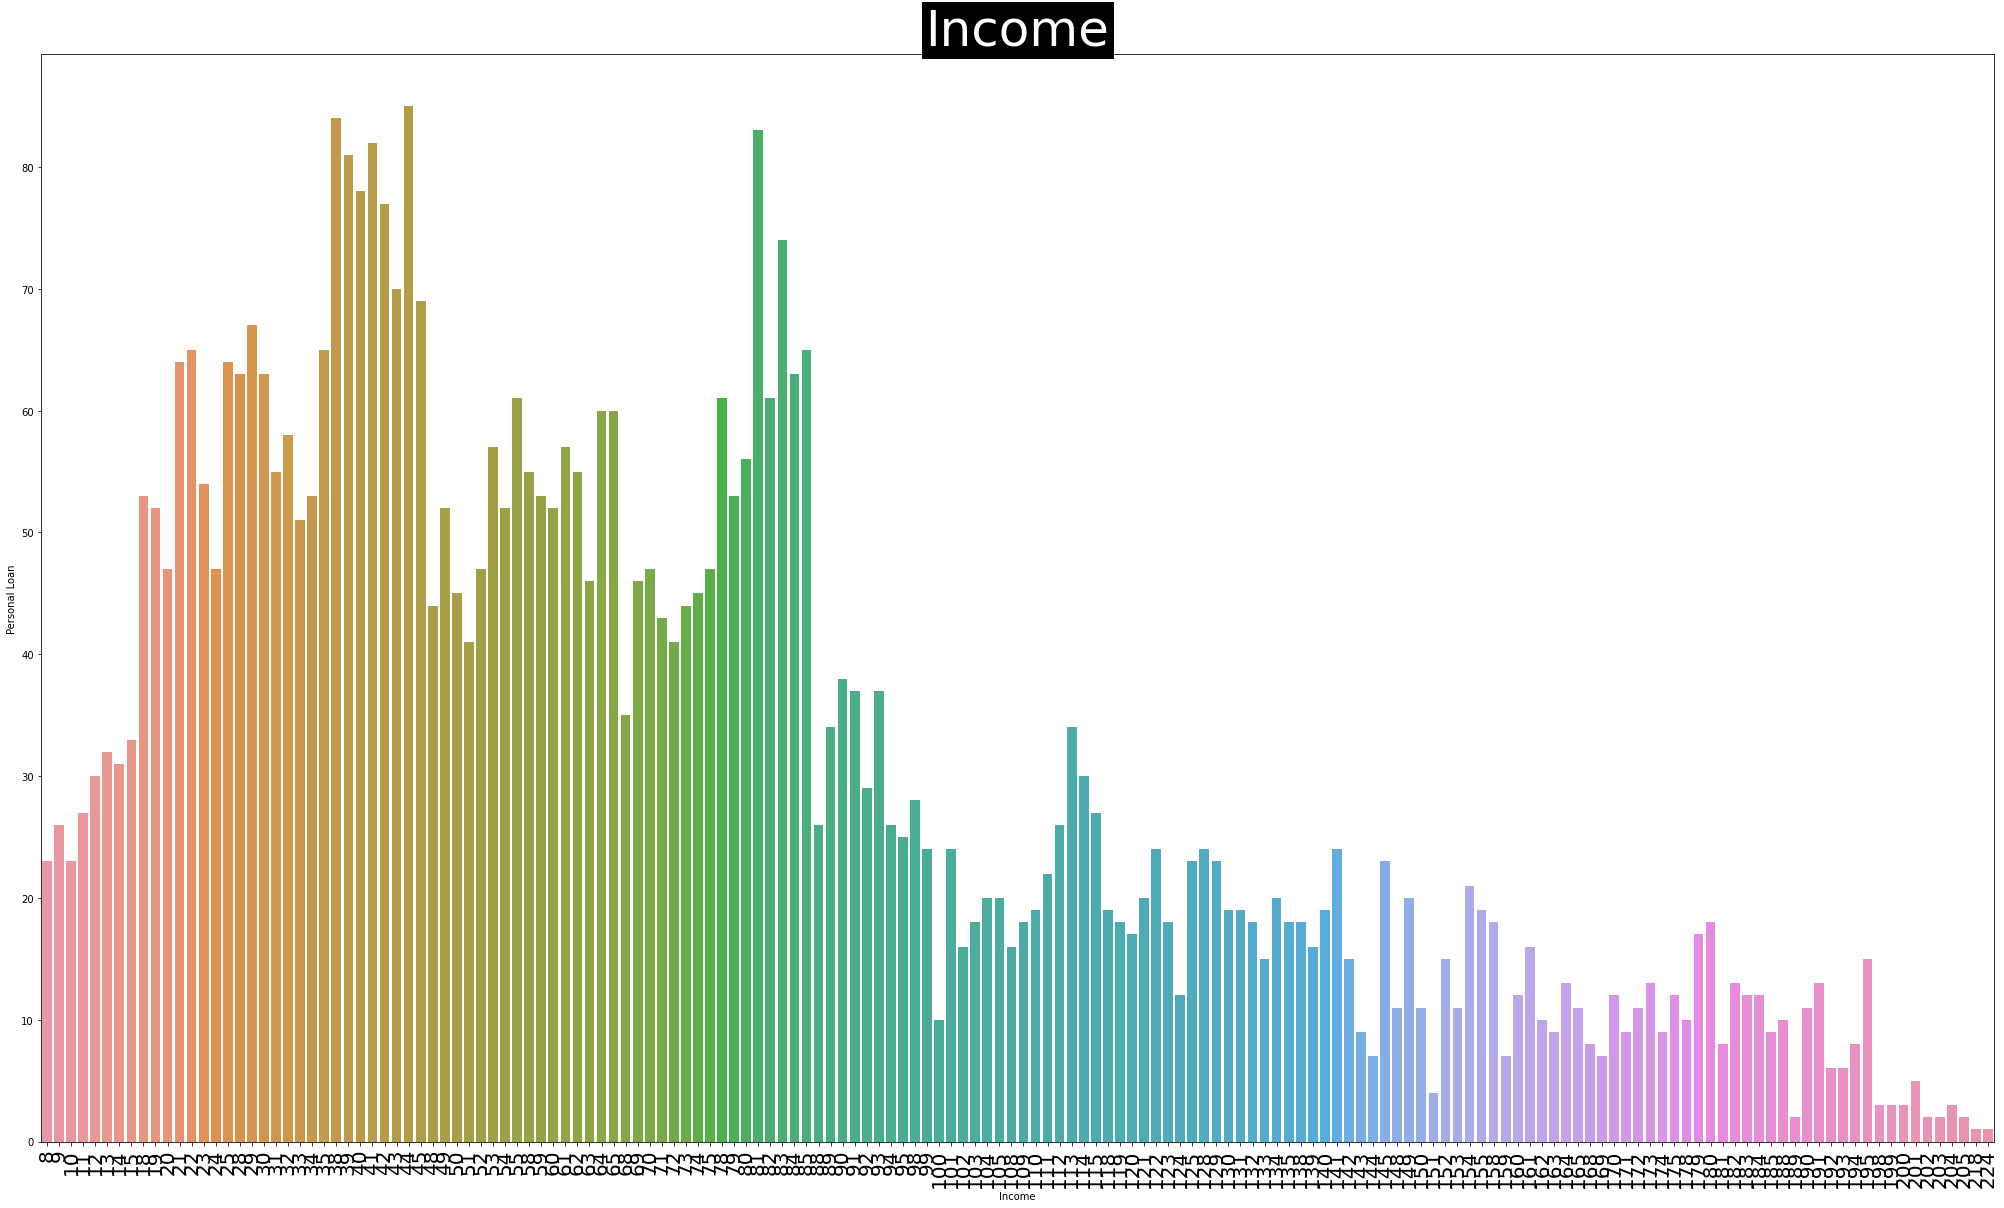

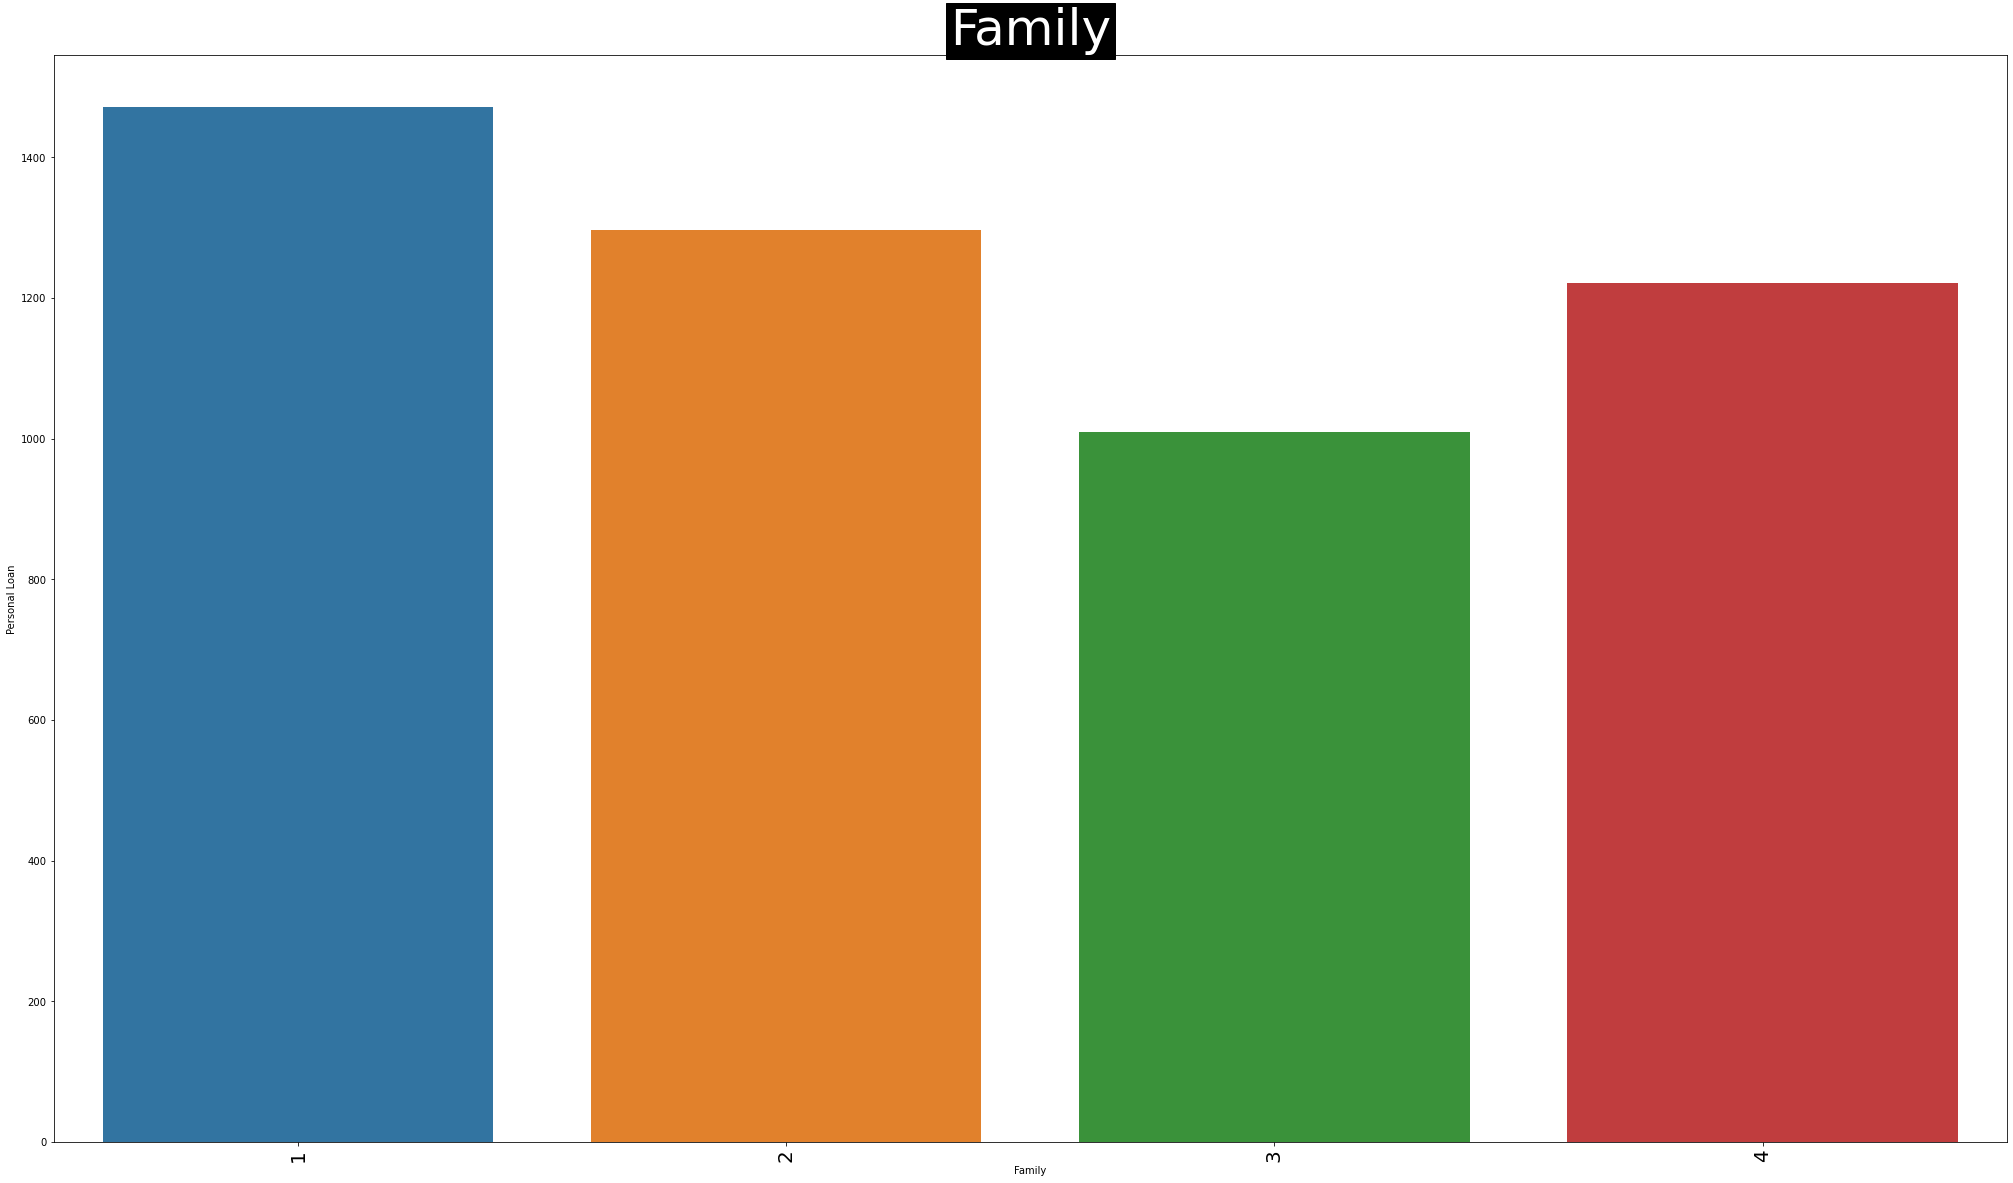

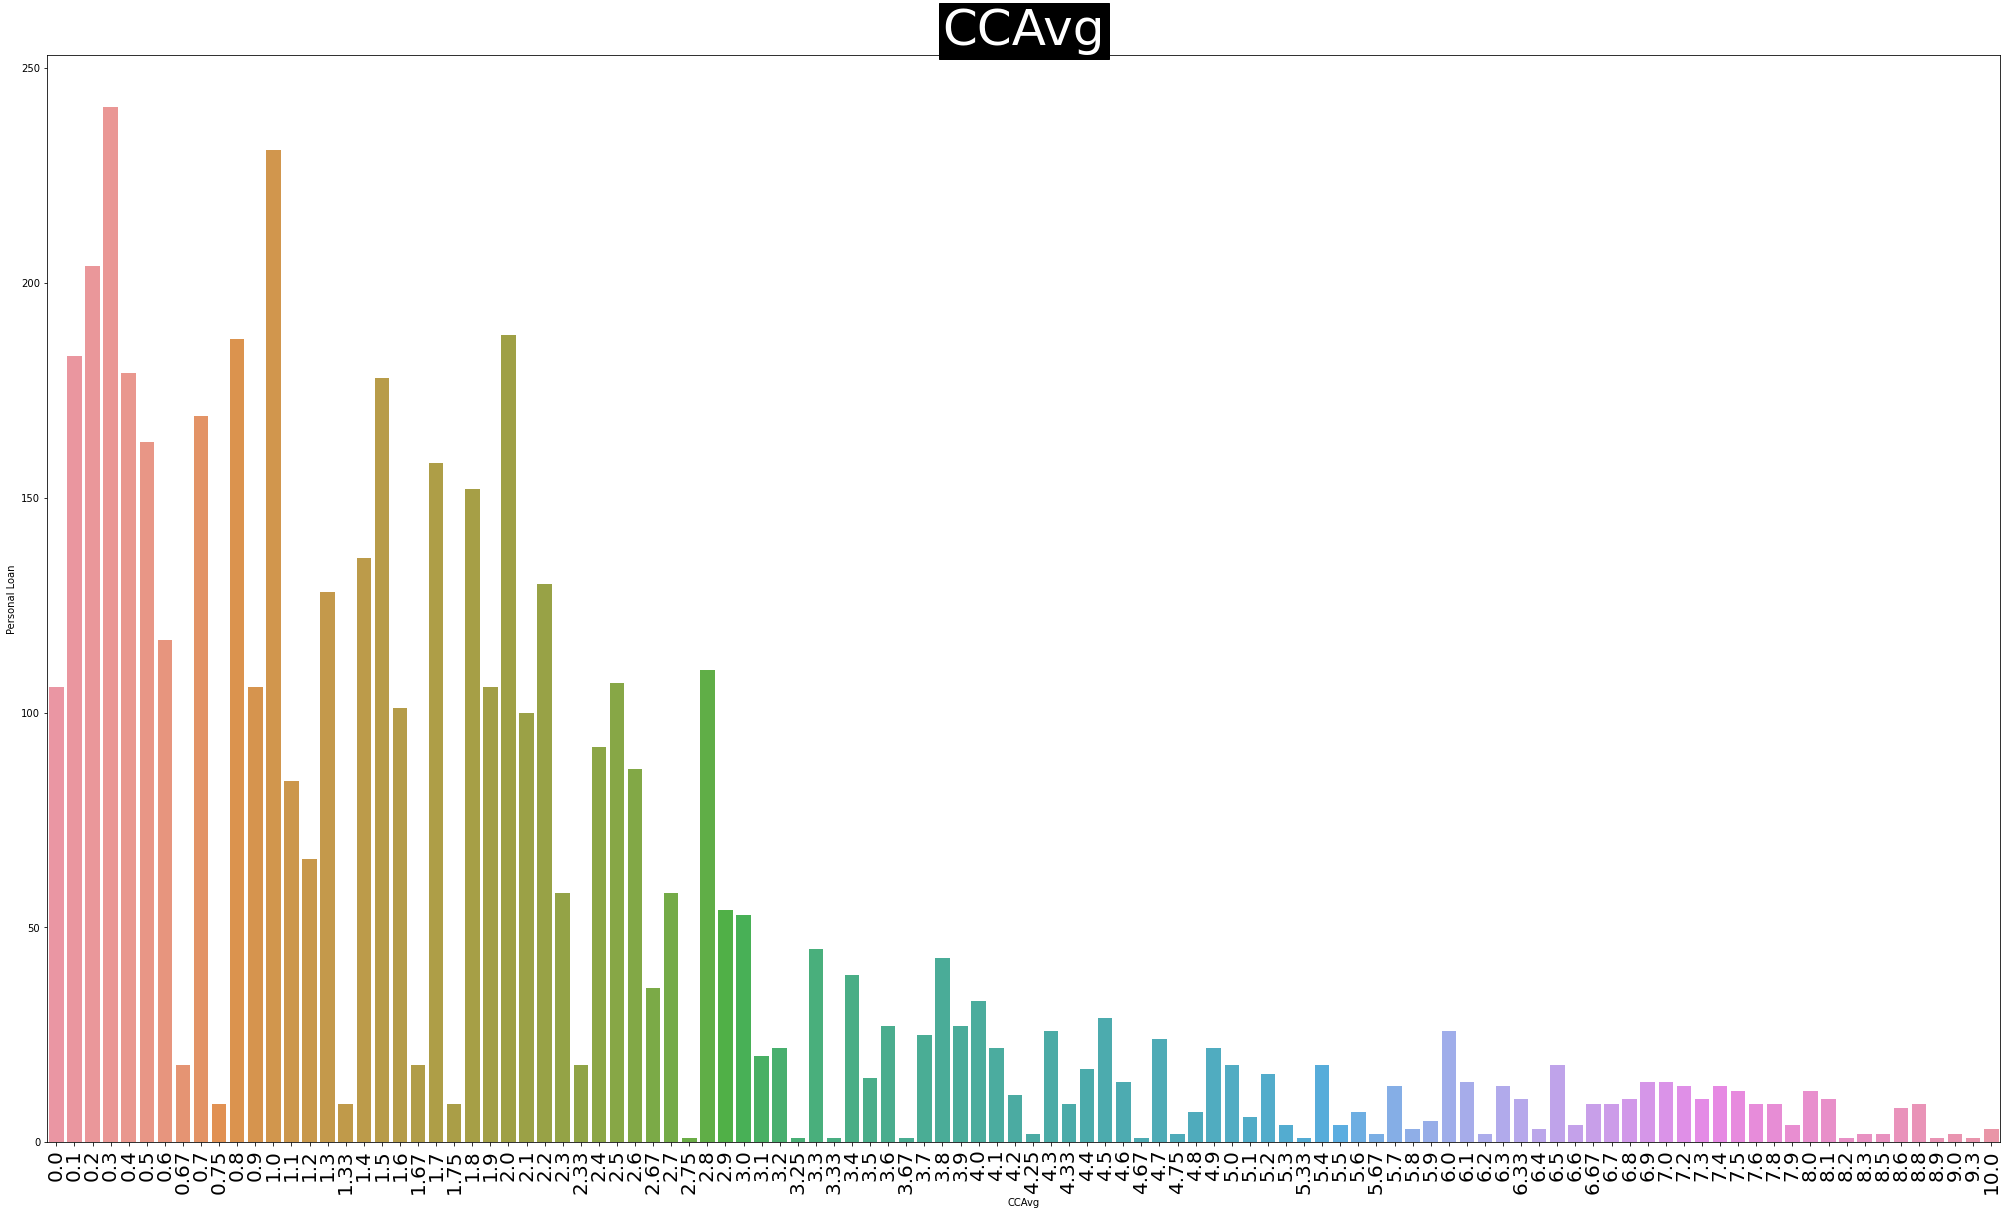

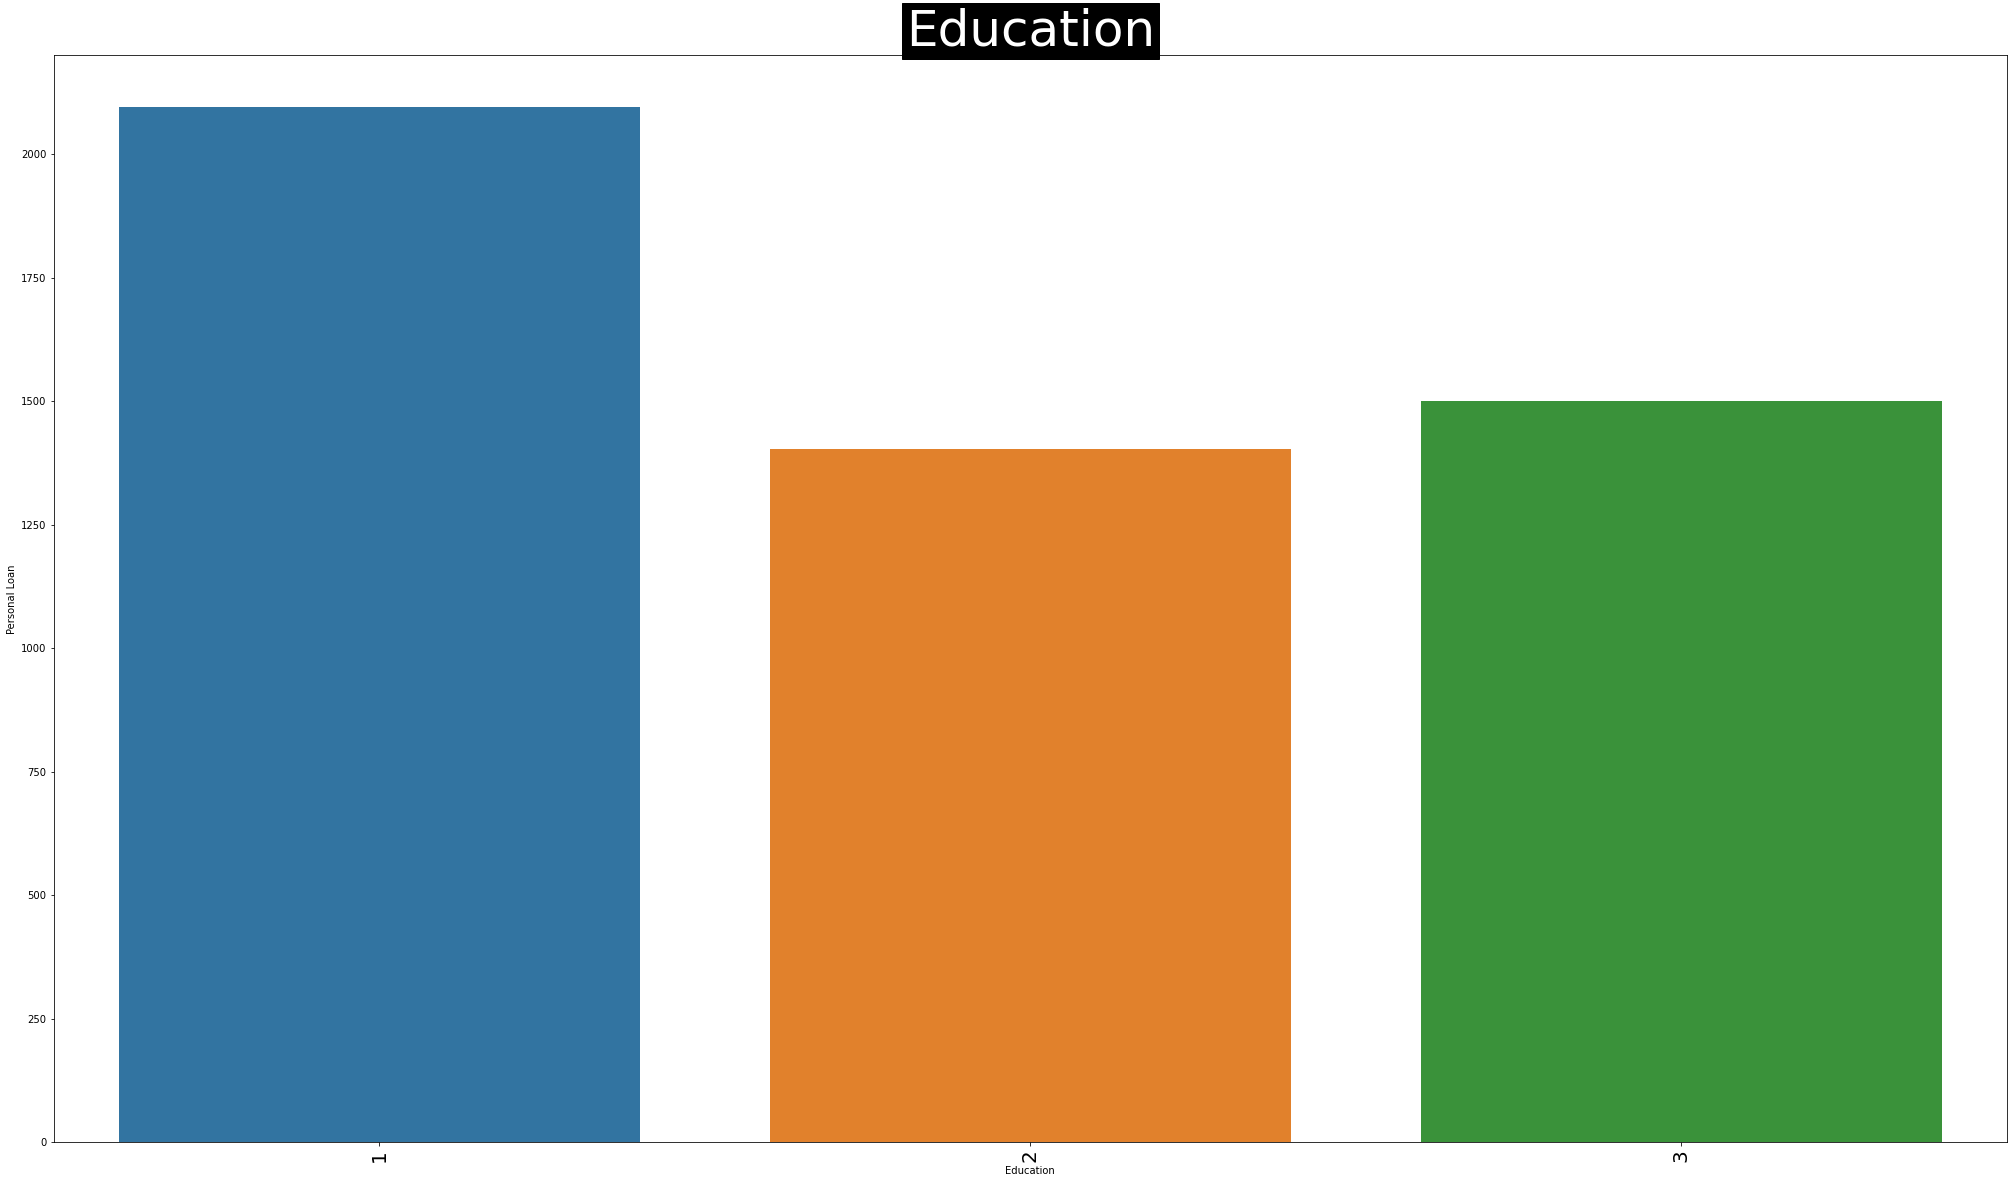

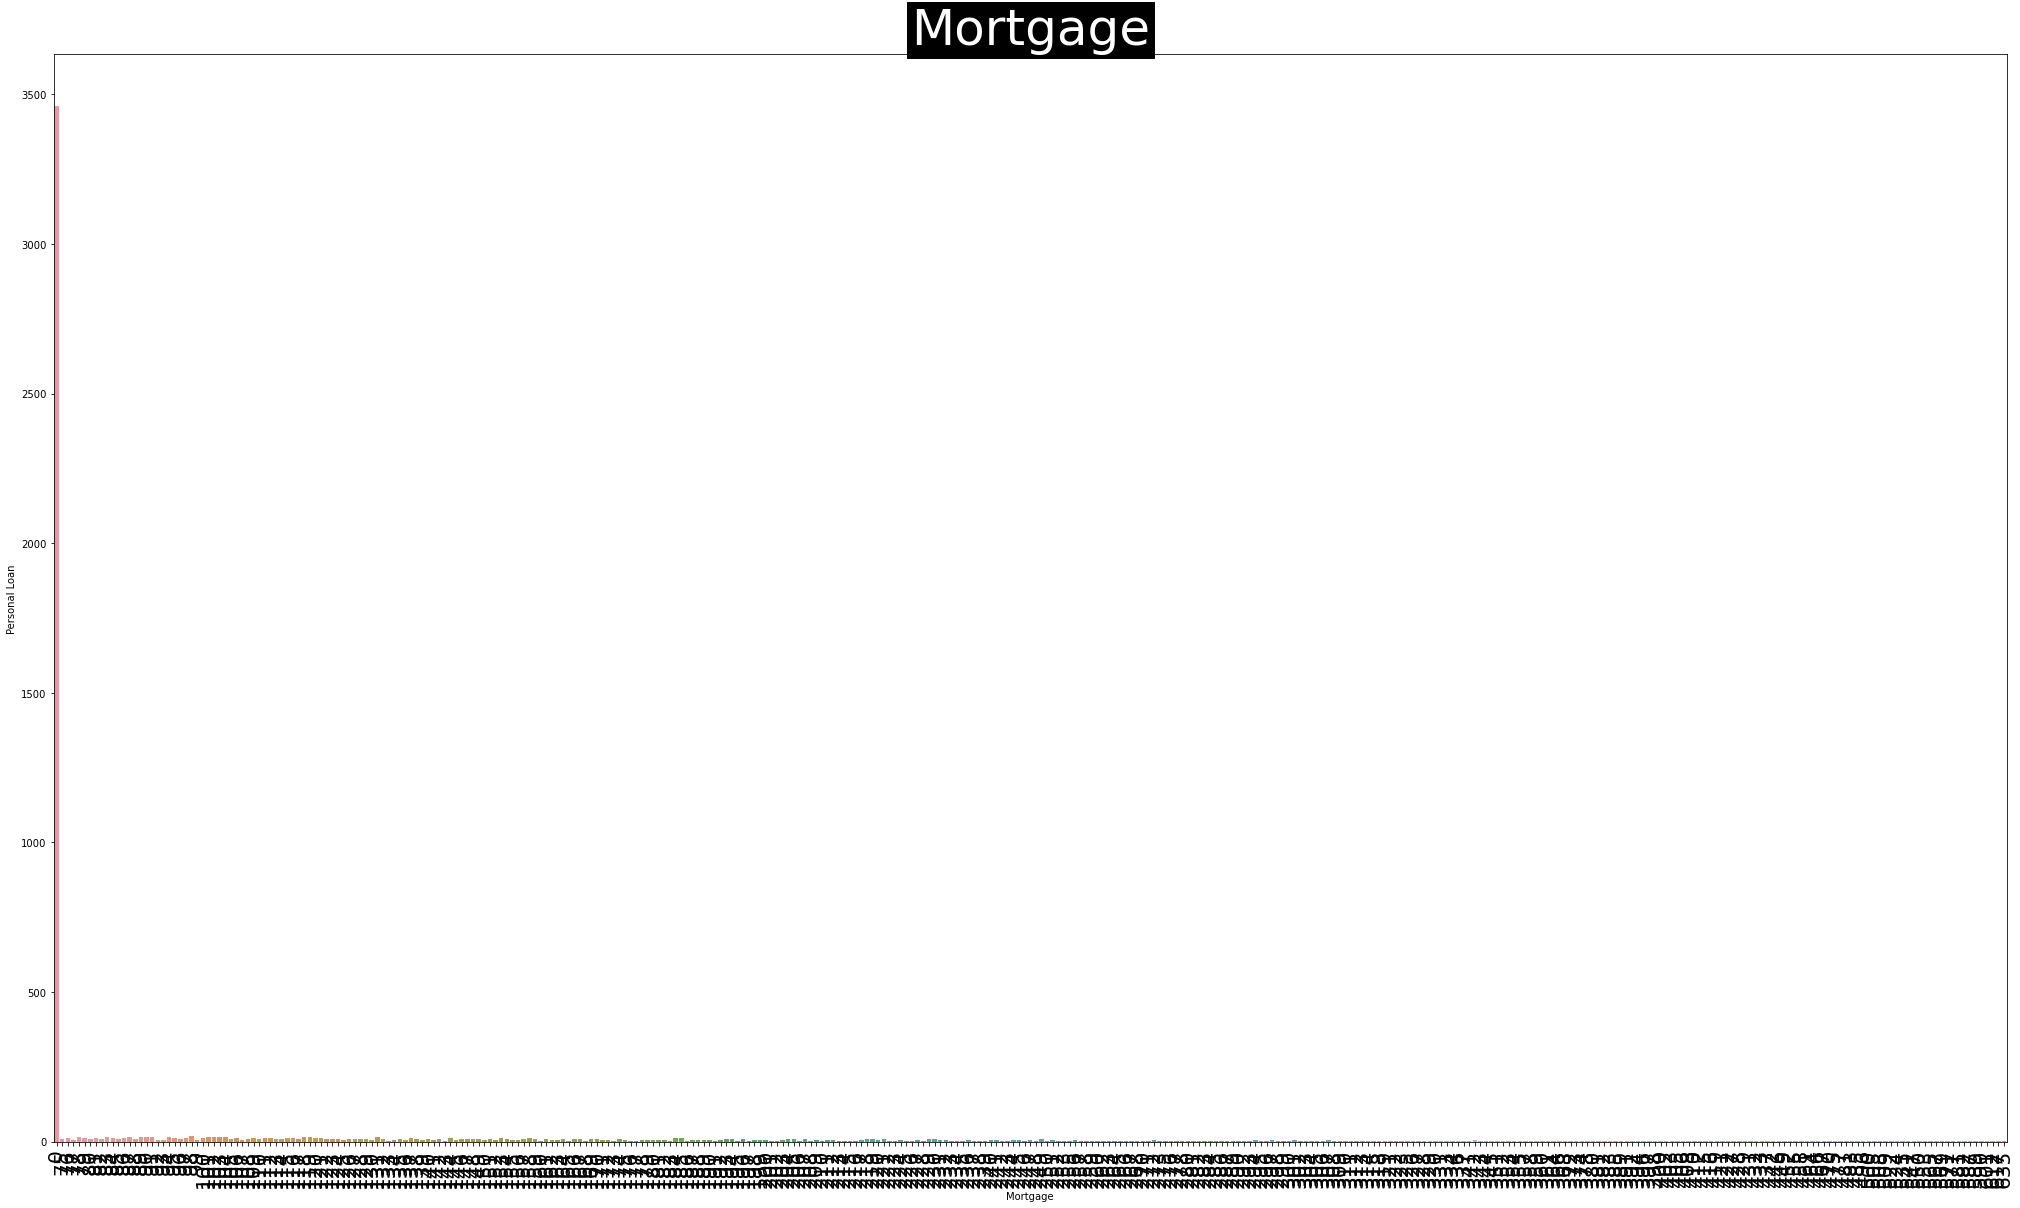

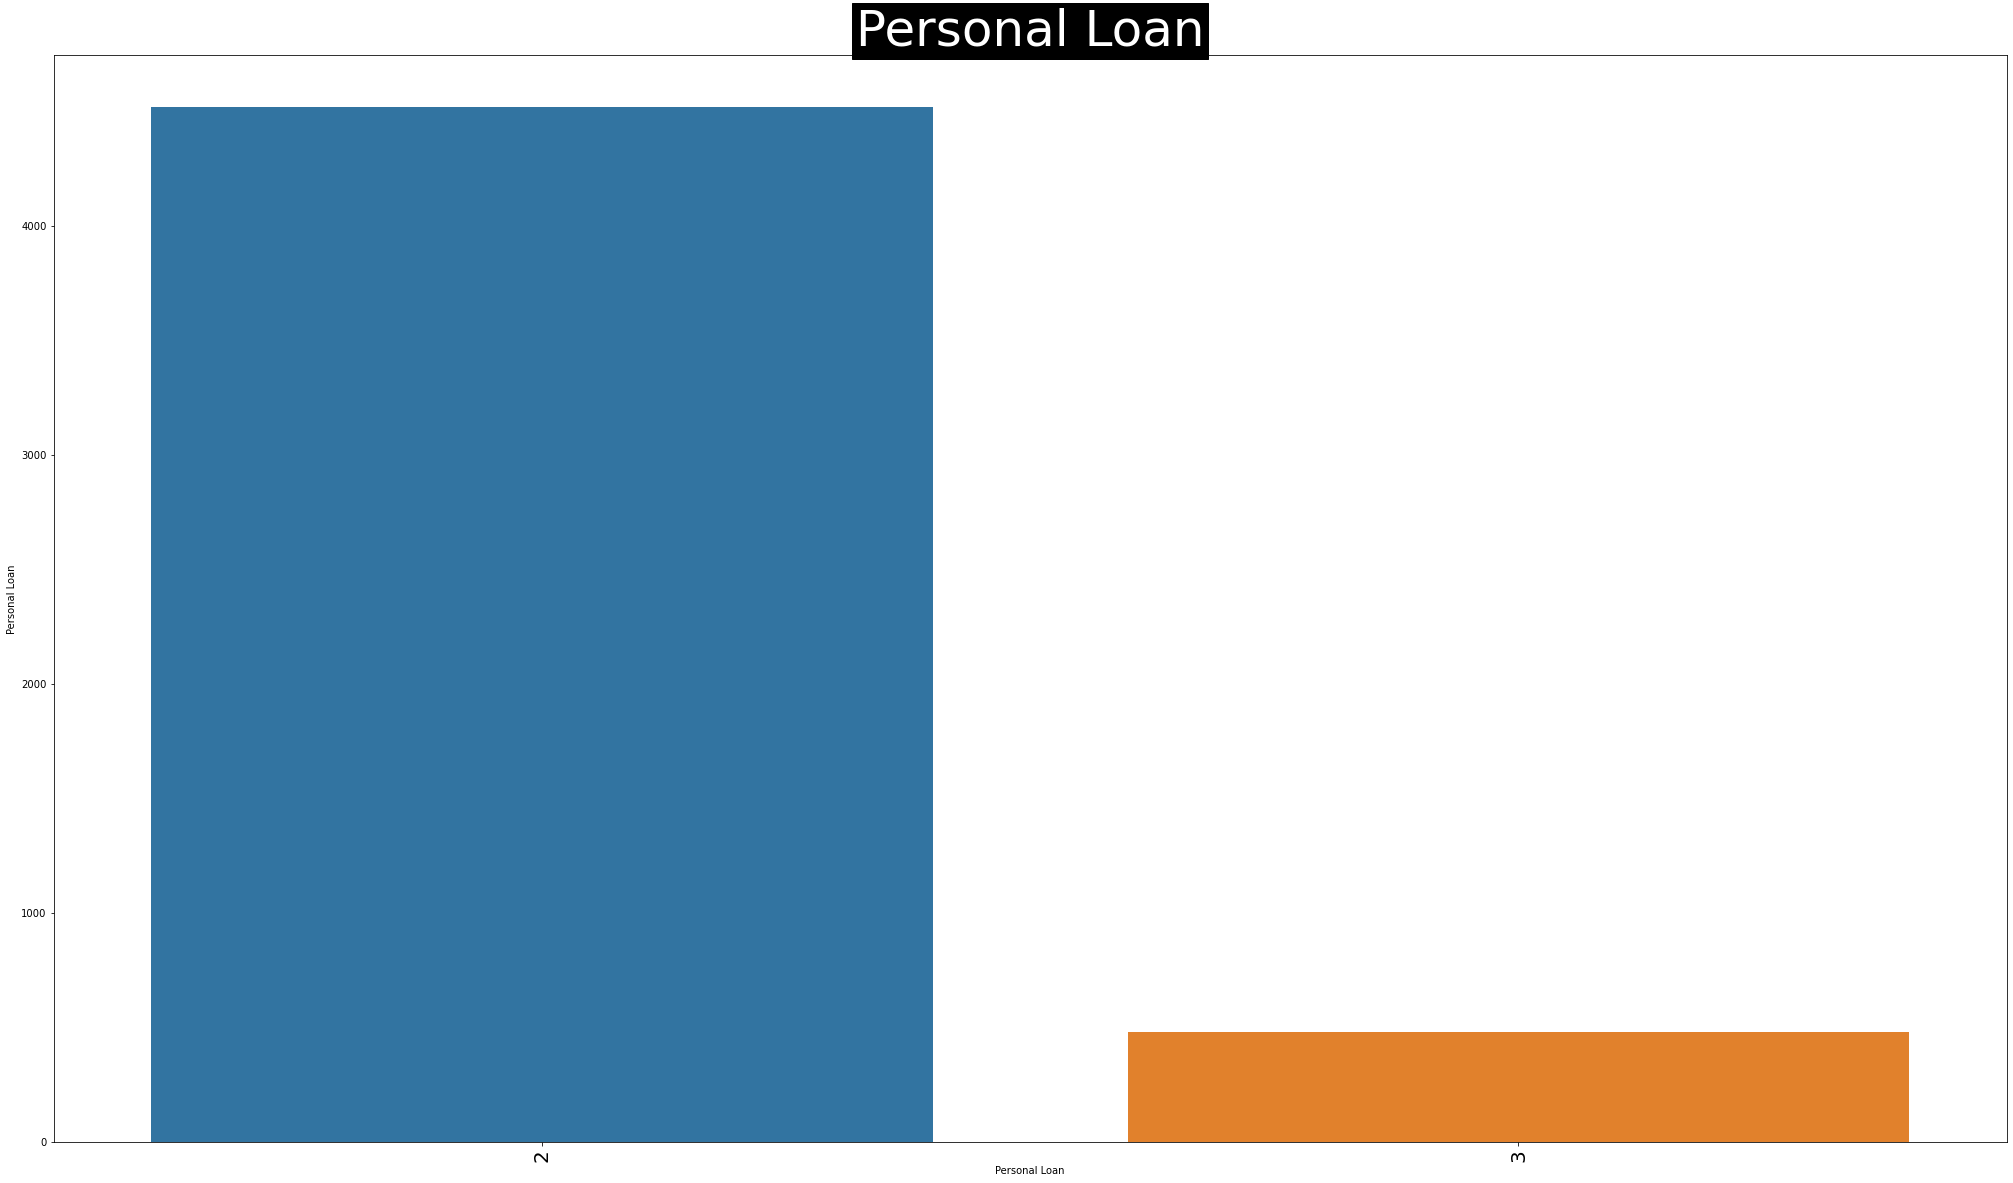

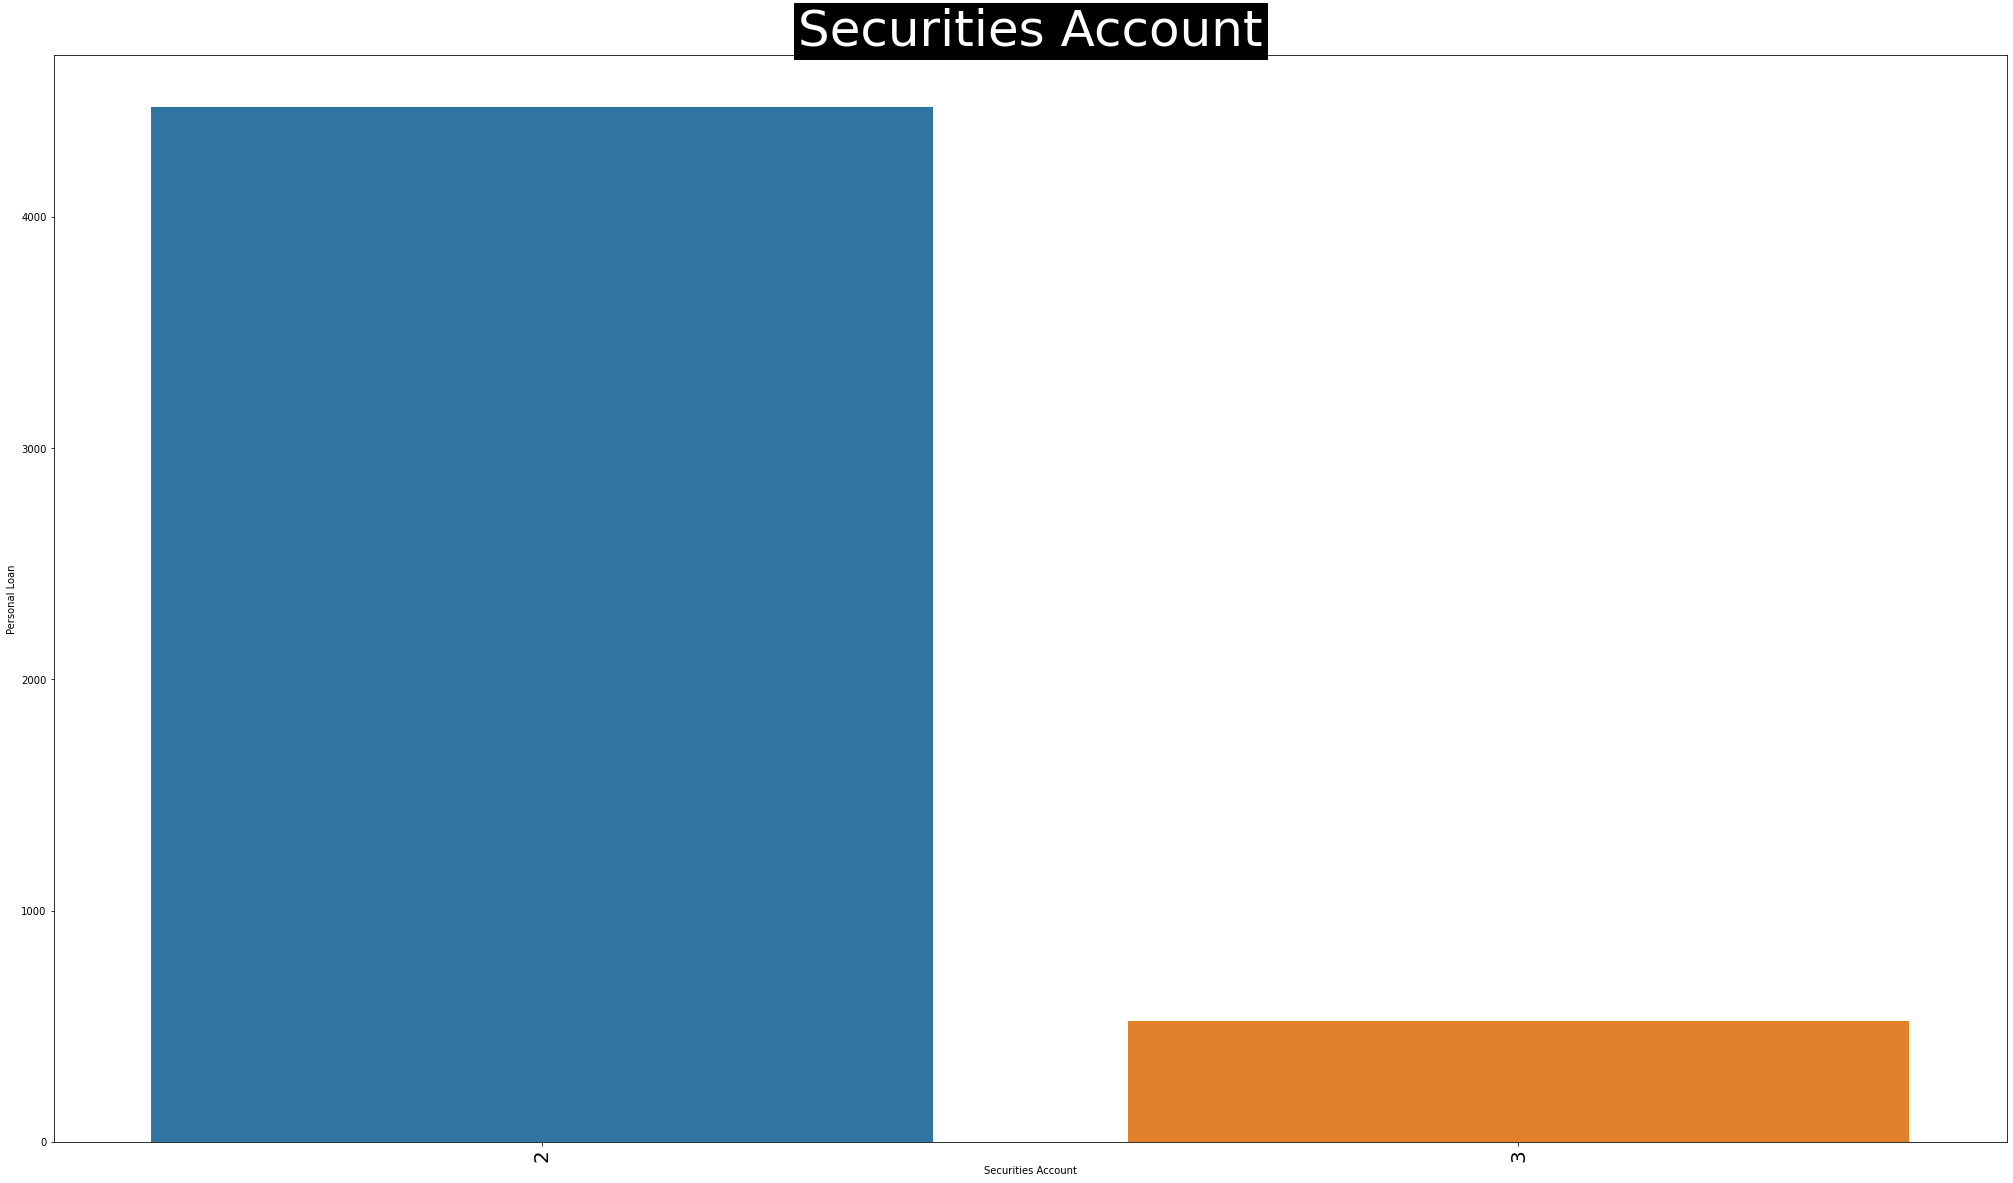

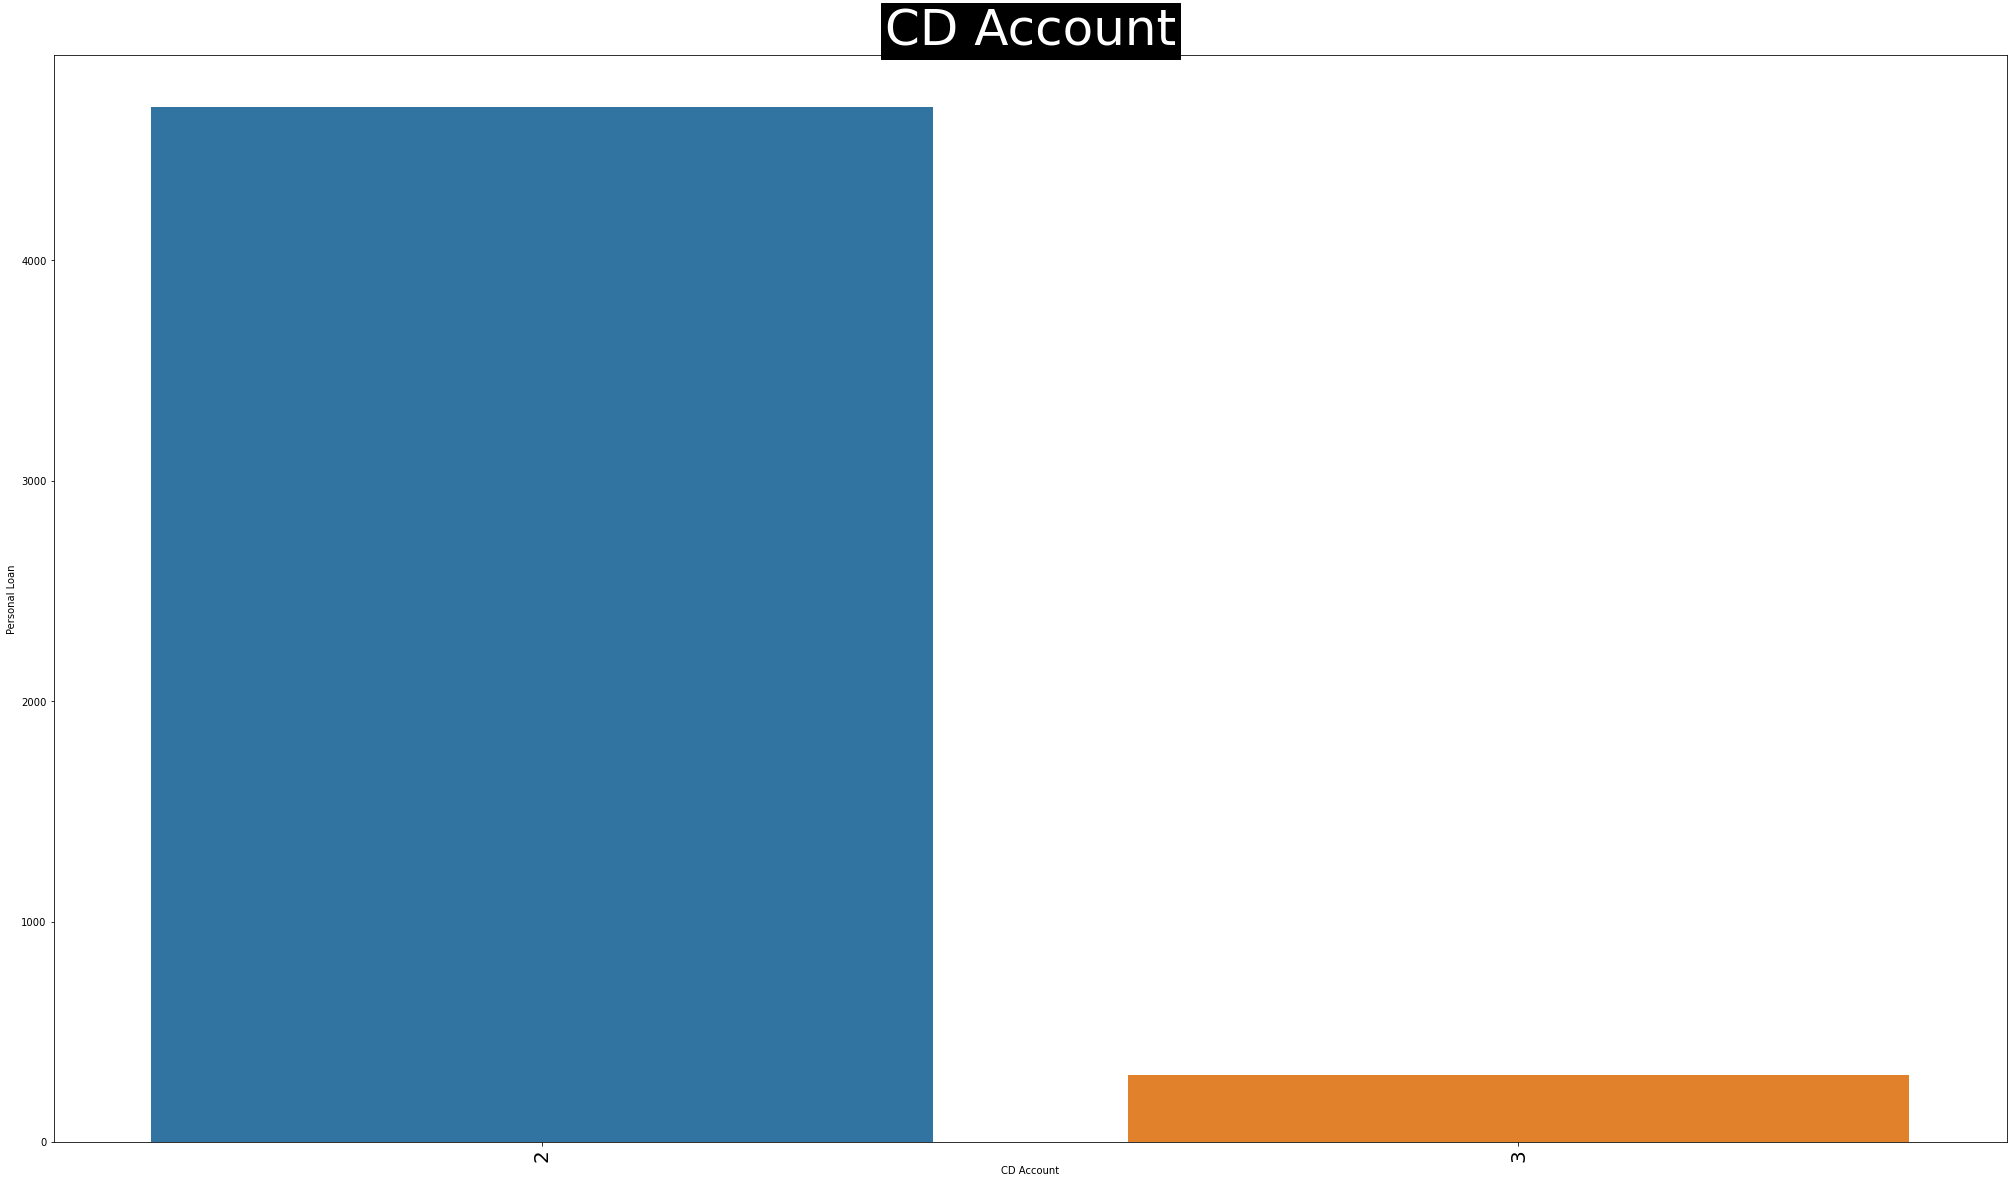

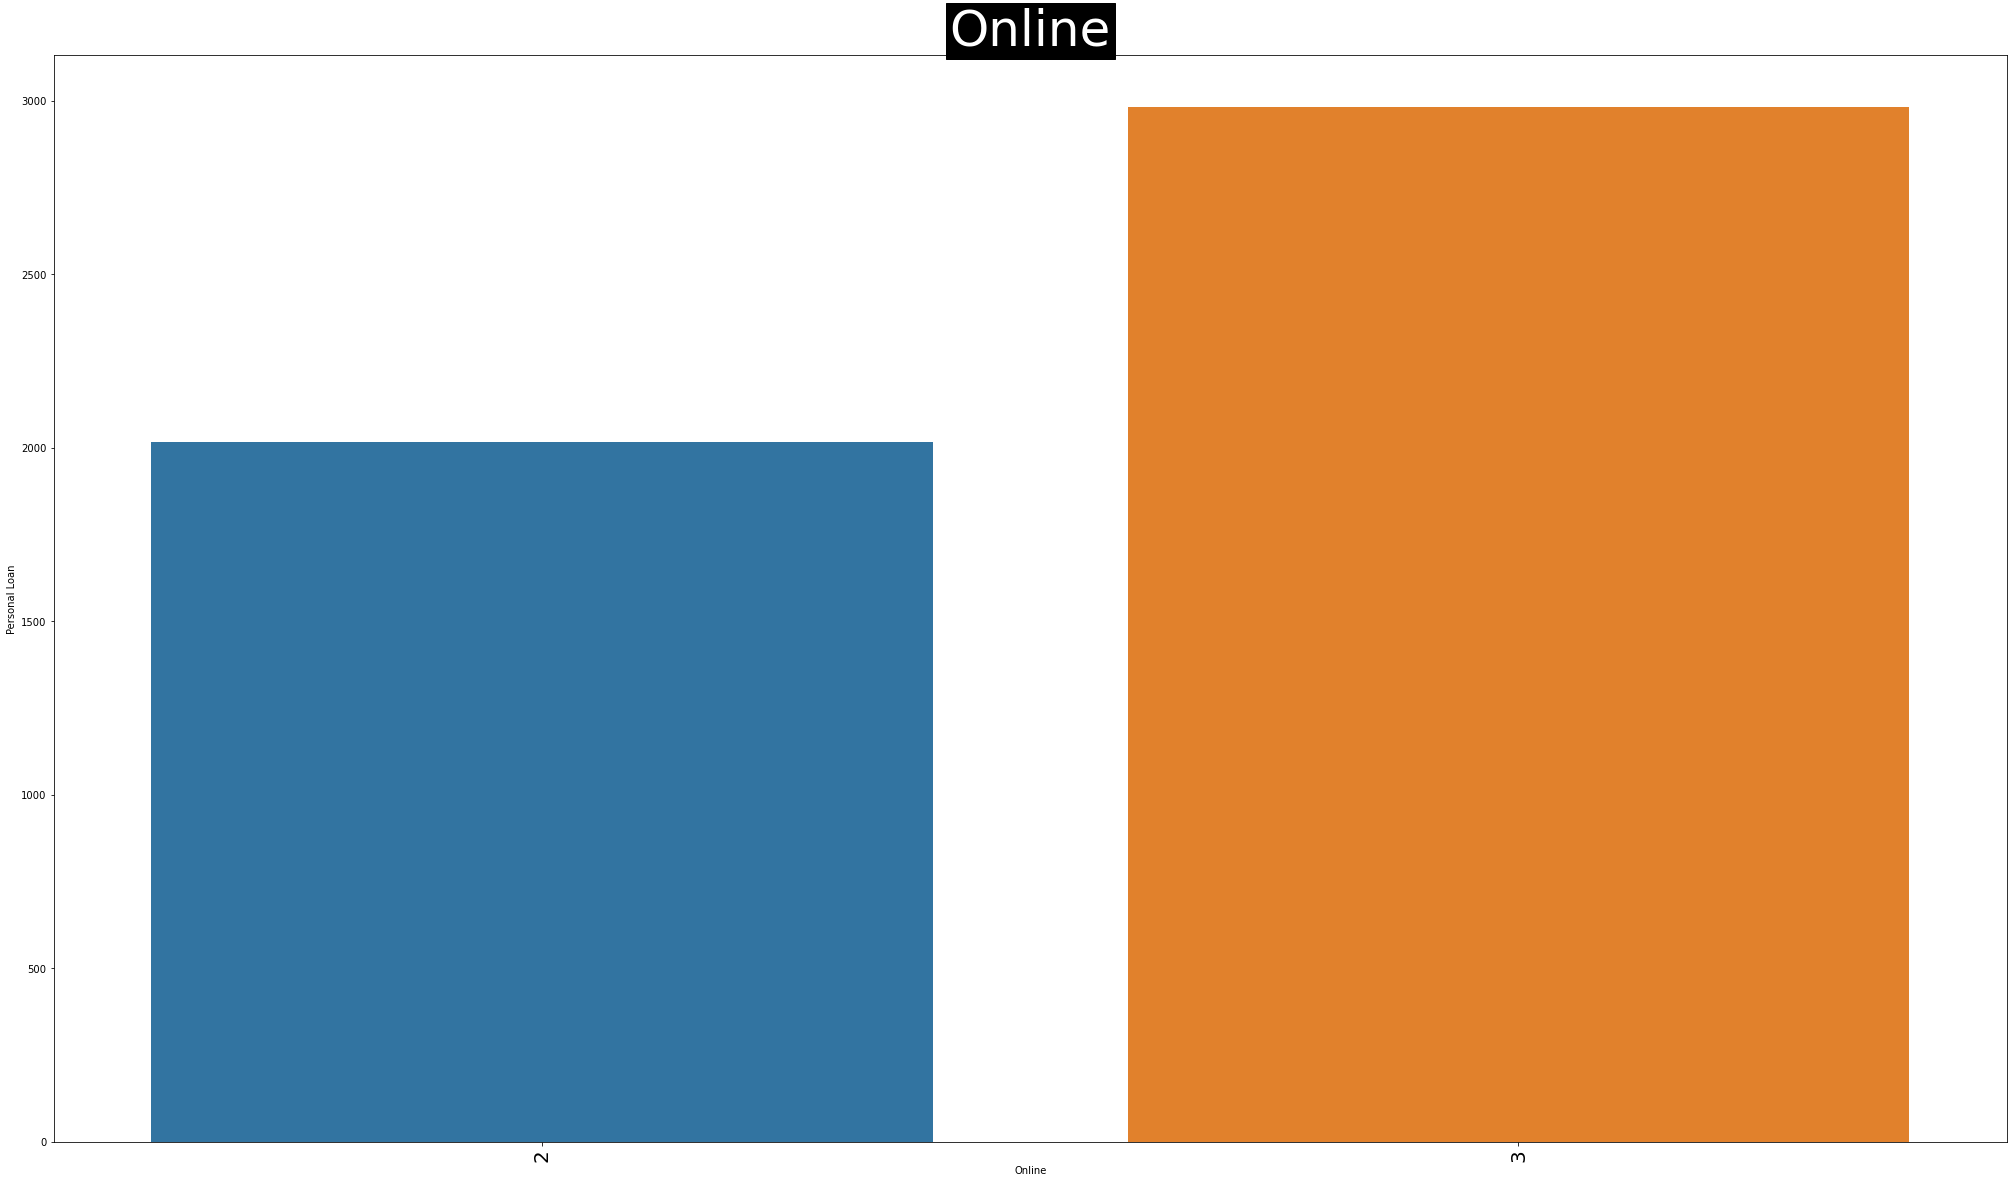

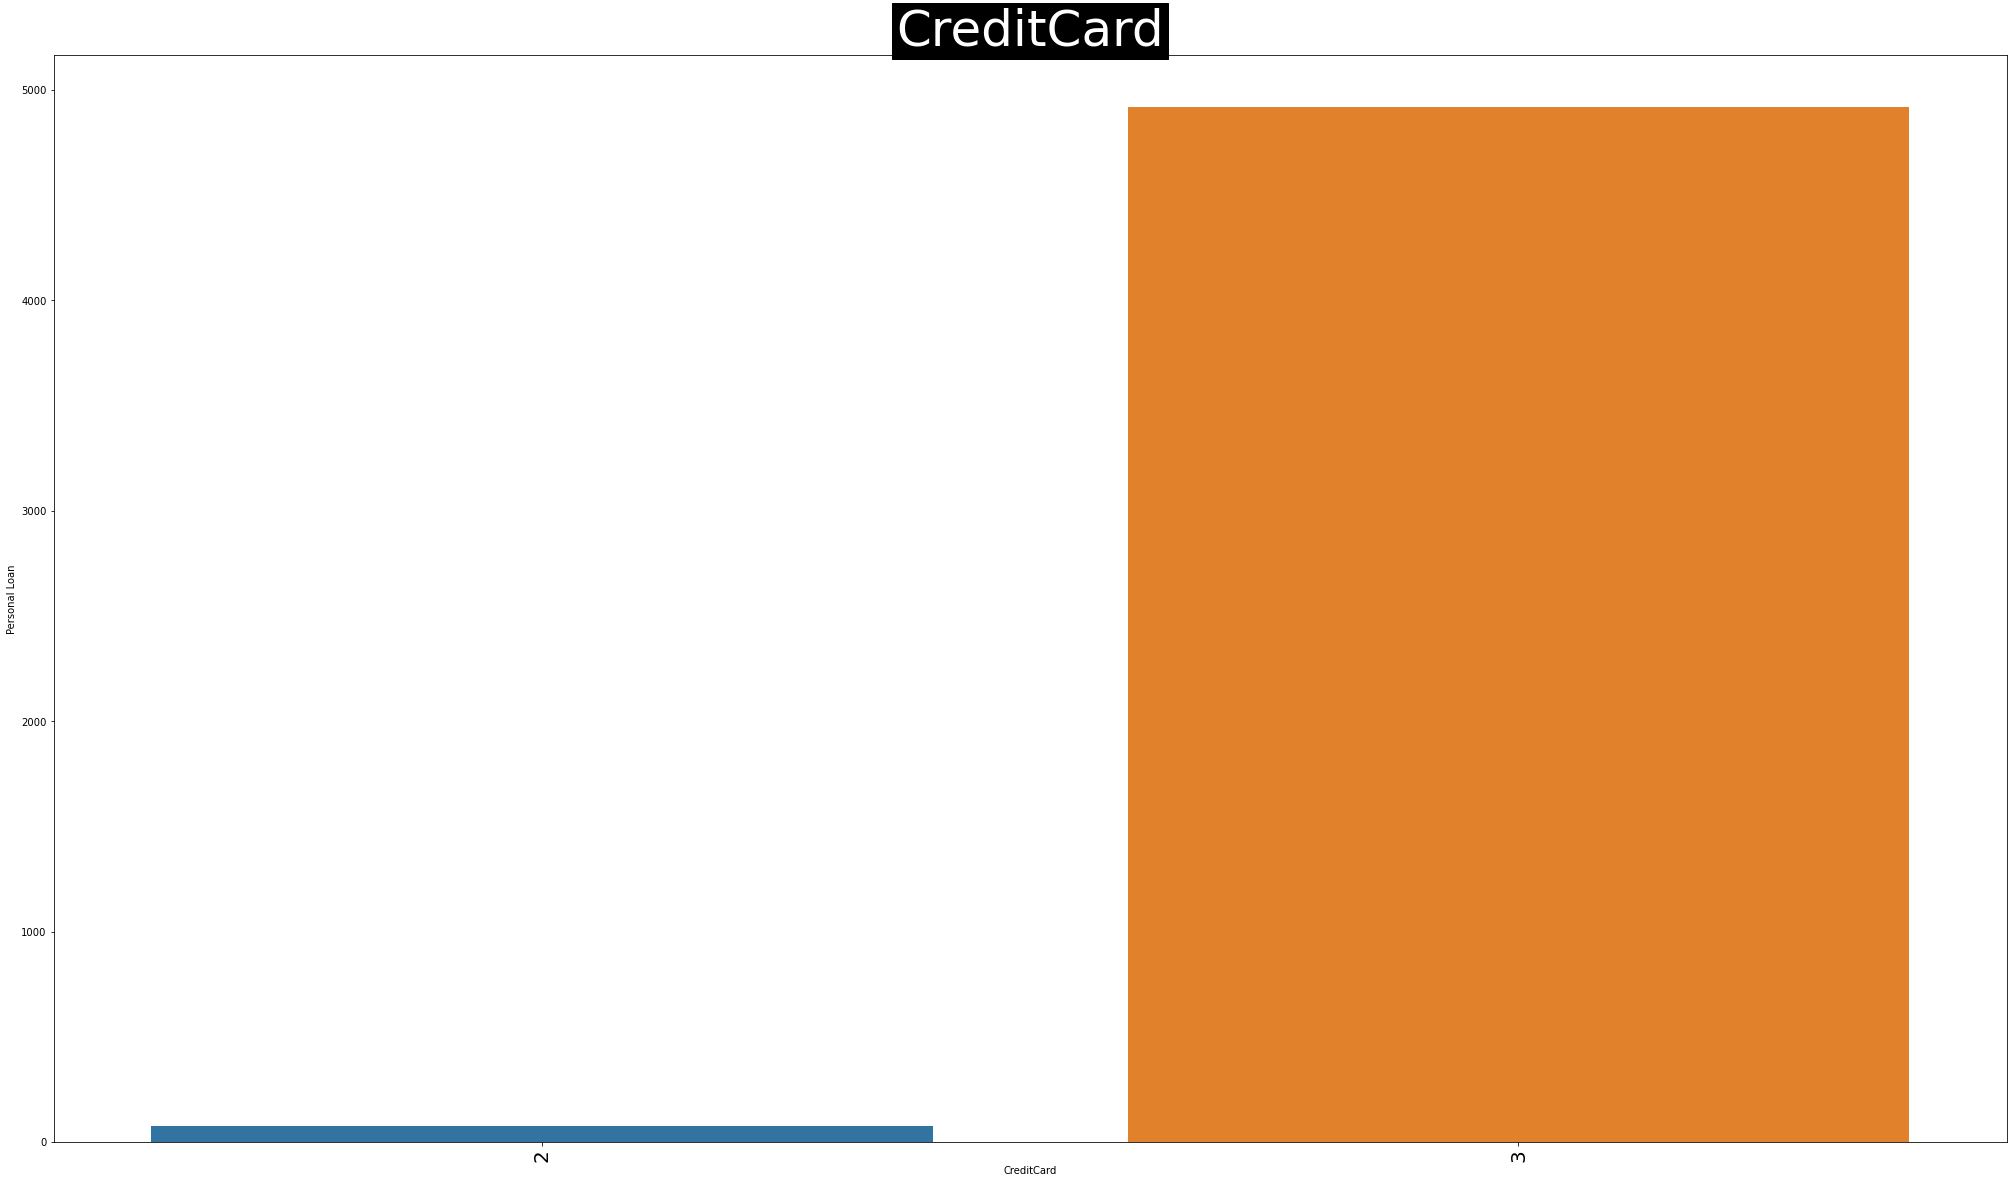

In [54]:
for column in card.columns.drop('ZIP Code'):     
    plt.figure(figsize=(35,20))
    ax=sns.countplot(x=column,data = card)
    plt.xticks(rotation=90,fontsize=20)
    plt.ylabel('Personal Loan')
    plt.xlabel(column)
    plt.title(column,fontsize=50,backgroundcolor='black',color='white')
    #plt.savefig(column+ ' & Personal Loan.jpg')
    plt.show()

In [55]:
card.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4999 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 4999 non-null   int64  
 1   Experience          4999 non-null   int64  
 2   Income              4999 non-null   int64  
 3   ZIP Code            4999 non-null   int64  
 4   Family              4999 non-null   int64  
 5   CCAvg               4999 non-null   float64
 6   Education           4999 non-null   int64  
 7   Mortgage            4999 non-null   int64  
 8   Personal Loan       4999 non-null   int64  
 9   Securities Account  4999 non-null   int64  
 10  CD Account          4999 non-null   int64  
 11  Online              4999 non-null   int64  
 12  CreditCard          4999 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 675.8 KB


DataFrame ready to model

In [56]:
df=card

In [57]:
df

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,3
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,3
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,3
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,3
5,37,13,29,92121,4,0.4,2,155,2,2,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4984,27,1,98,94043,4,2.3,3,0,2,2,2,2,3
4988,34,8,85,95134,1,2.5,1,136,2,2,2,2,3
4990,55,25,58,95023,4,2.0,3,219,2,2,2,2,3
4991,51,25,92,91330,1,1.9,2,100,2,2,2,2,3


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4999 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 4999 non-null   int64  
 1   Experience          4999 non-null   int64  
 2   Income              4999 non-null   int64  
 3   ZIP Code            4999 non-null   int64  
 4   Family              4999 non-null   int64  
 5   CCAvg               4999 non-null   float64
 6   Education           4999 non-null   int64  
 7   Mortgage            4999 non-null   int64  
 8   Personal Loan       4999 non-null   int64  
 9   Securities Account  4999 non-null   int64  
 10  CD Account          4999 non-null   int64  
 11  Online              4999 non-null   int64  
 12  CreditCard          4999 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 675.8 KB


In [59]:
corr=df.corr()['Personal Loan'].sort_values(ascending=False)
corr

Personal Loan         1.000000
Income                0.502459
CCAvg                 0.366864
CD Account            0.316344
Mortgage              0.142065
Education             0.136834
Family                0.061471
CreditCard            0.035553
Securities Account    0.021932
Online                0.006332
ZIP Code             -0.002977
Age                  -0.007694
Experience           -0.008276
Name: Personal Loan, dtype: float64

>>>>>>>>>>  logesticregresion is start

In [60]:
x=card.drop(columns=['Personal Loan'],axis=1)
y=card['Personal Loan'].values.reshape(-1,1)


In [61]:
x

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,3,2,2,3
1,45,19,34,90089,3,1.5,1,0,3,2,2,3
2,39,15,11,94720,1,1.0,1,0,2,2,2,3
3,35,9,100,94112,1,2.7,2,0,2,2,2,3
5,37,13,29,92121,4,0.4,2,155,2,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...
4984,27,1,98,94043,4,2.3,3,0,2,2,2,3
4988,34,8,85,95134,1,2.5,1,136,2,2,2,3
4990,55,25,58,95023,4,2.0,3,219,2,2,2,3
4991,51,25,92,91330,1,1.9,2,100,2,2,2,3


In [62]:
y

array([[2],
       [2],
       [2],
       ...,
       [2],
       [2],
       [2]], dtype=int64)

In [63]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=0)
logreg = LogisticRegression(solver='liblinear')
logreg.fit(x_train,y_train)
y_perd = logreg.predict(x_test)
score = metrics.accuracy_score(y_test,y_perd)
print(score)

0.898


In [64]:
logregcross = LogisticRegression()
Kfold_val = KFold(20)
result = cross_val_score(logregcross,x,y,cv=Kfold_val)
print(result)
print('------------------------')
print(np.mean(result))

[0.892      0.916      0.908      0.892      0.916      0.936
 0.924      0.924      0.932      0.876      0.912      0.888
 0.912      0.936      0.94       0.888      0.904      0.896
 0.904      0.92369478]
------------------------
0.9109847389558233


In [65]:
Acc = {}
num = []
score0=0
for i in range(1,100,1):
    I = i/100    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=I,random_state=0)
    logreg = LogisticRegression(solver='lbfgs')
    logreg.fit(x_train,y_train)
    y_pred = logreg.predict(x_test)
    result1 = metrics.accuracy_score(y_test,y_pred)
    Acc.update({i:result1})
    num.append(i)
print(Acc)
print(num)
print('---------------------------------------------------------------------------')

max(Acc, key=Acc.get)
print('---------------------------------------------------------------------------')
print(classification_report(y,logreg.predict(x)))
print('---------------------------------------------------------------------------')
confusion_matrix(y,logreg.predict(x))

{1: 0.92, 2: 0.9, 3: 0.8866666666666667, 4: 0.885, 5: 0.9, 6: 0.9033333333333333, 7: 0.9028571428571428, 8: 0.9375, 9: 0.9066666666666666, 10: 0.904, 11: 0.9054545454545454, 12: 0.9066666666666666, 13: 0.9061538461538462, 14: 0.9042857142857142, 15: 0.904, 16: 0.9, 17: 0.9329411764705883, 18: 0.9044444444444445, 19: 0.8978947368421053, 20: 0.937, 21: 0.9, 22: 0.8981818181818182, 23: 0.8973913043478261, 24: 0.8941666666666667, 25: 0.896, 26: 0.9323076923076923, 27: 0.8955555555555555, 28: 0.8942857142857142, 29: 0.9324137931034483, 30: 0.8986666666666666, 31: 0.9335483870967742, 32: 0.934375, 33: 0.8963636363636364, 34: 0.9341176470588235, 35: 0.8994285714285715, 36: 0.9011111111111111, 37: 0.9345945945945946, 38: 0.9010526315789473, 39: 0.9015384615384615, 40: 0.902, 41: 0.9009756097560976, 42: 0.9014285714285715, 43: 0.9013953488372093, 44: 0.9009090909090909, 45: 0.9248888888888889, 46: 0.9382608695652174, 47: 0.9259574468085107, 48: 0.9366666666666666, 49: 0.9008163265306123, 50: 0.

array([[4236,  283],
       [ 172,  308]], dtype=int64)

In [66]:
Acc = {}
num = []
score0=0
for i in range(1,100,1):
    I = i/100    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=I,random_state=0)
    logreg = LogisticRegression(solver='saga')
    logreg.fit(x_train,y_train)
    y_pred = logreg.predict(x_test)
    result1 = metrics.accuracy_score(y_test,y_pred)
    Acc.update({i:result1})
    num.append(i)
print(Acc)
print(num)
print('---------------------------------------------------------------------------')

max(Acc, key=Acc.get)
print('---------------------------------------------------------------------------')
print(classification_report(y,logreg.predict(x)))
print('---------------------------------------------------------------------------')
confusion_matrix(y,logreg.predict(x))

{1: 0.9, 2: 0.86, 3: 0.88, 4: 0.88, 5: 0.892, 6: 0.8966666666666666, 7: 0.9028571428571428, 8: 0.9025, 9: 0.9088888888888889, 10: 0.908, 11: 0.9109090909090909, 12: 0.9066666666666666, 13: 0.9015384615384615, 14: 0.9028571428571428, 15: 0.8986666666666666, 16: 0.90125, 17: 0.9035294117647059, 18: 0.9033333333333333, 19: 0.8989473684210526, 20: 0.9, 21: 0.900952380952381, 22: 0.9, 23: 0.8991304347826087, 24: 0.8966666666666666, 25: 0.8976, 26: 0.8961538461538462, 27: 0.8955555555555555, 28: 0.895, 29: 0.8972413793103449, 30: 0.8986666666666666, 31: 0.896774193548387, 32: 0.895, 33: 0.8951515151515151, 34: 0.8952941176470588, 35: 0.8948571428571429, 36: 0.8966666666666666, 37: 0.8972972972972973, 38: 0.8957894736842106, 39: 0.8958974358974359, 40: 0.897, 41: 0.8975609756097561, 42: 0.8985714285714286, 43: 0.8986046511627906, 44: 0.8981818181818182, 45: 0.896, 46: 0.8965217391304348, 47: 0.8978723404255319, 48: 0.8970833333333333, 49: 0.8991836734693878, 50: 0.8992, 51: 0.8984313725490196

array([[4519,    0],
       [ 480,    0]], dtype=int64)

In [67]:
Acc = {}
num = []
score0=0
for i in range(1,100,1):
    I = i/100    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=I,random_state=0)
    logreg = LogisticRegression(solver='sag')
    logreg.fit(x_train,y_train)
    y_pred = logreg.predict(x_test)
    result1 = metrics.accuracy_score(y_test,y_pred)
    Acc.update({i:result1})
    num.append(i)
print(Acc)
print(num)
print('---------------------------------------------------------------------------')

max(Acc, key=Acc.get)
print('---------------------------------------------------------------------------')
print(classification_report(y,logreg.predict(x)))
print('---------------------------------------------------------------------------')
confusion_matrix(y,logreg.predict(x))

{1: 0.9, 2: 0.86, 3: 0.88, 4: 0.88, 5: 0.892, 6: 0.8966666666666666, 7: 0.9028571428571428, 8: 0.9025, 9: 0.9088888888888889, 10: 0.908, 11: 0.9109090909090909, 12: 0.9066666666666666, 13: 0.9015384615384615, 14: 0.9028571428571428, 15: 0.8986666666666666, 16: 0.90125, 17: 0.9035294117647059, 18: 0.9033333333333333, 19: 0.8989473684210526, 20: 0.9, 21: 0.900952380952381, 22: 0.9, 23: 0.8991304347826087, 24: 0.8966666666666666, 25: 0.8976, 26: 0.8961538461538462, 27: 0.8955555555555555, 28: 0.895, 29: 0.8972413793103449, 30: 0.8986666666666666, 31: 0.896774193548387, 32: 0.895, 33: 0.8951515151515151, 34: 0.8952941176470588, 35: 0.8948571428571429, 36: 0.8966666666666666, 37: 0.8972972972972973, 38: 0.8957894736842106, 39: 0.8958974358974359, 40: 0.897, 41: 0.8975609756097561, 42: 0.8985714285714286, 43: 0.8986046511627906, 44: 0.8981818181818182, 45: 0.896, 46: 0.8965217391304348, 47: 0.8978723404255319, 48: 0.8970833333333333, 49: 0.8991836734693878, 50: 0.8992, 51: 0.8984313725490196

array([[4519,    0],
       [ 480,    0]], dtype=int64)

In [68]:
Acc = {}
num = []
score0=0
for i in range(1,100,1):
    I = i/100    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=I,random_state=0)
    logreg = LogisticRegression(solver='liblinear')
    logreg.fit(x_train,y_train)
    y_pred = logreg.predict(x_test)
    result1 = metrics.accuracy_score(y_test,y_pred)
    Acc.update({i:result1})
    num.append(i)
print(Acc)
print(num)
print('---------------------------------------------------------------------------')

max(Acc, key=Acc.get)
print('---------------------------------------------------------------------------')
print(classification_report(y,logreg.predict(x)))
print('---------------------------------------------------------------------------')
confusion_matrix(y,logreg.predict(x))

{1: 0.92, 2: 0.9, 3: 0.8866666666666667, 4: 0.885, 5: 0.9, 6: 0.9, 7: 0.9, 8: 0.8975, 9: 0.9044444444444445, 10: 0.898, 11: 0.9, 12: 0.9016666666666666, 13: 0.9046153846153846, 14: 0.9057142857142857, 15: 0.9013333333333333, 16: 0.90375, 17: 0.9035294117647059, 18: 0.9055555555555556, 19: 0.8978947368421053, 20: 0.904, 21: 0.8990476190476191, 22: 0.8981818181818182, 23: 0.8982608695652174, 24: 0.8941666666666667, 25: 0.896, 26: 0.8953846153846153, 27: 0.8955555555555555, 28: 0.895, 29: 0.8979310344827586, 30: 0.898, 31: 0.8987096774193548, 32: 0.898125, 33: 0.896969696969697, 34: 0.8976470588235295, 35: 0.9, 36: 0.9016666666666666, 37: 0.9021621621621622, 38: 0.901578947368421, 39: 0.9005128205128206, 40: 0.9015, 41: 0.9, 42: 0.9019047619047619, 43: 0.9009302325581395, 44: 0.9027272727272727, 45: 0.9004444444444445, 46: 0.9017391304347826, 47: 0.9025531914893618, 48: 0.9025, 49: 0.9036734693877551, 50: 0.9016, 51: 0.9003921568627451, 52: 0.9003846153846153, 53: 0.900377358490566, 54: 0

array([[4158,  361],
       [ 187,  293]], dtype=int64)

LogisticRegression >>>>>>   solver = lbfgs     &    test size = 34

In [69]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.34,random_state=0)
logreg = LogisticRegression()
logreg.fit(x_train,y_train)
y_perd = logreg.predict(x_test)
score = metrics.accuracy_score(y_test,y_perd)
print(score)

0.9341176470588235


In [70]:
print(classification_report(y,logreg.predict(x)))

              precision    recall  f1-score   support

           2       0.95      0.98      0.97      4519
           3       0.77      0.56      0.65       480

    accuracy                           0.94      4999
   macro avg       0.86      0.77      0.81      4999
weighted avg       0.94      0.94      0.94      4999



In [71]:
confusion_matrix(y,logreg.predict(x))

array([[4441,   78],
       [ 213,  267]], dtype=int64)

In [72]:
def check(Dimension,testsize):
    r2 = 0.9341176470588235
    newcard=card
    for column in newcard:
        new_col_name = column +str(Dimension)
        new_col_val = newcard[column]**Dimension
        newcard.insert(0,new_col_name,new_col_val)
        x3_train,x3_test,y3_train,y3_test = train_test_split(x,y,test_size=testsize,random_state=0)
        logreg1 = LogisticRegression() 
        logreg1.fit(x3_train,y3_train.ravel())
        y3_pred = logreg1.predict(x3_test)
        r2_new = metrics.accuracy_score(y3_test,y3_pred)
        if r2_new<=r2:
            newcard.drop([new_col_name],axis=1,inplace=True)
        else:
            r2 = r2_new
    print('r2 score : ',r2)
    
check(2,0.34)

r2 score :  0.9341176470588235


In [73]:
card

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,3
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,3
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,3
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,3
5,37,13,29,92121,4,0.4,2,155,2,2,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4984,27,1,98,94043,4,2.3,3,0,2,2,2,2,3
4988,34,8,85,95134,1,2.5,1,136,2,2,2,2,3
4990,55,25,58,95023,4,2.0,3,219,2,2,2,2,3
4991,51,25,92,91330,1,1.9,2,100,2,2,2,2,3


effecte of feacher income   

In [74]:
def check(Dimension):
    r2 = 0.9341176470588235
    newcard=card
    for column in newcard:
        new_col_name = column +str(Dimension)
        new_col_val = newcard[column]**newcard.Income
        newcard.insert(0,new_col_name,new_col_val)
        x3_train,x3_test,y3_train,y3_test = train_test_split(x,y,test_size=0.34,random_state=0)
        logreg1 = LogisticRegression() 
        logreg1.fit(x3_train,y3_train.ravel())
        y3_pred = logreg1.predict(x3_test)
        r2_new = metrics.accuracy_score(y3_test,y3_pred)
        if r2_new<=r2:
            newcard.drop([new_col_name],axis=1,inplace=True)
        else:
            r2 = r2_new
    print('r2 score : ',r2)
    
check(2)

r2 score :  0.9341176470588235


In [75]:
card

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,3
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,3
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,3
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,3
5,37,13,29,92121,4,0.4,2,155,2,2,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4984,27,1,98,94043,4,2.3,3,0,2,2,2,2,3
4988,34,8,85,95134,1,2.5,1,136,2,2,2,2,3
4990,55,25,58,95023,4,2.0,3,219,2,2,2,2,3
4991,51,25,92,91330,1,1.9,2,100,2,2,2,2,3


no effect

result ====          logesticregresion 
#>>>>>>>>>>>>>>>>>>          solver = defult
#>>>>>>>>>>>>>>>>>>          test size = 0.34

In [76]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.34,random_state=0)
logreg = LogisticRegression(solver='lbfgs')
logreg.fit(x_train,y_train)
y_perd = logreg.predict(x_test)
score = metrics.accuracy_score(y_test,y_perd)
print(score)

0.9341176470588235


In [77]:
print(classification_report(y,logreg.predict(x)))

              precision    recall  f1-score   support

           2       0.95      0.98      0.97      4519
           3       0.77      0.56      0.65       480

    accuracy                           0.94      4999
   macro avg       0.86      0.77      0.81      4999
weighted avg       0.94      0.94      0.94      4999



In [78]:
confusion_matrix(y,logreg.predict(x))

array([[4441,   78],
       [ 213,  267]], dtype=int64)

>>>>>>>>>>  logesticregresion is finish

>>>>>>>> naive bayes   complement  &  multinomian 

In [79]:
df

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,3
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,3
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,3
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,3
5,37,13,29,92121,4,0.4,2,155,2,2,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4984,27,1,98,94043,4,2.3,3,0,2,2,2,2,3
4988,34,8,85,95134,1,2.5,1,136,2,2,2,2,3
4990,55,25,58,95023,4,2.0,3,219,2,2,2,2,3
4991,51,25,92,91330,1,1.9,2,100,2,2,2,2,3


In [80]:
x=card.drop(columns=['Personal Loan'],axis=1)
y=card['Personal Loan'].values.reshape(-1,1)

In [81]:
x1_train,x1_test,y1_train,y1_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [82]:
clf1 = MultinomialNB()
clf1.fit(x1_train,y1_train.ravel())
y1_pred = clf1.predict(x1_test)
score = metrics.accuracy_score(y1_test,y1_pred)
print(score)

0.773


In [83]:
clf1 = ComplementNB()
clf1.fit(x1_train,y1_train.ravel())
y1_pred = clf1.predict(x1_test)
score = metrics.accuracy_score(y1_test,y1_pred)
print(score)

0.771


In [84]:
Acc = {}
num = []
score0=0
for i in range(1,100,1):
    I = i/100   
    x1_train,x1_test,y1_train,y1_test = train_test_split(x,y,test_size=I,random_state=0)
    clf1 = ComplementNB()
    clf1.fit(x1_train,y1_train.ravel())
    y1_pred = clf1.predict(x1_test)
    result1 = metrics.accuracy_score(y1_test,y1_pred)
    Acc.update({i:result1})
    num.append(i)
print(Acc)
print(num)
print('---------------------------------------------------------------------------')

max(Acc, key=Acc.get)

{1: 0.84, 2: 0.78, 3: 0.76, 4: 0.775, 5: 0.792, 6: 0.7733333333333333, 7: 0.7771428571428571, 8: 0.775, 9: 0.7666666666666667, 10: 0.766, 11: 0.78, 12: 0.7766666666666666, 13: 0.7676923076923077, 14: 0.7742857142857142, 15: 0.776, 16: 0.77625, 17: 0.7752941176470588, 18: 0.7722222222222223, 19: 0.7694736842105263, 20: 0.771, 21: 0.7714285714285715, 22: 0.7663636363636364, 23: 0.7643478260869565, 24: 0.7683333333333333, 25: 0.7696, 26: 0.7669230769230769, 27: 0.7674074074074074, 28: 0.7664285714285715, 29: 0.766896551724138, 30: 0.7686666666666667, 31: 0.7690322580645161, 32: 0.76875, 33: 0.7703030303030303, 34: 0.77, 35: 0.7702857142857142, 36: 0.7705555555555555, 37: 0.7713513513513514, 38: 0.7721052631578947, 39: 0.7733333333333333, 40: 0.774, 41: 0.7721951219512195, 42: 0.7723809523809524, 43: 0.7706976744186047, 44: 0.7695454545454545, 45: 0.7706666666666667, 46: 0.7708695652173913, 47: 0.7706382978723404, 48: 0.7654166666666666, 49: 0.7673469387755102, 50: 0.766, 51: 0.76313725490

1

In [85]:
Acc = {}
num = []
score0=0
for i in range(1,100,1):
    I = i/100   
    x1_train,x1_test,y1_train,y1_test = train_test_split(x,y,test_size=I,random_state=0)
    clf1 = MultinomialNB()
    clf1.fit(x1_train,y1_train.ravel())
    y1_pred = clf1.predict(x1_test)
    result1 = metrics.accuracy_score(y1_test,y1_pred)
    Acc.update({i:result1})
    num.append(i)
print(Acc)
print(num)
print('---------------------------------------------------------------------------')

max(Acc, key=Acc.get)

{1: 0.84, 2: 0.78, 3: 0.7733333333333333, 4: 0.785, 5: 0.796, 6: 0.7866666666666666, 7: 0.7857142857142857, 8: 0.785, 9: 0.7733333333333333, 10: 0.774, 11: 0.7854545454545454, 12: 0.7833333333333333, 13: 0.7738461538461539, 14: 0.7785714285714286, 15: 0.7786666666666666, 16: 0.77875, 17: 0.7811764705882352, 18: 0.7744444444444445, 19: 0.7705263157894737, 20: 0.773, 21: 0.7752380952380953, 22: 0.769090909090909, 23: 0.7660869565217391, 24: 0.77, 25: 0.7704, 26: 0.7684615384615384, 27: 0.7696296296296297, 28: 0.7714285714285715, 29: 0.7682758620689655, 30: 0.77, 31: 0.7696774193548387, 32: 0.77, 33: 0.7727272727272727, 34: 0.7723529411764706, 35: 0.7737142857142857, 36: 0.775, 37: 0.7745945945945946, 38: 0.7747368421052632, 39: 0.7758974358974359, 40: 0.7765, 41: 0.7746341463414634, 42: 0.7738095238095238, 43: 0.7716279069767442, 44: 0.774090909090909, 45: 0.7724444444444445, 46: 0.7726086956521739, 47: 0.7714893617021277, 48: 0.7670833333333333, 49: 0.7689795918367347, 50: 0.7672, 51: 0

1

result= the mean of accuracy of naive bays is 70 to 78   

In [86]:
x1_train,x1_test,y1_train,y1_test = train_test_split(x,y,test_size=0.33,random_state=0)
clf1 = ComplementNB()
clf1.fit(x1_train,y1_train.ravel())
y1_pred = clf1.predict(x1_test)
score = metrics.accuracy_score(y1_test,y1_pred)
print(score)

0.7703030303030303


>>>>>>>>niave bys- finish

>>>>>>KNN- start

In [87]:
df

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,2,3,2,2,3
1,45,19,34,90089,3,1.5,1,0,2,3,2,2,3
2,39,15,11,94720,1,1.0,1,0,2,2,2,2,3
3,35,9,100,94112,1,2.7,2,0,2,2,2,2,3
5,37,13,29,92121,4,0.4,2,155,2,2,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4984,27,1,98,94043,4,2.3,3,0,2,2,2,2,3
4988,34,8,85,95134,1,2.5,1,136,2,2,2,2,3
4990,55,25,58,95023,4,2.0,3,219,2,2,2,2,3
4991,51,25,92,91330,1,1.9,2,100,2,2,2,2,3


In [88]:
x=card.drop(columns=['Personal Loan'],axis=1)
y=card['Personal Loan'].values.reshape(-1,1)

In [89]:
x2_train,x2_test,y2_train,y2_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [90]:
K =8
clfk = KNeighborsClassifier(K)
clfk.fit(x2_train,y2_train.ravel())
y2_pred=clfk.predict(x2_test)

In [91]:
acc = metrics.accuracy_score(y2_test,y2_pred)
acc

0.9

In [92]:
K = 100
Acc = {}
num = []
for i in range(1,K+1):
    clfknn2 = KNeighborsClassifier(n_neighbors=i)
    clfknn2.fit(x2_train,y2_train.ravel())
    y2_pred=clfknn2.predict(x2_test)
    result = metrics.accuracy_score(y2_test,y2_pred)
    Acc.update({i:result})
    num.append(i)
print(Acc)
print(num)
print('---------------------------------------------------------------------------')

max(Acc, key=Acc.get)

{1: 0.874, 2: 0.899, 3: 0.891, 4: 0.901, 5: 0.898, 6: 0.895, 7: 0.899, 8: 0.9, 9: 0.895, 10: 0.894, 11: 0.89, 12: 0.89, 13: 0.888, 14: 0.89, 15: 0.895, 16: 0.894, 17: 0.895, 18: 0.893, 19: 0.892, 20: 0.897, 21: 0.897, 22: 0.899, 23: 0.897, 24: 0.901, 25: 0.901, 26: 0.9, 27: 0.899, 28: 0.899, 29: 0.898, 30: 0.897, 31: 0.899, 32: 0.899, 33: 0.899, 34: 0.9, 35: 0.9, 36: 0.9, 37: 0.9, 38: 0.9, 39: 0.9, 40: 0.9, 41: 0.9, 42: 0.9, 43: 0.9, 44: 0.9, 45: 0.9, 46: 0.9, 47: 0.899, 48: 0.9, 49: 0.899, 50: 0.9, 51: 0.9, 52: 0.9, 53: 0.9, 54: 0.9, 55: 0.9, 56: 0.9, 57: 0.9, 58: 0.9, 59: 0.9, 60: 0.9, 61: 0.9, 62: 0.9, 63: 0.9, 64: 0.9, 65: 0.9, 66: 0.9, 67: 0.9, 68: 0.9, 69: 0.9, 70: 0.9, 71: 0.9, 72: 0.9, 73: 0.9, 74: 0.9, 75: 0.9, 76: 0.9, 77: 0.9, 78: 0.9, 79: 0.9, 80: 0.9, 81: 0.9, 82: 0.9, 83: 0.9, 84: 0.9, 85: 0.9, 86: 0.9, 87: 0.9, 88: 0.9, 89: 0.9, 90: 0.9, 91: 0.9, 92: 0.9, 93: 0.9, 94: 0.9, 95: 0.9, 96: 0.9, 97: 0.9, 98: 0.9, 99: 0.9, 100: 0.9}
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 

4

In [93]:
accurasy=pd.DataFrame(columns=['testsize','n','accuracy'])
accurasy

,testsize,n,accuracy


In [94]:
score0=0
for i in range(1,100,1):
    I = i/100 
    x1_train,x1_test,y1_train,y1_test = train_test_split(x,y,test_size=I,random_state=0)
    for j in range(1,20):
        clfknn2 = KNeighborsClassifier(n_neighbors=j)
        clfknn2.fit(x2_train,y2_train.ravel())
        y2_pred=clfknn2.predict(x2_test)
        result = metrics.accuracy_score(y2_test,y2_pred)
        accurasy=accurasy.append({'testsize':i,'n':j,'accuracy':result},ignore_index=True)
accurasy

,testsize,n,accuracy
0,1.0,1.0,0.874
1,1.0,2.0,0.899
2,1.0,3.0,0.891
3,1.0,4.0,0.901
4,1.0,5.0,0.898
...,...,...,...
1876,99.0,15.0,0.895
1877,99.0,16.0,0.894
1878,99.0,17.0,0.895
1879,99.0,18.0,0.893


In [107]:
alg=accurasy.sort_values('accuracy',ascending=False)

In [110]:
alg.head(50)

,testsize,n,accuracy
611,33.0,4.0,0.901
402,22.0,4.0,0.901
1371,73.0,4.0,0.901
345,19.0,4.0,0.901
1694,90.0,4.0,0.901
934,50.0,4.0,0.901
364,20.0,4.0,0.901
1827,97.0,4.0,0.901
915,49.0,4.0,0.901
1390,74.0,4.0,0.901


In [96]:
x2_train,x2_test,y2_train,y2_test = train_test_split(x,y,test_size=0.22,random_state=0)
K =4
clfk = KNeighborsClassifier(K)
clfk.fit(x2_train,y2_train.ravel())
y2_pred=clfk.predict(x2_test)
acc = metrics.accuracy_score(y2_test,y2_pred)
acc

0.9018181818181819

>>>>>>>>KNN- finish

>>>>>>  select algoritm

In [97]:
#         <<<<<<<<<<<<<<<<<<<<<<<<<<   logsticRegresion    >>>>>>>>>>>>>>>>>>>>>>>>>

In [98]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.34,random_state=0)
logreg = LogisticRegression()
logreg.fit(x_train,y_train)
y_perd = logreg.predict(x_test)
score = metrics.accuracy_score(y_test,y_perd)
print(score)

0.9341176470588235


In [99]:
print(classification_report(y,logreg.predict(x)))

              precision    recall  f1-score   support

           2       0.95      0.98      0.97      4519
           3       0.77      0.56      0.65       480

    accuracy                           0.94      4999
   macro avg       0.86      0.77      0.81      4999
weighted avg       0.94      0.94      0.94      4999



In [100]:
confusion_matrix(y,logreg.predict(x))

array([[4441,   78],
       [ 213,  267]], dtype=int64)

In [101]:
#    <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<   naive bays  >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

In [102]:
x1_train,x1_test,y1_train,y1_test = train_test_split(x,y,test_size=0.33,random_state=0)
clf1 = ComplementNB()
clf1.fit(x1_train,y1_train.ravel())
y1_pred = clf1.predict(x1_test)
score = metrics.accuracy_score(y1_test,y1_pred)
print(score)

0.7703030303030303


In [103]:
#  <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<   KNN   >>>>>>>>>>>>>>>>>>>>>>>>>>>>>

In [111]:
x2_train,x2_test,y2_train,y2_test = train_test_split(x,y,test_size=0.22,random_state=0)
K =4
clfk = KNeighborsClassifier(K)
clfk.fit(x2_train,y2_train.ravel())
y2_pred=clfk.predict(x2_test)
acc = metrics.accuracy_score(y2_test,y2_pred)
acc

0.9018181818181819

In [112]:
print(classification_report(y,clfk.predict(x)))

              precision    recall  f1-score   support

           2       0.93      0.99      0.96      4519
           3       0.78      0.27      0.40       480

    accuracy                           0.92      4999
   macro avg       0.86      0.63      0.68      4999
weighted avg       0.91      0.92      0.91      4999



In [113]:
confusion_matrix(y,clfk.predict(x))

array([[4483,   36],
       [ 349,  131]], dtype=int64)

In [114]:
compper = pd.DataFrame({'acc':['94','92'],'matrics':['291','385'],'-+':['213',349]},index=['log','KNN'])
compper

,acc,matrics,-+
log,94,291,213
KNN,92,385,349


result         >>>>>>>>>>>>>>>>>>>      logesticregresion

In [115]:
df.columns

Index(['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [116]:
newsugest=pd.DataFrame({'Age':[42], 'Experience':[16], 'Income':[30],'ZIP Code':[92037], 'Family':[3], 'CCAvg':[1.2],'Education':[3], 'Mortgage':[0], 'Securities Account':[3],'CD Account':[2], 'Online':[3], 'CreditCard':[3]})
newsugest

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
0,42,16,30,92037,3,1.2,3,0,3,2,3,3


In [117]:
x.head()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,3,2,2,3
1,45,19,34,90089,3,1.5,1,0,3,2,2,3
2,39,15,11,94720,1,1.0,1,0,2,2,2,3
3,35,9,100,94112,1,2.7,2,0,2,2,2,3
5,37,13,29,92121,4,0.4,2,155,2,2,3,3


In [118]:
y

array([[2],
       [2],
       [2],
       ...,
       [2],
       [2],
       [2]], dtype=int64)

In [119]:
logreg.fit(x,y)
y_pred=logreg.predict(newsugest)
y_pred

array([2], dtype=int64)

>>>>>>>>>>>>   final result    ====  no accept

# amir mohammad : #95

# final result    ====  no accept